[      DAQ MODE      ] Reading Real Data Logbook (2026 schema)...
  -> Righe con BAD in 'description': 13 (escluse)
     SKIP run 1289: description='BAD'
     SKIP run 1298: description='BAD'
     SKIP run 1300: description='BAD'
     SKIP run 1302: description='BAD'
     SKIP run 1341: description='BAD'
     SKIP run 1342: description='BAD'
     SKIP run 1343: description='BAD'
     SKIP run 1344: description='BAD'
     SKIP run 1488: description='BAD'
     SKIP run 1489: description='BAD'
     SKIP run 1496: description='BAD'
     SKIP run 1510: description='BAD'
     SKIP run 1511: description='BAD'
  -> Righe con rucio_status==0: 324
  -> Record DATA validi: 648 (warning: 0)

[SUMMARY] Records dopo filtri -> DATA: 85 | MC: 0
[ROI PMT]  sig=(100.0, 220.0) ns | ped=(250.0, 260.0) ns
[ROI CALO] sig=(120.0, 250.0) ns | ped=(20.0, 80.0) ns
[PROGRESS CFG] SHOW_PROGRESS=False | EVERY=1000 | max_events=3

################################################################################
### 

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


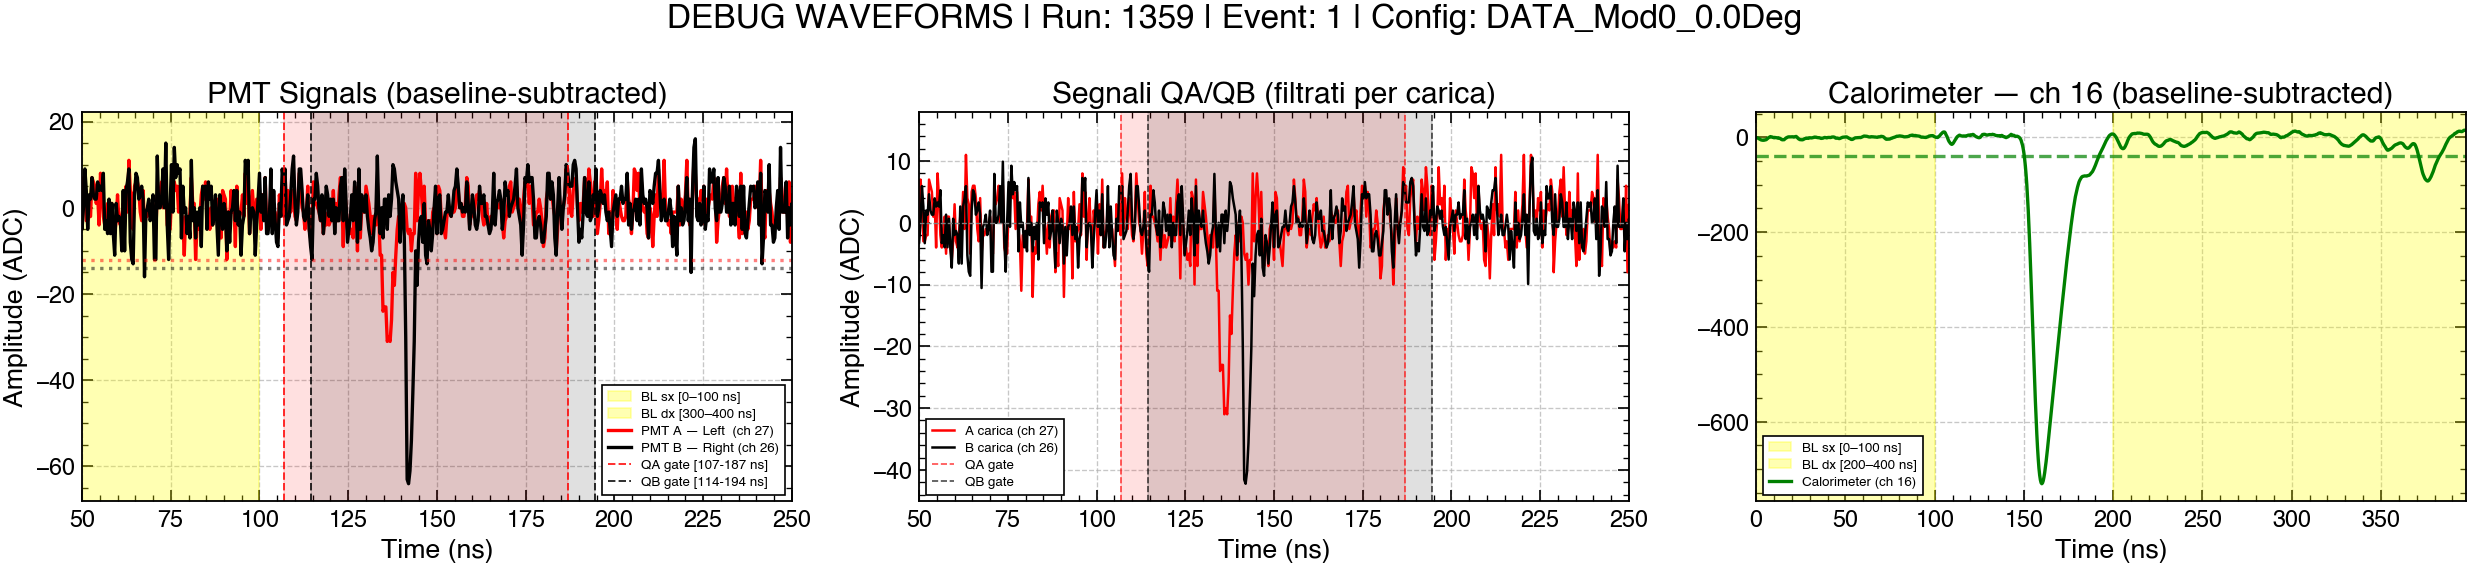

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


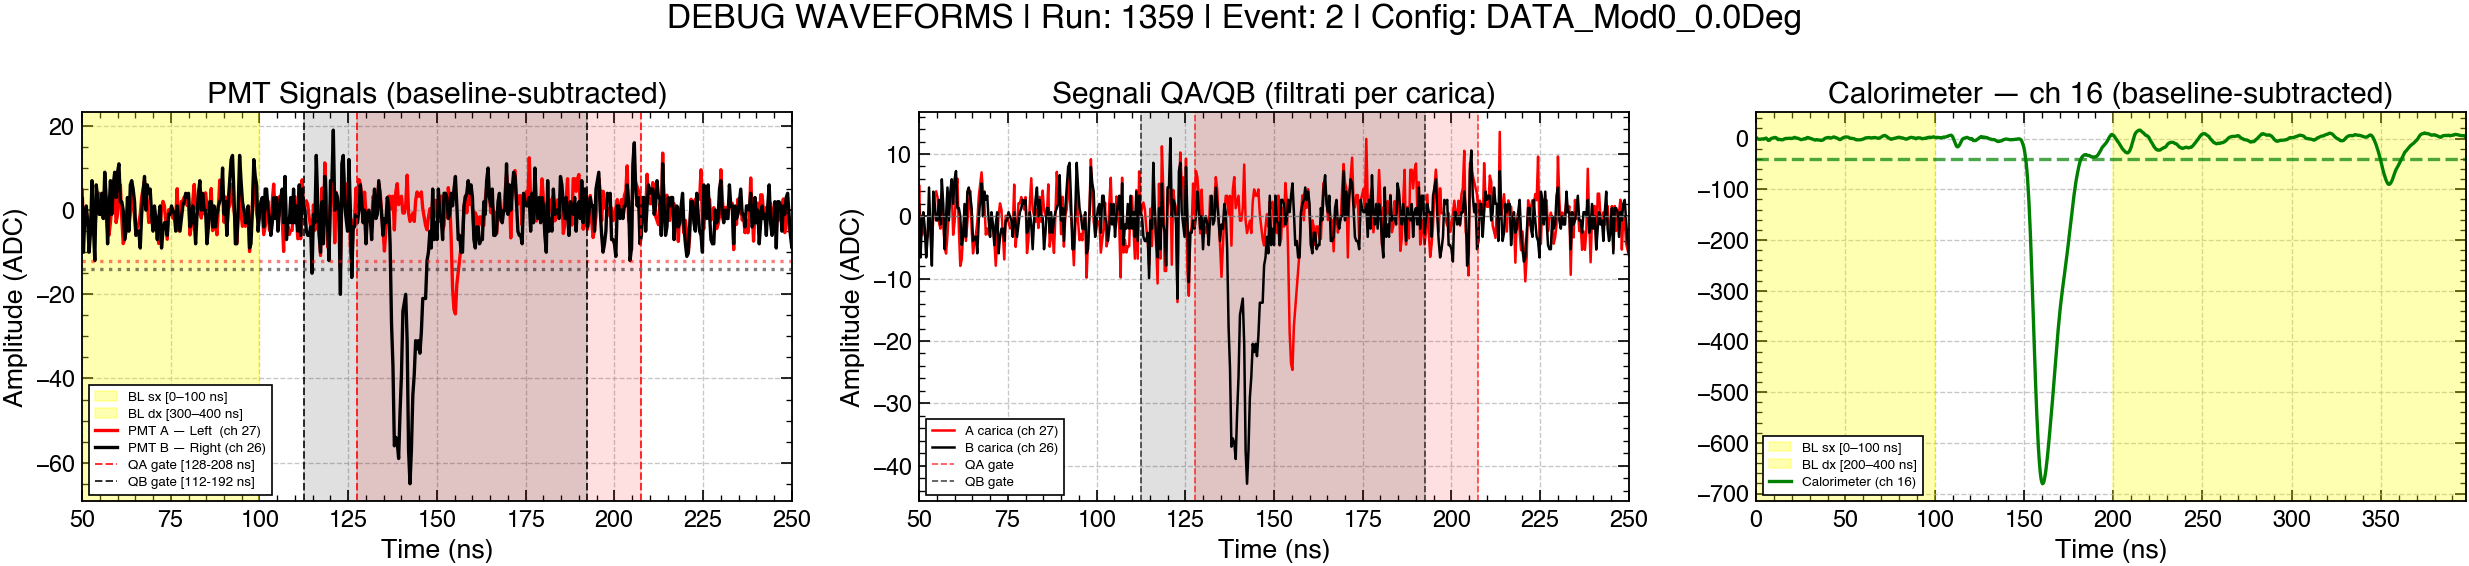

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


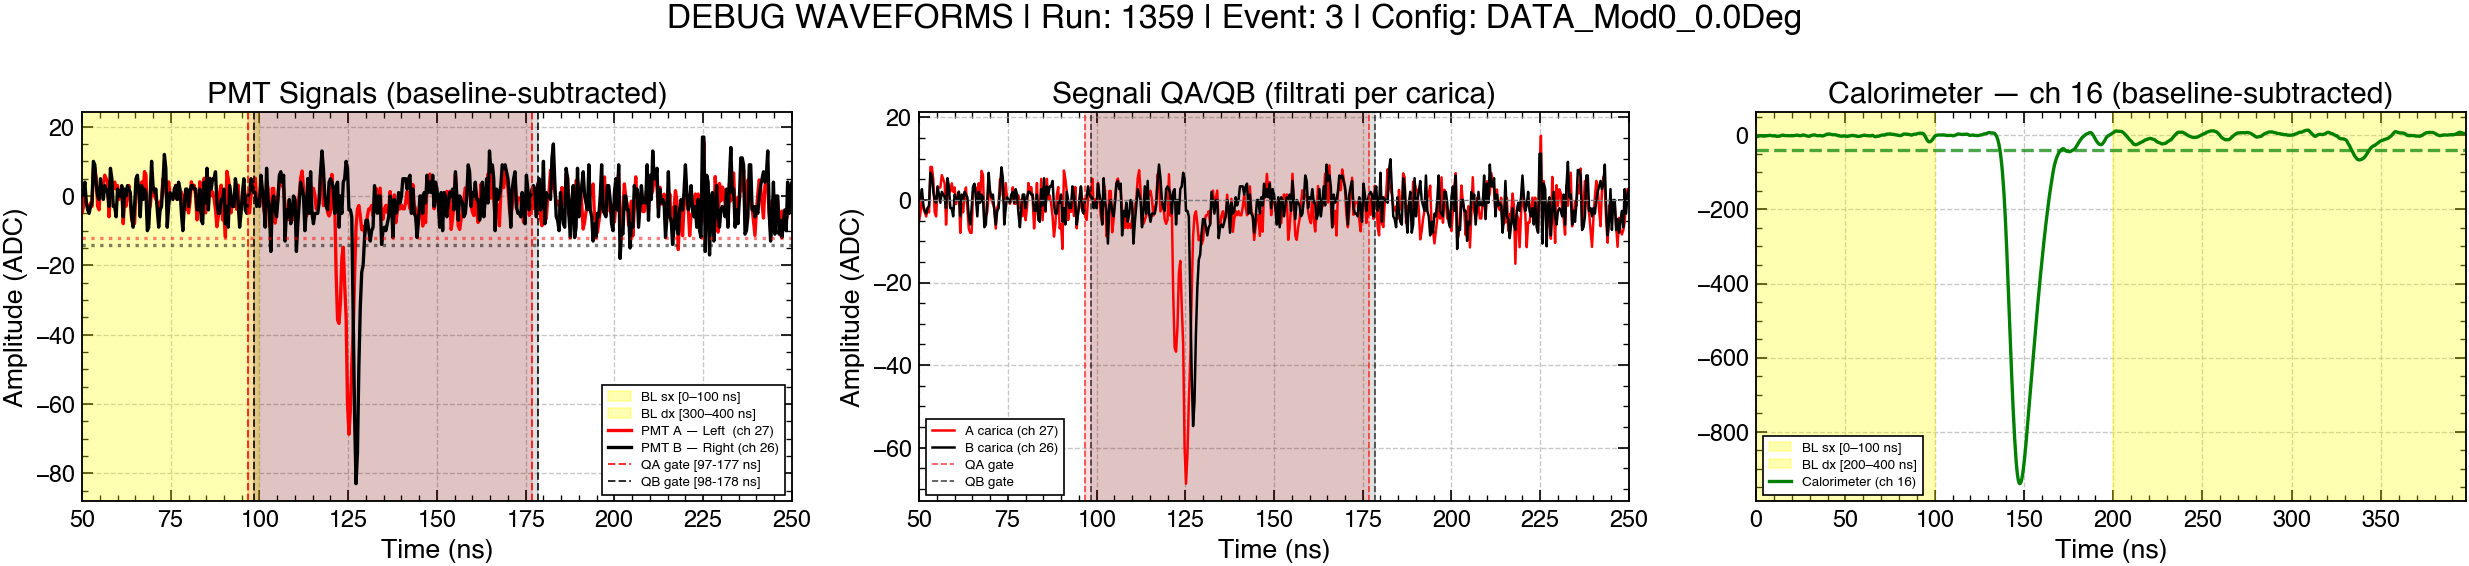

      [DONE] run 1359 | DATA_Mod0_0.0Deg | gen=3000 | trig_ok=3000 | calo_ok=702 | A=650 | B=633 | A|B=692 | A&B=591 | elapsed=15s
      [CHK-CARICA filtTIM_SAV=False filtQ_SAV=False] Sqa_calo=275203.93(n=701) Sqb_calo=186508.67(n=701) Sqa_run=249679.36(n=536) Sqb_run=183241.28(n=536)
      gen=3000 trig_ok=3000 calo_ok=702 A=650 B=633 A&B=591 fit=OK
      [EFF] X=42 cm | tot=98.6% A=92.6% B=90.2% | n_any=692 denom=702
   -> Processing run 1360 (X=36, ang=0.0deg)
/run01360.mid.gz
    Run 1360: SF=2500 MHz -> dt_ns=0.4000 | PostTrigger=40.0%


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


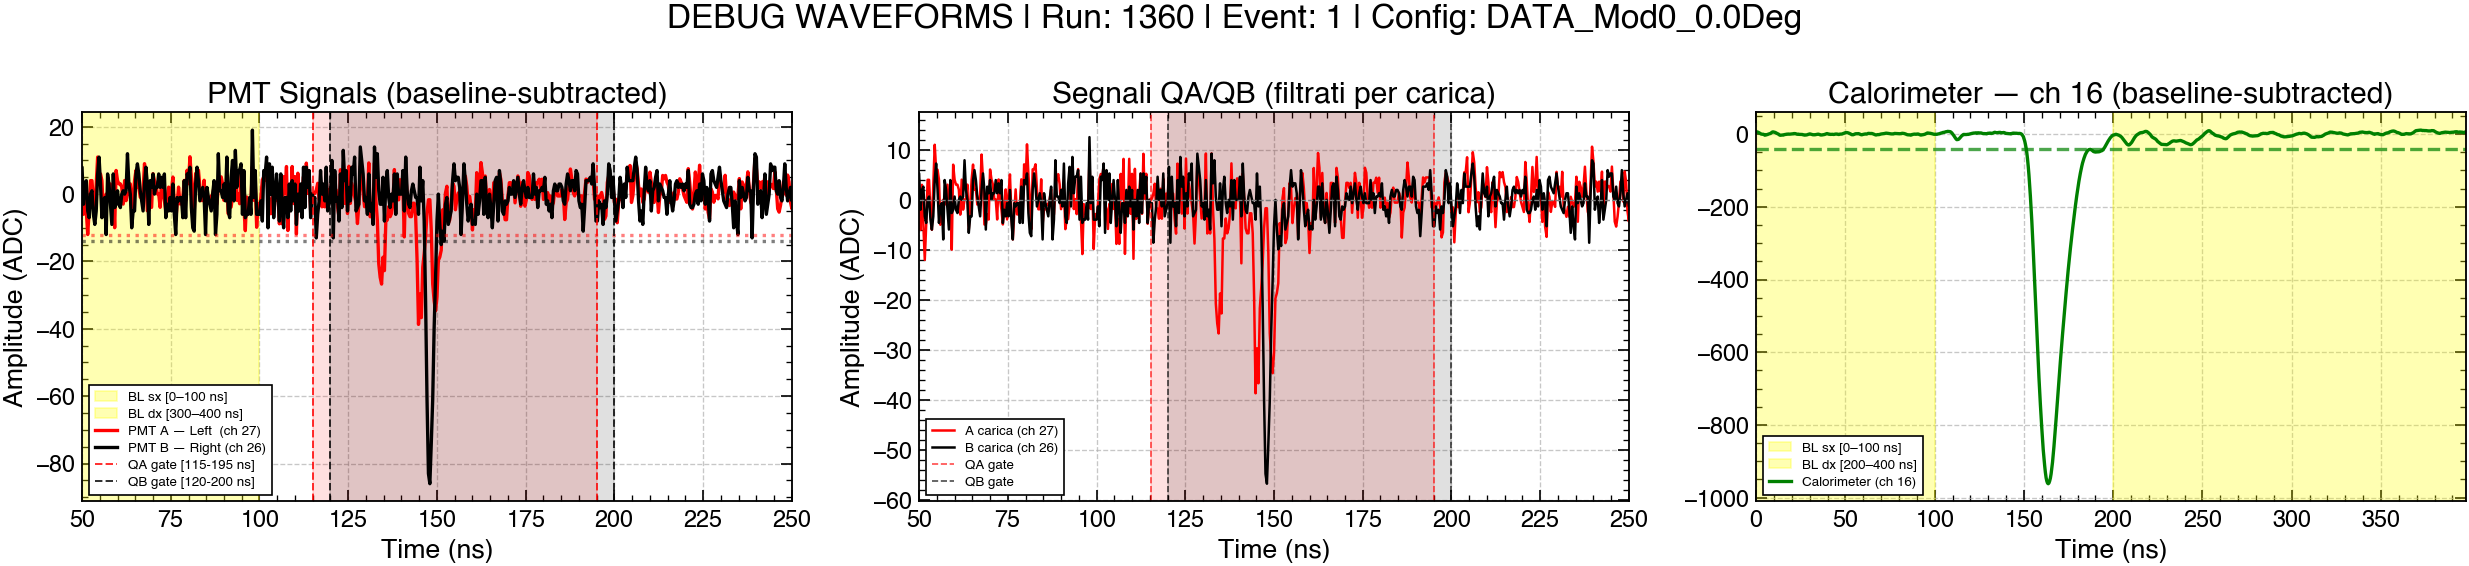

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


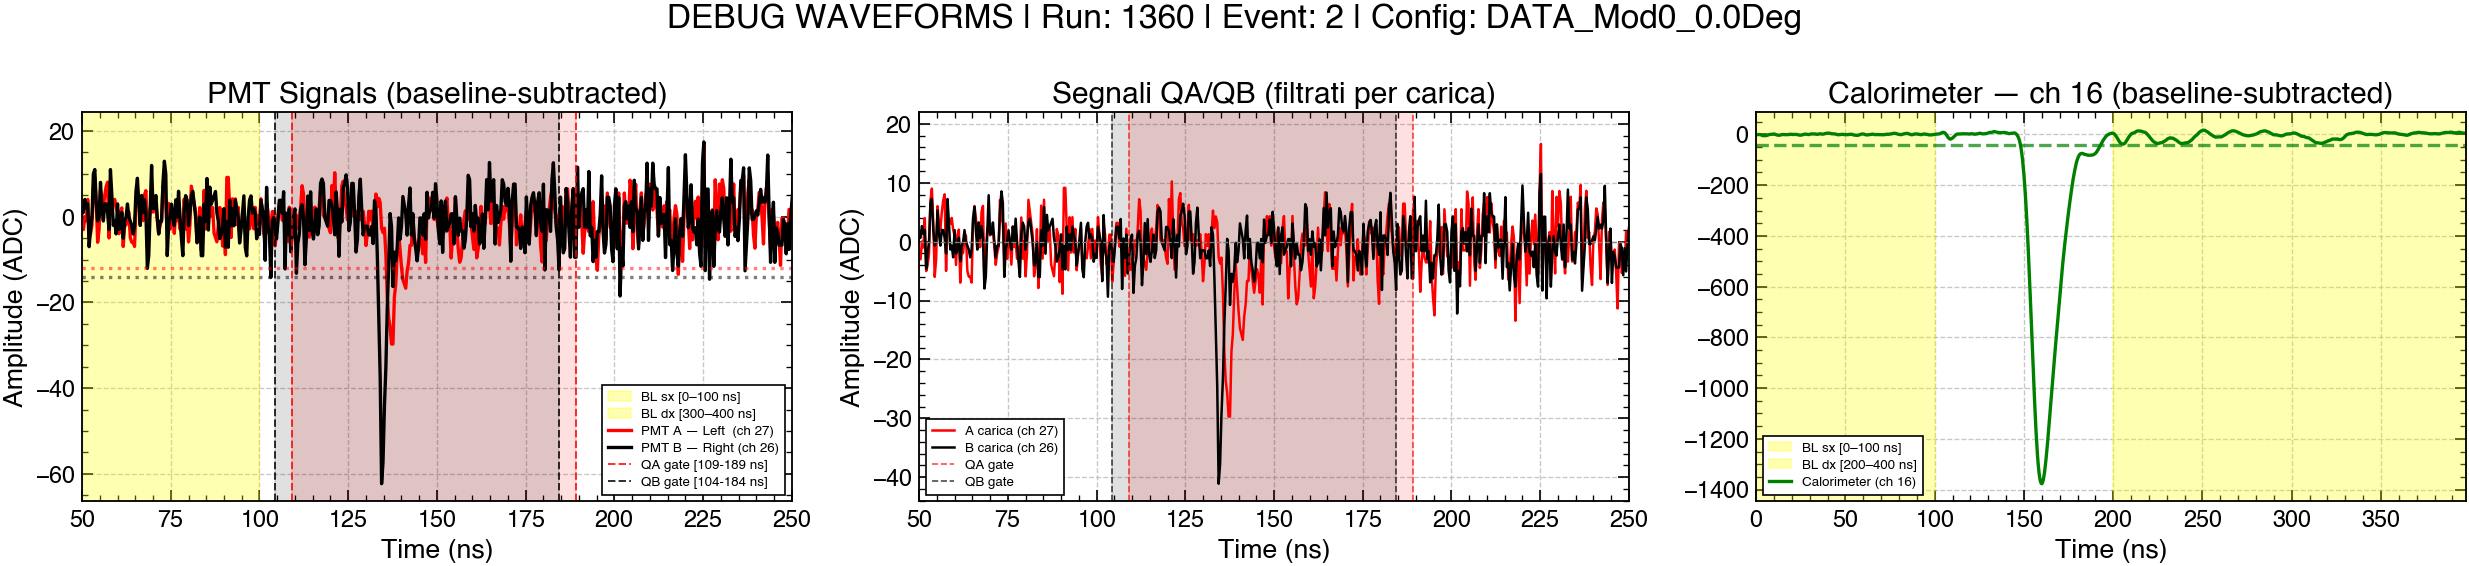

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


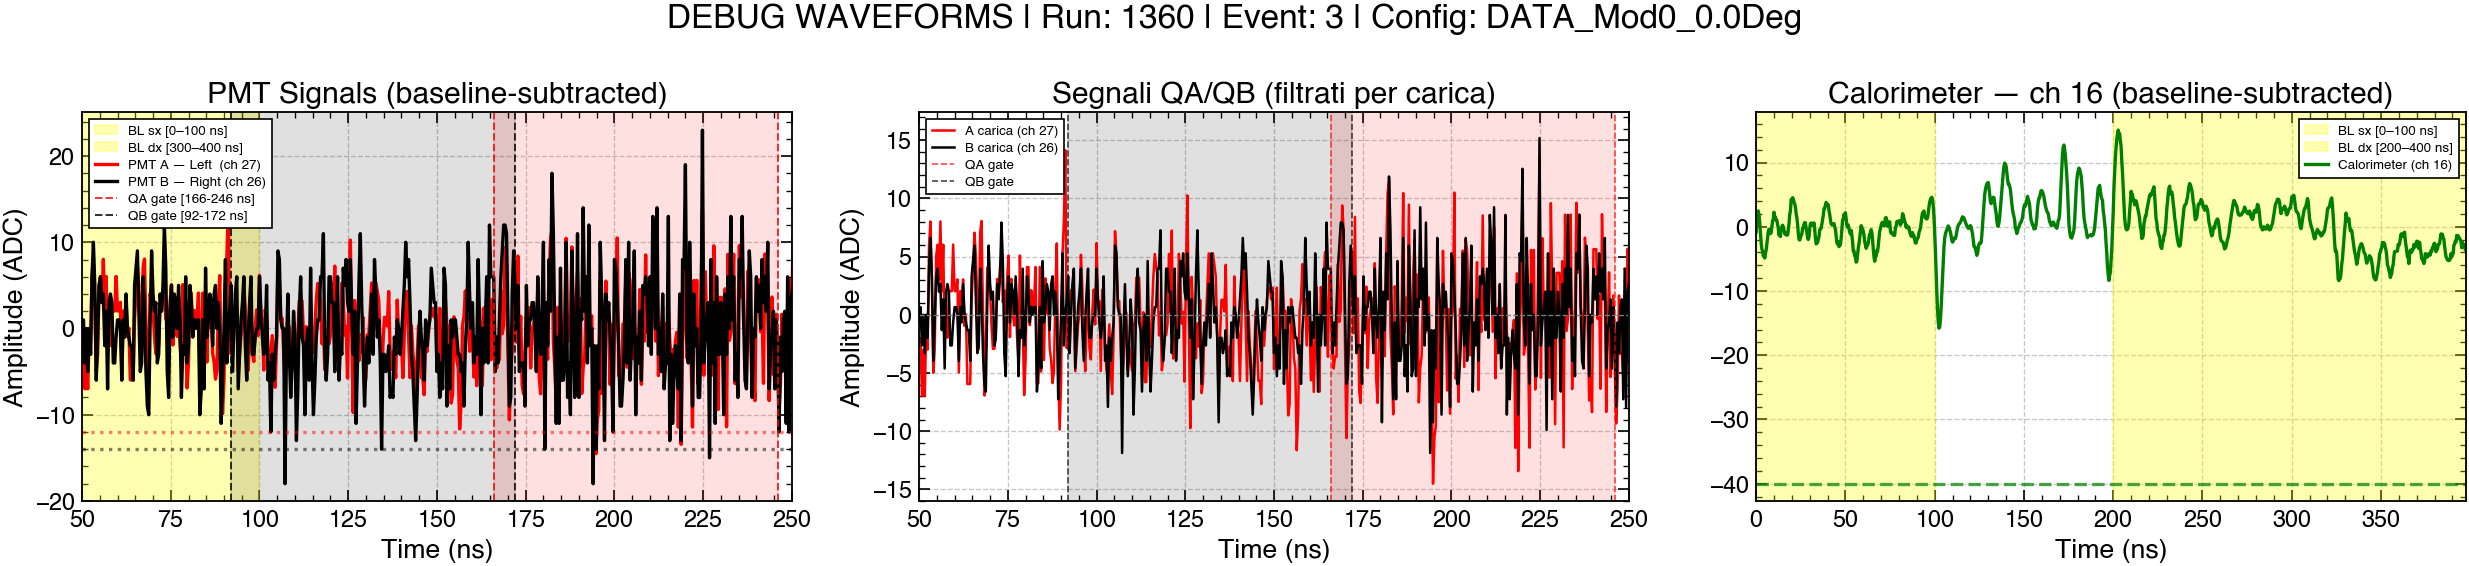

In [ ]:

# ============================================================
# GLOSSARIO PARAMETRI TUNABILI (cosa cambiare e dove)
# Tre linee INDIPENDENTI: TIMING / CARICA-Q / PED. Nessun parametro condiviso
# tra TIMING e CARICA (solo baseline+ROI sono comuni, prima dello split).
# ------------------------------------------------------------
# COMUNI/PREPROC:  PMT_BL_LEFT/RIGHT_NS (regioni baseline, senza impulso),
#                  CM_REF_CHANNEL_A/B (modo comune; None=off),
#                  DEBUG['pmt_sig_win_ns'] (ROI: dove cercare il fronte, TIMING e Q).
# TIMING (sigA/sigB): PMT_FILTER_SAVGOL/LOWPASS, PMT_SMOOTH_WINDOW/POLYORDER,
#                  PMT_LP_ORDER/CUTOFF, GATE_LEAD_NS (lookback fronte),
#                  CFD_DELAY_NS/CFD_SEARCH_WIN_NS/CFD_FRACTION, TRIGGER_THR,
#                  SIG_THR (in get_calib). -> t_res=(tA-tB)/2, efficienza-mV.
# CARICA/Q (sigA_q/sigB_q): PMT_Q_FILTER_SAVGOL/LOWPASS, PMT_Q_SMOOTH_WINDOW/POLYORDER,
#                  PMT_Q_LP_ORDER/CUTOFF, Q_GATE_THR_A/B (soglia aggancio gate),
#                  Q_GATE_LEAD_NS, ADC_GATE_START_NS (anticipo inizio gate),
#                  PULSE_WINDOW_NS (LARGHEZZA gate). -> Q_A/Q_B, ln(QA/QB).
# PED (piedistallo carica / soglia efficienza):
#                  DEBUG['pmt_ped_win_ns'][0] -> ped gate REALE = [ped[0]+PULSE, +2*PULSE]
#                    (deve stare in baseline: ped[0]+2*PULSE < arrivo impulso ~120 ns!),
#                  Q_PED_NSIGMA (taglio Q > mu_ped + N*sigma),
#                  PMT_Q_LOCAL_PED / PMT_Q_LOCAL_PED_GAP_NS (sottrazione ped locale).
# CALO: CALO_THR, CALO_Q_MIN, CALO_Q_MAX (selezione 1 elettrone).
# REGOLA D'ORO: PULSE_WINDOW_NS ~ durata impulso (~30-40 ns); Q_GATE_THR sotto il
# rumore (~-22); ped gate interamente PRIMA dell'impulso.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import os, re, glob, time
import pandas as pd
from collections import defaultdict
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter, butter, filtfilt, firwin
import warnings

warnings.filterwarnings('ignore', message='.*Polyfit may be poorly conditioned.*')

HAS_WCLIB = True
try:
    import wclib as wc
except ImportError:
    print('WARNING: wclib not found. Analysis will work in MC-ONLY mode.')
    HAS_WCLIB = False
# ============================================================
# === MENU PRINCIPALE ========================================
# ============================================================
ANALYSIS_MODE = 'DATA'          # 'DATA' | 'MC' | 'BOTH'
MC_GEO_SEL    = 'single'        # 'single' | 'triple' | None (entrambi)
MC_SRC_SEL    = 'e_tb'          # 'e_tb' | 'mu_tb' | 'mu_lngs' | 'gamma' | None (tutti)

MODULE_SEL    = 0            # None=tutti, oppure [1] o [1,4]
DEG_SEL       = 0              # None=tutti, oppure 0 o [0,2]
# Y_RANGE       = None            # None=tutto, oppure (Y_min, Y_max) in cm
# X_RANGE       = (-39.0,39.9)            # None=tutto, oppure (X_min, X_max) in cm
# Y_SEL         = 0            # None=tutte | singola pos. Y (cm) | lista [..] di Y esatte (toll. 0.05 cm)
# X_SEL         = None            # None=tutte | singola pos. X (cm) | lista [..] di X esatte (toll. 0.05 cm)
# Y_RANGE       = (-20,20)            # None=tutto, oppure (Y_min, Y_max) in cm
# X_RANGE       = None            # None=tutto, oppure (X_min, X_max) in cm
# Y_SEL         = None            # None=tutte | singola pos. Y (cm) | lista [..] di Y esatte (toll. 0.05 cm)
# X_SEL         = 0            # None=tutte | singola pos. X (cm) | lista [..] di X esatte (toll. 0.05 cm)
Y_RANGE       = None            # None=tutto, oppure (Y_min, Y_max) in cm
X_RANGE       = None           # None=tutto, oppure (X_min, X_max) in cm
Y_SEL         = None            # None=tutte | singola pos. Y (cm) | lista [..] di Y esatte (toll. 0.05 cm)
X_SEL         = None            # None=tutte | singola pos. X (cm) | lista [..] di X esatte (toll. 0.05 cm)
RUN_SEL       = None            # None=tutti | 1339=singolo | (1339,1350)=range | (1339,None)=da 1339 in poi
# RUN_SEL       = (1479, 1486)          #Range per lo studio lunghezza di traccia 
DESCRIPTION_SEL = 'test modulo 0'         # None=tutti | 'test modulo'=solo run con quella stringa in description (case-insensitive)

# --- Progress print ----------------------------------------------------
SHOW_PROGRESS        = False
PROGRESS_EVERY       = 1000
SHOW_PROGRESS_ETA    = True

# --- Interpolazione baseline (due regioni laterali) --------------
PMT_BL_LEFT_NS   = (  0.0, 100.0)  # regione sinistra baseline PMT  [ns, ns]
PMT_BL_RIGHT_NS  = (300.0, 400.0)  # regione destra  baseline PMT  [ns, ns]
CALO_BL_LEFT_NS  = (  0.0, 100.0)  # regione sinistra baseline Calo [ns, ns]
CALO_BL_RIGHT_NS = (200.0, 400.0)  # regione destra  baseline Calo [ns, ns]


# --- Finestra baseline trigger (gap tra segnale e fine regione di baseline) ----
CALO_BASELINE_GAP_NS  = 180.0   # ns

# === ETICHETTE MODULI ===
MODULE_LABELS = {0: 'Single', 1: 'Triple_Top', 2: 'Triple_Mid', 3: 'Triple_Bot'}

# === STILI MODULI ===
MODULE_STYLES = {
    0: {'color': 'purple', 'marker': 'D'},
    1: {'color': 'red',    'marker': '^'},
    2: {'color': 'green',  'marker': 's'},
    3: {'color': 'blue',   'marker': 'o'},
}

# === MAPPATURA CANALI MC ===
# Convenzione: ch_A = sx (sinistra), ch_B = dx (destra)
# Triple: mod1=Top → NPZ ch(4,5) | mod2=Mid → ch(2,3) | mod3=Bot → ch(0,1)
# Single: mod0     → NPZ ch(0,1)
MODULE_TO_CHANNELS_MC = {0:(1,0), 1:(5,4), 2:(3,2), 3:(1,0)}

# === DEBUG ===
DEBUG = {
    'plot_all_raw_wf':  False,
    'plot_waveforms':   True,
    'plot_npz_signals': False,
    'plot_charge_dist': False,
    'plot_time_dist':   False,
    'plot_nocalo_overlay': False,   # overlay WF di A e B per eventi SENZA segnale calo (min(calo) > CALO_THR)
    'plot_nocalo_event':   False,   # WF A e B EVENTO-PER-EVENTO per eventi SENZA segnale calo (min(calo) > CALO_THR)
    'nocalo_event_max':    10,     # max numero di figure per-evento no-calo (per non stamparne una per ogni evento)
    'plot_nocalo_q_event': False,   # WF carica A e B + gate fisso EVENTO-PER-EVENTO per eventi SENZA segnale calo
    'nocalo_q_max':        10,     # max numero di figure per-evento no-calo carica
    'plot_nocalo_q_dist': False,   # istogramma Q gate fisso: no-calo (grigio) vs calo-validi sovrapposti
    'plot_qab_event':  False,   # WF di A e B (filtrate per carica) EVENTO-PER-EVENTO per eventi selezionati (QA/QB calcolate)
    'qab_event_max':   10,     # max numero di figure per-evento QA/QB
    # 'plot_lowq_event': False,   # WF (filtrate per carica) dei canali con Q<soglia, con il loro gate
    # 'lowq_event_max':  10,     # max numero di figure per-evento low-Q
    # 'lowq_thr':        300,    # soglia su QA/QB sotto cui mostrare la WF del canale
    'plot_lowq_fix_event': False, # WF canali con Q gate fisso < soglia (sia DATA che MC)
    'lowq_fix_max':    10,     # max figure per-evento low-Q gate fisso
    'lowq_fix_thr':    100,    # soglia ADC (gate fisso) sotto cui mostrare la WF

    # limita SOLO il numero di eventi di debug nei plot waveform; non tronca il processing
    'max_events':       3,

    'npz_n_files':      3,
    'npz_n_events':     1,

    # --- Finestre di integrazione per gli istogrammi di carica ---
    # (start_ns, end_ns): ASSOLUTE dall'inizio della traccia (come asse X WF plot)
    'pmt_sig_win_ns':   (100.0, 220.0),  # finestra segnale PMT  ← tunare guardando WF
    'pmt_ped_win_ns':   (250.0, 260.0),  # finestra pedestal PMT — regione post-segnale (ped reale = [250,270] ns)
    'calo_sig_win_ns':  (120.0, 250.0),  # finestra segnale calo ← tunare guardando WF
    'calo_ped_win_ns':  ( 20.0,  80.0),  # finestra pedestal calo (stessa ampiezza)

    # --- Range asse X (ns) per i plot waveform PMT/QA-QB/Calorimeter ---
    'wf_xlim_pmt_ns':  (50.0, 250.0),   # pannelli 'PMT Signals' e 'Segnali QA/QB'
    'wf_xlim_calo_ns': None,            # pannello 'Calorimeter'; None = intera traccia disponibile
}
# ============================================================
# === PARAMETRI TEMPORALI IN NS ==============================
# ============================================================
# --- COMUNI / PREPROCESSING (prima dello split timing/carica) ---
BASELINE_WINDOW_NS  = 30.0    # finestra baseline trigger/calo
CM_REF_CHANNEL_A    = 19      # canale V1742 ref modo comune PMT A (su WF raw); None = off
CM_REF_CHANNEL_B    = 19      # canale V1742 ref modo comune PMT B; None = off

# --- LINEA TIMING (segnale sigA/sigB; soglia SIG_THR in get_calib) ---
PMT_FILTER_SAVGOL    = False   # SavGol sulle WF di timing
PMT_FILTER_LOWPASS   = False   # passa-basso sulle WF di timing
PMT_SMOOTH_WINDOW    = 9      # finestra SavGol timing (dispari)
PMT_SMOOTH_POLYORDER = 2      # ordine SavGol timing (< finestra)
PMT_LP_ORDER         = 3      # ordine passa-basso timing
PMT_LP_CUTOFF        = 0.2    # taglio passa-basso timing (1.0 = Nyquist)
GATE_LEAD_NS         = 60.0  # lookback dal picco per aggancio fronte (timing)
CFD_DELAY_NS         = 4.0    # ritardo CFD ~ rise time
CFD_SEARCH_WIN_NS    = 10.0    # finestra ricerca zero-crossing CFD
CFD_FRACTION         = 0.20   # frazione costante CFD
TRIGGER_THR          = -1500  # soglia trigger (fronte di discesa)

# --- LINEA CARICA / Q (segnale sigA_q/sigB_q; tutto indipendente dal timing) ---
PMT_Q_FILTER_SAVGOL    = False   # SavGol sulle WF di carica
PMT_Q_SMOOTH_WINDOW    = 31      # finestra SavGol carica (dispari)
PMT_Q_SMOOTH_POLYORDER = 3      # ordine SavGol carica
PMT_Q_FILTER_LOWPASS   = False  # passa-basso sulle WF di carica
PMT_Q_LP_ORDER         = 15      # ordine passa-basso carica
PMT_Q_LP_CUTOFF        = 0.2    # taglio passa-basso carica
Q_GATE_THR_A           = -2  # soglia aggancio gate carica A (piu' profonda del rumore)
Q_GATE_THR_B           = -2  # soglia aggancio gate carica B
Q_EQ_FACTOR_A          = 1.0   # equalizzazione guadagno PMT A: QA -> QA*fattore (1.0 = off)
Q_EQ_FACTOR_B          = 0.66  # equalizz. guadagno PMT B (QB->QB*fattore). Da fit ln(QA/QB)|X=0~-0.41 -> exp=0.66; rifinisci col valore stampato [EQ]
Q_EQ_AUTO              = False # True: nel plot ln(QA/QB) sottrae l'intercetta (crossing forzato a 0). False: mostra il residuo vero
Q_GATE_LEAD_NS         = 20    # lookback dal picco per aggancio gate carica
ADC_GATE_START_NS      = 10.0   # anticipo inizio gate carica rispetto al fronte
PULSE_WINDOW_NS        = 80.0  # larghezza gate di integrazione carica
PED_WINDOW_NS          = 10.0   # larghezza finestra del PIEDISTALLO (indip. da PULSE_WINDOW_NS).
#                                Per una soglia mu+Nsigma valida tienila = PULSE_WINDOW_NS.
PMT_Q_LOCAL_PED        = False   # sottrai ped locale (finestra uguale prima del gate)
PMT_Q_LOCAL_PED_GAP_NS = 10.0    # gap (ns) tra ped locale e gate
PMT_Q_CM_AB            = False     # sottrai modo comune (A+B)/2 dalla WF di carica (solo DATA; MC escluso)
PMT_Q_CM_SIG_WIN_NS    = (90, 220)  # finestra segnale esclusa dalla stima CM [start,end] ns; None=usa DEBUG['pmt_sig_win_ns']
PMT_Q_FILTER_HIGHPASS  = False  # passa-alto WF carica: elimina deriva lenta di baseline
PMT_Q_HP_ORDER         = 2      # ordine Butterworth passa-alto carica
PMT_Q_HP_PERIOD_NS     = 100.0  # taglio HP: attenua periodi > questo valore (ns); f_cut = 1/period
PMT_Q_HP_TYPE          = 'FIR'  # 'IIR' = Butterworth filtfilt | 'FIR' = firwin Hamming (fase lineare, no ringing)
PMT_Q_HP_NUMTAPS       = 401    # numero tap FIR passa-alto (dispari; piu' grande = taglio piu' netto)
Q_PED_NSIGMA           = 3.0    # taglio efficienza carica: Q > media_ped + N*sigma
# --- METODO 2 efficienza carica: GATE FISSO (definito dall'utente, SENZA soglia di aggancio) ---
# Ogni evento calo-valido e' integrato in una finestra fissa; se non c'e' segnale la Q cade nel ped.
# Efficienza = N(Q > mu+Nsigma) / N(calo-validi)  [denominatore = TUTTI gli eventi -> istogramma completo]
GATE_MIN_A_NS = 110.0   # inizio finestra integrazione carica A (ns assoluti)
GATE_MAX_A_NS = 150.0   # fine finestra A
GATE_MIN_B_NS = 110.0   # inizio finestra B
GATE_MAX_B_NS = 160.0   # fine finestra B
GATE_PED_START_NS = 250.0  # inizio finestra ped (baseline, ns assoluti)
GATE_PED_END_NS   = 260.0 # fine finestra ped (ns). NB: larghezza ped = larghezza gate segnale (70 ns = 175 campioni)
# --- GATE FISSO MC (None = usa gli stessi parametri DATA sopra) ---
MC_GATE_MIN_A_NS    = 155  # inizio finestra integrazione carica A per MC
MC_GATE_MAX_A_NS    = 190  # fine finestra A per MC
MC_GATE_MIN_B_NS    = 155  # inizio finestra B per MC
MC_GATE_MAX_B_NS    = 190  # fine finestra B per MC
MC_GATE_PED_START_NS = 250 # inizio finestra piedistallo per MC
MC_GATE_PED_END_NS   = 260 # fine finestra piedistallo per MC
GATE_NOCALO_CM_CORR  = False  # True: sottrai la media del gate no-calo (offset CM sistematico) da tutti gli eventi;
#                             usa la distribuzione no-calo come pedestal per la soglia gate fisso

# --- CALORIMETRO ---
CALO_THR    = -40       # soglia ampiezza calo
CALO_Q_MIN  = -35500    # carica calo minima (ADC*samples)
CALO_Q_MAX  = -10500    # carica calo massima (ADC*samples)

# --- SOGLIE SEGNALE PMT (efficienza-mV, leading edge; usate da get_calib) ---
SIG_THR_A_DATA = -12    # ADC, dati reali PMT A
SIG_THR_B_DATA = -14    # ADC, dati reali PMT B
SIG_THR_MC     = -11    # ADC, MC (A=B)

# --- GEOMETRIA TRACK LENGTH (DATI = modulo inclinato attorno a Y; vedi L_moduletilt) ---
X_ORIGIN_OFFSET_MM = 0.0   # offset origine prototipo (mm): atteso ~1-2 cm (precisione meccanica);
#                            NON stimabile dai <Q> di bordo (avvelenati dal pettine fibre).
X_POS_ERR_CM       = 0.2   # incertezza pos. centro rivelatore vs origine (cm) -> barra orizzontale L
# ============================================================
# === PATH E PARAMETRI FISSI =================================
# ============================================================
verbose     = False
path        = '/Users/benussi/nmv-data/WC/WC26'                              # <- JupyterHub remoto
output_dir  = '/Users/benussi/Analysis/WC/TestBeam-2026/plots'           # <- JupyterHub remot
# path        = '/Users/benussi/Testbeam2026_WC_unified/Data_TB'            # <- locale
# output_dir  = '/Users/benussi/Testbeam2026_WC_unified/Analysis_script/output'  # <- locale
debug_dir   = os.path.join(output_dir, 'debug')
#MC_DIR       = '/home/benussi/Analysis/WC/TestBeam-2026/MC_Signal'  # <- JupyterHub remoto
MC_DIR       = '/Users/benussi/Testbeam2026_WC_unified/data'           # <- locale
MC_SINGLE_MOD_ID = 0      # mod_id assegnato ai file single (deve coincidere con logbook)
TRIPLE_MODULE_Y_CENTERS = {1: 30.65, 2: 0.0, 3: -30.65}  # cm — centri reali ±306.5 mm
logbook_url = 'https://docs.google.com/spreadsheets/d/1EdfueihmdlrPdRGPzOTxER3pWm2c2IO1ddQZU5P7608/export?format=csv'

os.makedirs(output_dir, exist_ok=True)
if any(DEBUG[k] for k in ('plot_all_raw_wf','plot_waveforms','plot_npz_signals',
                          'plot_charge_dist','plot_time_dist','plot_nocalo_q_dist')):
    os.makedirs(debug_dir, exist_ok=True)

DT_NS_MC_DEFAULT        = 0.4
DEFAULT_POSTTRIGGER_PCT = 70.0
MC_TRIG_REF_NS          = 150.0

BASE_FONT_SIZE = 16
plt.rcParams.update({
    'font.size': BASE_FONT_SIZE, 'axes.titlesize': BASE_FONT_SIZE+2,
    'axes.labelsize': BASE_FONT_SIZE, 'xtick.labelsize': BASE_FONT_SIZE-2,
    'ytick.labelsize': BASE_FONT_SIZE-2, 'legend.fontsize': BASE_FONT_SIZE-2,
    'figure.titlesize': BASE_FONT_SIZE+4
})


# --- Merge run con configurazione identica (media delle efficienze) ---
MERGE_SAME_CONFIG_RUNS = True   # True: run con stessa (mod,X,Y,angolo) -> 1 punto, efficienze MEDIATE

def _collapse_same_config(df):
    """Collassa i run con configurazione identica (mod_id, x, y, angle) in una
    riga sola, MEDIANDO le efficienze determinate per ciascun run. Le efficienze
    sono ricostruite come (numeratore/denominatore) col denominatore = somma dei
    run, cosi' ogni plot a valle (che ricalcola num/den) usa automaticamente la
    MEDIA SEMPLICE delle efficienze per-run. Variabili fisiche (timing, log-ratio)
    = media, errore = SEM tra i run. I punti con un solo run restano INVARIATI."""
    if df is None or len(df) == 0:
        return df
    NUM   = ['n_any','n_A','n_B','n_A_q','n_B_q','n_AB_q','n_A_qfix','n_B_qfix','n_AB_qfix']
    MEANV = ['mu_res','mu_len','sig_res','sig_len','log_q_ratio','log_q_ratio_fix',
             'eff_tot','eff_A','eff_B']
    df = df.copy()
    df['_gk'] = (df['mod_id'].astype(str) + '|' + df['x'].round(3).astype(str) + '|'
                 + df['y'].round(3).astype(str) + '|' + df['angle'].round(3).astype(str))
    out = []
    for _, sub in df.groupby('_gk', sort=False):
        row = sub.iloc[0].to_dict()
        n = len(sub)
        if n > 1:
            den  = sub['n_denom'].astype(float)
            Dnew = float(den.sum())
            row['n_denom'] = Dnew
            for c in NUM:
                if c in sub.columns:
                    row[c] = float((sub[c].astype(float) / den).mean()) * Dnew  # eff media x denom
            for c in MEANV:
                if c in sub.columns:
                    row[c] = float(sub[c].astype(float).mean())
            def _sem(col, errcol):
                v = sub[col].astype(float).values
                s = float(np.std(v, ddof=1)) / np.sqrt(n) if n > 1 else np.nan
                if not np.isfinite(s) or s == 0:
                    s = float(sub[errcol].astype(float).mean()) if errcol in sub.columns else 0.0
                return s
            for col, ec in [('mu_res','err_mu_res'), ('log_q_ratio','err_log_q'),
                            ('eff_tot','err_eff_tot'), ('eff_A','err_eff_A'), ('eff_B','err_eff_B')]:
                if ec in sub.columns: row[ec] = _sem(col, ec)
            row['notes'] = 'merge'
            row['run']   = sub['run'].iloc[0]
        out.append(row)
    res = pd.DataFrame(out)
    if '_gk' in res.columns:
        res = res.drop(columns=['_gk'])
    return res.sort_values('x').reset_index(drop=True)


# integrale trapezoidale compatibile con numpy<2 (trapz) e numpy>=2 (trapezoid)
np_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
def apply_pmt_filter(wf):
    """Applica alle WF (gia' baseline-sub) i filtri configurati.
    Ordine quando entrambi attivi: passa-basso Butterworth -> Savitzky-Golay.
    Con entrambi disattivati restituisce la WF invariata (raw)."""
    out = wf
    if PMT_FILTER_LOWPASS:
        _b, _a = butter(PMT_LP_ORDER, PMT_LP_CUTOFF, btype='low')
        out = filtfilt(_b, _a, out)
    if PMT_FILTER_SAVGOL:
        out = savgol_filter(out, window_length=PMT_SMOOTH_WINDOW, polyorder=PMT_SMOOTH_POLYORDER)
    return out

def apply_charge_filter(wf, dt_ns=DT_NS_MC_DEFAULT, is_mc=False):
    """Filtri applicati SOLO per il calcolo della carica (QA/QB), non per il timing.
    Usa parametri PMT_Q_* COMPLETAMENTE separati da quelli del timing (nessun accoppiamento).
    Ordine: HP (rimuove deriva lenta) → LP (liscia rumore HF) → SavGol.
    Per il MC i segnali sono gia' puliti: nessun filtro applicato."""
    if is_mc:
        return wf
    out = wf
    if PMT_Q_FILTER_HIGHPASS and PMT_Q_HP_PERIOD_NS > 0:
        _wn_hp = min(0.99, 2.0 * dt_ns / PMT_Q_HP_PERIOD_NS)
        if _wn_hp > 1e-4:
            if PMT_Q_HP_TYPE == 'FIR':
                _ntaps = PMT_Q_HP_NUMTAPS if PMT_Q_HP_NUMTAPS % 2 == 1 else PMT_Q_HP_NUMTAPS + 1
                _b = firwin(_ntaps, _wn_hp, pass_zero=False, window='hamming')
                out = filtfilt(_b, [1.0], out)
            else:
                _b, _a = butter(PMT_Q_HP_ORDER, _wn_hp, btype='high')
                out = filtfilt(_b, _a, out)
    if PMT_Q_FILTER_LOWPASS:
        _b, _a = butter(PMT_Q_LP_ORDER, PMT_Q_LP_CUTOFF, btype='low')
        out = filtfilt(_b, _a, out)
    if PMT_Q_FILTER_SAVGOL:
        out = savgol_filter(out, window_length=PMT_Q_SMOOTH_WINDOW, polyorder=PMT_Q_SMOOTH_POLYORDER)
    return out

def gate_charge(sigq, t_in, window, dt_ns):
    """Carica = integrale nel gate [t_in, t_in+window]. Se PMT_Q_LOCAL_PED, sottrae il
    piedistallo LOCALE: integrale su una finestra uguale subito prima del gate (separata
    da PMT_Q_LOCAL_PED_GAP_NS). Se non c'e' spazio prima, ritorna solo l'integrale del gate."""
    t_in = int(t_in)
    q = float(-np_trapz(sigq[t_in:t_in + window]))   # integrale (regola del trapezio)
    if PMT_Q_LOCAL_PED:
        _gap = ns_to_samples(PMT_Q_LOCAL_PED_GAP_NS, dt_ns, min_val=0)
        _lp1 = t_in - _gap
        _lp0 = _lp1 - window
        if _lp0 >= 0:
            q -= float(-np_trapz(sigq[_lp0:_lp1]))   # ped locale (trapezio)
    return q
# ============================================================
# CALIBRAZIONI DINAMICHE
# ============================================================
def get_calib(is_mc):
    if not is_mc:
        return SIG_THR_A_DATA, SIG_THR_B_DATA, 0, 0, 0, 0
    else:
        return SIG_THR_MC, SIG_THR_MC, 0.0, 0.0, 0.0, 0.0
# ============================================================
# FUNZIONI DI TIMING E PULSE
# ============================================================
def crossing_time(wf, thr, direction="falling"):
    wf = np.asarray(wf)
    cond = (wf[:-1] > thr) & (wf[1:] <= thr) if direction == "falling" \
           else (wf[:-1] < thr) & (wf[1:] >= thr)
    idx = np.where(cond)[0]
    if len(idx) == 0:
        return None
    i = idx[0]
    y1, y2 = wf[i], wf[i+1]
    return float(i + (thr - y1) / (y2 - y1))

def leading_edge_crossing(wf, thr, lead_samples=None):
    """Inizio del cluster dell'impulso piu' grande nel segmento.
    Trova il minimo globale (vero picco); poi, tra gli attraversamenti soglia (sopra->sotto)
    a indice <= i_min, prende il PRIMO entro 'lead_samples' campioni prima del picco
    (cosi' cattura il primo lobo anche in impulsi strutturati). Se lead_samples e' None
    usa l'ultimo crossing prima del minimo. Robusto al rumore pre-impulso.
    Ritorna None se il minimo non supera la soglia o non c'e' crossing."""
    wf = np.asarray(wf)
    if len(wf) == 0:
        return None
    i_min = int(np.argmin(wf))
    if wf[i_min] > thr:
        return None
    cond = (wf[:-1] > thr) & (wf[1:] <= thr)
    idx = np.where(cond)[0]
    idx = idx[idx <= i_min]
    if lead_samples is not None:
        idx = idx[idx >= i_min - int(lead_samples)]
    if len(idx) == 0:
        return None
    i = int(idx[0]) if lead_samples is not None else int(idx[-1])
    y1, y2 = wf[i], wf[i+1]
    return float(i + (thr - y1) / (y2 - y1))

def cfd_time(signal, fraction, delay, t_start, search_win):
    if t_start is None:
        return None
    signal = np.asarray(signal)
    cfd = signal[:-delay] - fraction * signal[delay:]
    start = max(1, int(t_start - search_win))
    stop  = min(len(cfd) - 1, int(t_start + search_win))
    for i in range(start, stop):
        if cfd[i-1] < 0 and cfd[i] >= 0:
            y1, y2 = cfd[i-1], cfd[i]
            return float((i-1) + (0 - y1) / (y2 - y1))
    return None

# ============================================================
# CONVERSIONE NS -> SAMPLES
# ============================================================
def ns_to_samples(ns_value, dt_ns, min_val=1):
    return max(min_val, int(round(ns_value / dt_ns)))

def compute_run_timing_params(dt_ns, trig_sample, n_samples):
    n_bl = ns_to_samples(BASELINE_WINDOW_NS, dt_ns)
    n_calo_gap = ns_to_samples(CALO_BASELINE_GAP_NS, dt_ns, min_val=0)
    calo_bl_stop  = max(1, trig_sample - n_calo_gap)
    calo_bl_start = max(0, calo_bl_stop - n_bl)
    if calo_bl_stop - calo_bl_start < 5:
        calo_bl_start = 0
        calo_bl_stop  = max(5, min(trig_sample, n_samples // 4))
    return {
        'calo_bl_start': calo_bl_start,
        'calo_bl_stop':  calo_bl_stop,
        'cfd_delay':     ns_to_samples(CFD_DELAY_NS,      dt_ns),
        'cfd_search':    ns_to_samples(CFD_SEARCH_WIN_NS, dt_ns),
        'pulse_win':     ns_to_samples(PULSE_WINDOW_NS,   dt_ns),
    }
# ============================================================
# HELPER
# ============================================================
def save_debug_pdf(fig, filename):
    try:
        fig.savefig(os.path.join(debug_dir, filename), bbox_inches='tight')
    except Exception as e:
        print(f"    [!] Errore salvataggio {filename}: {e}")

def fmt_seconds(sec):
    sec = max(0, int(sec))
    h = sec // 3600
    m = (sec % 3600) // 60
    s = sec % 60
    if h > 0:
        return f"{h}h {m:02d}m {s:02d}s"
    if m > 0:
        return f"{m}m {s:02d}s"
    return f"{s}s"

def _has_channel(wf_raw, ch):
    """True se il canale 'ch' e' presente. Gestisce sia dict {ch: wf} sia array 2D (canali x campioni).
    NB: per array NON usare 'ch in wf_raw' (verificherebbe i valori, non l'indice del canale)."""
    if ch is None:
        return False
    if hasattr(wf_raw, 'keys'):
        return ch in wf_raw
    try:
        return 0 <= int(ch) < len(wf_raw)
    except Exception:
        return False
# ============================================================
# FUNZIONI DI DEBUG
# ============================================================
def debug_plot_all_raw_wf(wf_raw, run_id, ev_num, config_name, dt_ns, active_channels=None):
    if active_channels is None:
        active_channels = {}
    role_of_ch = {ch: role for role, ch in active_channels.items() if ch is not None}
    MAX_CH = 32; NROWS, NCOLS = 4, 8
    try:
        if hasattr(wf_raw, 'keys'):
            avail_chs = sorted([k for k in wf_raw.keys() if isinstance(k, (int, np.integer))])
            n_ch_total = (max(avail_chs) + 1) if avail_chs else 0
        else:
            n_ch_total = len(wf_raw)
    except Exception:
        n_ch_total = MAX_CH
    n_ch = min(n_ch_total, MAX_CH)
    fig, axes = plt.subplots(NROWS, NCOLS, figsize=(28, 12))
    fig.suptitle(f"RAW WF (no condition) | Run: {run_id} | Event: {ev_num} | "
                 f"Config: {config_name} | DT={dt_ns:.3f} ns/sample | {n_ch} ch", fontsize=14)
    for ch in range(MAX_CH):
        ax = axes[ch // NCOLS, ch % NCOLS]
        if ch >= n_ch:
            ax.set_title(f"ch_{ch} | (n/a)", fontsize=8)
            ax.set_facecolor('#f0f0f0'); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7); continue
        try:
            wf = np.asarray(wf_raw[ch])
        except Exception:
            ax.set_title(f"ch_{ch} | (err)", fontsize=8)
            ax.set_facecolor('#f0f0f0'); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=7); continue
        wmin, wmax = float(np.min(wf)), float(np.max(wf))
        ax.plot(np.arange(len(wf)) * dt_ns, wf, linewidth=0.8, color='steelblue')
        role = role_of_ch.get(ch)
        if role is not None:
            ax.set_title(f"ch_{ch} [{role}]\nmin={wmin:.0f} max={wmax:.0f}",
                         color='red', fontweight='bold', fontsize=8)
        else:
            ax.set_title(f"ch_{ch}\nmin={wmin:.0f} max={wmax:.0f}", fontsize=8)
        ax.tick_params(labelsize=7); ax.grid(True, alpha=0.3)
    for r in range(NROWS):
        axes[r, 0].set_ylabel("ADC", fontsize=8)
    for c in range(NCOLS):
        axes[NROWS-1, c].set_xlabel("Time (ns)", fontsize=8)
    plt.tight_layout()
    if DEBUG['plot_all_raw_wf']:
        save_debug_pdf(fig, f"raw_wf_run{run_id}_ev{ev_num:04d}.pdf")
    plt.show()
    plt.close(fig)

def debug_plot_waveforms(wf_data, run_id, ev_num, config_name, calib_tuple, dt_ns, timing, sibling_raw=None, save_pdf_name=None):
    SIG_THR_A, SIG_THR_B, *_ = calib_tuple
    sigA = wf_data['sigA']
    sigB = wf_data['sigB']
    calo = wf_data['calo']
    trig = wf_data.get('trig')

    n_panels = 4 if sibling_raw is not None else 3
    fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
    fig.suptitle(f"DEBUG WAVEFORMS | Run: {run_id} | Event: {ev_num} | Config: {config_name}")

    TRIM = 30
    sigA_p = sigA[:-TRIM]
    sigB_p = sigB[:-TRIM]
    calo_p = calo[:-TRIM]
    trig_p = trig[:-TRIM] if trig is not None else None
    n_plot  = len(sigA_p)

    t_axis = np.arange(n_plot) * dt_ns
    ch_A    = timing.get('ch_A',    '?')
    ch_B    = timing.get('ch_B',    '?')
    ch_calo = timing.get('ch_calo', '?')
    ch_trig = timing.get('ch_trig', '?')

    # --- PMT panel ---
    axes[0].axvspan(PMT_BL_LEFT_NS[0],  PMT_BL_LEFT_NS[1],  color='yellow', alpha=0.30,
                    label=f'BL sx [{PMT_BL_LEFT_NS[0]:.0f}–{PMT_BL_LEFT_NS[1]:.0f} ns]')
    axes[0].axvspan(PMT_BL_RIGHT_NS[0], PMT_BL_RIGHT_NS[1], color='yellow', alpha=0.30,
                    label=f'BL dx [{PMT_BL_RIGHT_NS[0]:.0f}–{PMT_BL_RIGHT_NS[1]:.0f} ns]')
    if DEBUG.get('plot_charge_dist'):
        _ped_g0 = DEBUG['pmt_ped_win_ns'][0] + PED_WINDOW_NS   # ped gate REALE = [ped[0]+PED, +2*PED]
        _ped_g1 = _ped_g0 + PED_WINDOW_NS
        axes[0].axvspan(_ped_g0, _ped_g1, color='deepskyblue', alpha=0.25,
                        label=f'Q ped gate [{_ped_g0:.0f}-{_ped_g1:.0f} ns]')
        axes[0].axvspan(DEBUG['pmt_sig_win_ns'][0], DEBUG['pmt_sig_win_ns'][1],
                        color='limegreen', alpha=0.25,
                        label=f'Q sig [{DEBUG["pmt_sig_win_ns"][0]:.0f}–{DEBUG["pmt_sig_win_ns"][1]:.0f} ns]')
    axes[0].plot(t_axis, sigA_p, color='red',   label=f'PMT A — Left  (ch {ch_A})',  linewidth=2)
    axes[0].plot(t_axis, sigB_p, color='black', label=f'PMT B — Right (ch {ch_B})', linewidth=2)
    axes[0].axhline(SIG_THR_A, color='red',   ls=':', alpha=0.5)
    axes[0].axhline(SIG_THR_B, color='black', ls=':', alpha=0.5)
    # --- Gate di integrazione carica QA/QB (dinamico, per canale) ---
    _roi0 = max(0, int(round(DEBUG['pmt_sig_win_ns'][0] / dt_ns)))
    _roi1 = max(0, int(round(DEBUG['pmt_sig_win_ns'][1] / dt_ns)))
    _gshift = ns_to_samples(ADC_GATE_START_NS, dt_ns, min_val=0)
    _gwin   = ns_to_samples(PULSE_WINDOW_NS, dt_ns)
    _sigAq_g = wf_data.get('sigA_q'); _sigBq_g = wf_data.get('sigB_q')   # gate = quello REALE della carica
    for _sg, _thr, _qcol, _qlbl in [(_sigAq_g, Q_GATE_THR_A, 'red', 'QA'),
                                    (_sigBq_g, Q_GATE_THR_B, 'black', 'QB')]:
        if _sg is None: continue
        _seg = _sg[_roi0:_roi1]
        _tr = leading_edge_crossing(_seg, _thr, lead_samples=ns_to_samples(Q_GATE_LEAD_NS, dt_ns, min_val=1))
        if _tr is not None:
            if True:
                _g0 = max(0, int(_tr + _roi0) - _gshift)
                _g1 = _g0 + _gwin
                axes[0].axvspan(_g0*dt_ns, _g1*dt_ns, color=_qcol, alpha=0.12)
                axes[0].axvline(_g0*dt_ns, color=_qcol, ls='--', lw=1.2, alpha=0.8,
                                label=f'{_qlbl} gate [{_g0*dt_ns:.0f}-{_g1*dt_ns:.0f} ns]')
                axes[0].axvline(_g1*dt_ns, color=_qcol, ls='--', lw=1.2, alpha=0.8)
    axes[0].set_title("PMT Signals (baseline-subtracted)")
    axes[0].set_xlabel("Time (ns)"); axes[0].set_ylabel("Amplitude (ADC)")
    axes[0].set_xlim(*DEBUG['wf_xlim_pmt_ns'])
    axes[0].grid(True, ls='--', alpha=0.7); axes[0].legend(loc='best', fontsize=8)

    # --- Segnali per la carica QA/QB (filtrati per carica), evento per evento ---
    sigAq = wf_data.get('sigA_q')
    sigBq = wf_data.get('sigB_q')
    if sigAq is not None:
        axes[1].plot(t_axis, sigAq[:-TRIM], color='red',   lw=1.5, label=f'A carica (ch {ch_A})')
    if sigBq is not None:
        axes[1].plot(t_axis, sigBq[:-TRIM], color='black', lw=1.5, label=f'B carica (ch {ch_B})')
    for _sg, _thr, _qcol, _qlbl in [(sigAq, Q_GATE_THR_A, 'red', 'QA'),
                                    (sigBq, Q_GATE_THR_B, 'black', 'QB')]:
        if _sg is None: continue
        _segq = _sg[_roi0:_roi1]
        _trq = leading_edge_crossing(_segq, _thr, lead_samples=ns_to_samples(Q_GATE_LEAD_NS, dt_ns, min_val=1))
        if _trq is not None:
            _gq0 = max(0, int(_trq + _roi0) - _gshift)
            _gq1 = _gq0 + _gwin
            axes[1].axvspan(_gq0*dt_ns, _gq1*dt_ns, color=_qcol, alpha=0.12)
            axes[1].axvline(_gq0*dt_ns, color=_qcol, ls='--', lw=1.0, alpha=0.7, label=f'{_qlbl} gate')
            axes[1].axvline(_gq1*dt_ns, color=_qcol, ls='--', lw=1.0, alpha=0.7)
    axes[1].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1].set_title('Segnali QA/QB (filtrati per carica)')
    axes[1].set_xlabel("Time (ns)"); axes[1].set_ylabel("Amplitude (ADC)")
    axes[1].set_xlim(*DEBUG['wf_xlim_pmt_ns'])
    axes[1].grid(True, ls='--', alpha=0.7); axes[1].legend(loc='best', fontsize=8)

    # --- Calorimeter panel ---
    axes[2].axvspan(CALO_BL_LEFT_NS[0],  CALO_BL_LEFT_NS[1],  color='yellow', alpha=0.30,
                    label=f'BL sx [{CALO_BL_LEFT_NS[0]:.0f}–{CALO_BL_LEFT_NS[1]:.0f} ns]')
    axes[2].axvspan(CALO_BL_RIGHT_NS[0], CALO_BL_RIGHT_NS[1], color='yellow', alpha=0.30,
                    label=f'BL dx [{CALO_BL_RIGHT_NS[0]:.0f}–{CALO_BL_RIGHT_NS[1]:.0f} ns]')
    if DEBUG.get('plot_charge_dist'):
        axes[2].axvspan(DEBUG['calo_ped_win_ns'][0], DEBUG['calo_ped_win_ns'][1],
                        color='deepskyblue', alpha=0.25,
                        label=f'Q ped [{DEBUG["calo_ped_win_ns"][0]:.0f}–{DEBUG["calo_ped_win_ns"][1]:.0f} ns]')
        axes[2].axvspan(DEBUG['calo_sig_win_ns'][0], DEBUG['calo_sig_win_ns'][1],
                        color='limegreen', alpha=0.25,
                        label=f'Q sig [{DEBUG["calo_sig_win_ns"][0]:.0f}–{DEBUG["calo_sig_win_ns"][1]:.0f} ns]')
    axes[2].plot(t_axis, calo_p, color='green',
                 label=f'Calorimeter (ch {ch_calo})', linewidth=2)
    axes[2].axhline(CALO_THR, color='green', ls='--', alpha=0.7)
    axes[2].set_title(f"Calorimeter — ch {ch_calo} (baseline-subtracted)")
    axes[2].set_xlabel("Time (ns)"); axes[2].grid(True, ls='--', alpha=0.7)
    _xlim_calo = DEBUG.get('wf_xlim_calo_ns') or (0, n_plot * dt_ns)
    axes[2].set_xlim(*_xlim_calo)
    axes[2].legend(loc='best', fontsize=8)

    # --- Sibling panel ---
    if sibling_raw is not None:
        sib_A    = sibling_raw['raw_A']
        sib_B    = sibling_raw['raw_B']
        sib_ch_A = sibling_raw['ch_A']
        sib_ch_B = sibling_raw['ch_B']
        sib_mod  = sibling_raw['mod_id']
        sib_label = MODULE_LABELS.get(sib_mod, f"Mod {sib_mod}")
        _t_sib_ns = np.arange(len(sib_A), dtype=float) * dt_ns
        _sdl0 = max(0, int(round(PMT_BL_LEFT_NS[0]  / dt_ns)))
        _sdl1 = max(0, int(round(PMT_BL_LEFT_NS[1]  / dt_ns)))
        _sdr0 = max(0, int(round(PMT_BL_RIGHT_NS[0] / dt_ns)))
        _sdr1 = max(0, int(round(PMT_BL_RIGHT_NS[1] / dt_ns)))
        _stcl = 0.5*(PMT_BL_LEFT_NS[0]+PMT_BL_LEFT_NS[1])
        _stcr = 0.5*(PMT_BL_RIGHT_NS[0]+PMT_BL_RIGHT_NS[1])
        _sbl_A_d = float(np.median(sib_A[_sdl0:_sdl1])) + (float(np.median(sib_A[_sdr0:_sdr1]))-float(np.median(sib_A[_sdl0:_sdl1])))/(_stcr-_stcl)*(_t_sib_ns-_stcl)
        _sbl_B_d = float(np.median(sib_B[_sdl0:_sdl1])) + (float(np.median(sib_B[_sdr0:_sdr1]))-float(np.median(sib_B[_sdl0:_sdl1])))/(_stcr-_stcl)*(_t_sib_ns-_stcl)
        sib_A_c = (sib_A - _sbl_A_d)[:-TRIM]
        sib_B_c = (sib_B - _sbl_B_d)[:-TRIM]
        t_sib = np.arange(len(sib_A_c)) * dt_ns
        ax = axes[3]
        ax.axvspan(PMT_BL_LEFT_NS[0],  PMT_BL_LEFT_NS[1],  color='yellow', alpha=0.30, label='BL sx')
        ax.axvspan(PMT_BL_RIGHT_NS[0], PMT_BL_RIGHT_NS[1], color='yellow', alpha=0.30, label='BL dx')
        if DEBUG.get('plot_charge_dist'):
            ax.axvspan(DEBUG['pmt_ped_win_ns'][0], DEBUG['pmt_ped_win_ns'][1],
                       color='deepskyblue', alpha=0.25, label='Q ped win')
            ax.axvspan(DEBUG['pmt_sig_win_ns'][0], DEBUG['pmt_sig_win_ns'][1],
                       color='limegreen',   alpha=0.25, label='Q sig win')
        ax.plot(t_sib, sib_A_c, color='red',   label=f'PMT A (ch {sib_ch_A})', linewidth=2)
        ax.plot(t_sib, sib_B_c, color='black', label=f'PMT B (ch {sib_ch_B})', linewidth=2)
        ax.set_title(f"Sibling module: {sib_label}")
        ax.set_xlabel("Time (ns)"); ax.set_ylabel("Amplitude (ADC)")
        ax.set_xlim(0, len(sib_A_c) * dt_ns)
        ax.grid(True, ls='--', alpha=0.7); ax.legend(loc='best', fontsize=8)

    plt.tight_layout()
    if save_pdf_name is not None:
        save_debug_pdf(fig, save_pdf_name)
    elif DEBUG['plot_waveforms']:
        save_debug_pdf(fig, f"waveforms_run{run_id}_ev{ev_num:04d}.pdf")
    plt.show()

def debug_plot_npz_signals(mc_files_map, run_to_params, records=None):
    print("\n" + "="*60 + "\nDEBUG: ispezione segnali grezzi NPZ\n" + "="*60)

    # run_id -> record (per dt_ns, ch_A, ch_B, ecc.)
    run_to_rec = {r['run']: r for r in (records or []) if r.get('is_mc')}

    files_by_config = defaultdict(list)
    for run_id, (mod_id, x_val, y_val, deg_val, config_name) in run_to_params.items():
        if run_id in mc_files_map:
            files_by_config[config_name].append((run_id, x_val, y_val, mod_id))

    for config_name, file_list in files_by_config.items():
        print(f"\n--- Config: {config_name} ---")
        for run_id, x_val, y_val, mod_id in sorted(file_list, key=lambda t: (t[2], t[1]))[:DEBUG['npz_n_files']]:
            file_path = mc_files_map[run_id]
            print(f"  File: {os.path.basename(file_path)} | X={x_val} | Y={y_val}")

            rec      = run_to_rec.get(run_id)
            ch_A, ch_B = (rec['ch_A'], rec['ch_B']) if rec else MODULE_TO_CHANNELS_MC.get(mod_id, (0, 1))
            dt_ns    = (rec.get('dt_ns') if rec else None) or DT_NS_MC_DEFAULT
            calib    = get_calib(True)

            # Campioni per le regioni baseline PMT
            _pbl_l0  = max(0, int(round(PMT_BL_LEFT_NS[0]  / dt_ns)))
            _pbl_l1  = max(0, int(round(PMT_BL_LEFT_NS[1]  / dt_ns)))
            _pbl_r0  = max(0, int(round(PMT_BL_RIGHT_NS[0] / dt_ns)))
            _pbl_r1  = max(0, int(round(PMT_BL_RIGHT_NS[1] / dt_ns)))
            _tc_l    = 0.5 * (PMT_BL_LEFT_NS[0]  + PMT_BL_LEFT_NS[1])
            _tc_r    = 0.5 * (PMT_BL_RIGHT_NS[0] + PMT_BL_RIGHT_NS[1])

            _timing_info = {'ch_A': ch_A, 'ch_B': ch_B,
                            'ch_calo': 'N/A (MC)', 'ch_trig': 'N/A (MC)'}

            try:
                mc_data  = np.load(file_path, allow_pickle=True)
                ev_keys  = list(mc_data.keys())
                print(f"    Numero eventi: {len(ev_keys)}")

                for ev_name in ev_keys[:DEBUG['npz_n_events']]:
                    event_dict = mc_data[ev_name].item()

                    wfA_full = np.asarray(event_dict[f'ch_{ch_A}'], dtype=float)
                    wfB_full = np.asarray(event_dict[f'ch_{ch_B}'], dtype=float)
                    n_samples = len(wfA_full)
                    _t_ns_full = np.arange(n_samples, dtype=float) * dt_ns

                    # Sottrazione baseline identica ad analyze_record
                    _medA_l = float(np.median(wfA_full[_pbl_l0:_pbl_l1]))
                    _medA_r = float(np.median(wfA_full[_pbl_r0:_pbl_r1]))
                    _medB_l = float(np.median(wfB_full[_pbl_l0:_pbl_l1]))
                    _medB_r = float(np.median(wfB_full[_pbl_r0:_pbl_r1]))
                    _slope_A = (_medA_r - _medA_l) / (_tc_r - _tc_l) if (_tc_r - _tc_l) != 0 else 0
                    _slope_B = (_medB_r - _medB_l) / (_tc_r - _tc_l) if (_tc_r - _tc_l) != 0 else 0
                    _bl_A    = _medA_l + _slope_A * (_t_ns_full - _tc_l)
                    _bl_B    = _medB_l + _slope_B * (_t_ns_full - _tc_l)

                    sigA_raw = wfA_full - _bl_A
                    sigB_raw = wfB_full - _bl_B
                    sigA     = apply_pmt_filter(sigA_raw)
                    sigB     = apply_pmt_filter(sigB_raw)
                    sigA_q   = apply_charge_filter(sigA_raw, dt_ns, is_mc=True)   # MC: no EQ, no filtri
                    sigB_q   = apply_charge_filter(sigB_raw, dt_ns, is_mc=True)

                    # Calo: non presente nel MC, passa array di zeri
                    calo_dummy = np.zeros(n_samples)

                    _pdf_name = (f'npz_signals_{config_name}_ev{ev_name}.pdf'
                                 if DEBUG['plot_npz_signals'] else None)
                    debug_plot_waveforms(
                        {'sigA': sigA, 'sigB': sigB,
                         'sigA_q': sigA_q, 'sigB_q': sigB_q,
                         'calo': calo_dummy, 'trig': None},
                        run_id, ev_name, config_name,
                        calib, dt_ns, _timing_info,
                        save_pdf_name=_pdf_name
                    )

                mc_data.close()
            except Exception as e:
                print(f"    ERRORE: {e}")
    print("="*60 + "\n")
def _mod_color(mod_id):
    """Single (0) → red/black, Triple (1-3) → limegreen/royalblue"""
    return ('red', 'black') if mod_id == 0 else ('limegreen', 'royalblue')

def _draw_ch_panel(ax, q_sig, q_ped, color, label, thr=None, q_fix=None, thr_fix=None,
                   fix_color='darkorange'):
    all_v = (q_sig or []) + (q_ped or [])
    if not all_v:
        ax.set_title(label); ax.grid(True, alpha=0.3); return
    rng = (-500, 2000)   # scala fissa QA/QB
    if q_sig:
        ax.hist(q_sig, bins=50, range=rng, color=color,
                alpha=0.5, label=f'Q gate variabile (n={len(q_sig)})', histtype='stepfilled')
    if q_fix:
        ax.hist(q_fix, bins=50, range=rng, color=fix_color,
                linewidth=2, label=f'Q gate fisso (n={len(q_fix)})', histtype='step')
    if q_ped:
        ax.hist(q_ped, bins=50, range=rng, color='tab:purple',
                linewidth=2, label='Pedestal (baseline gate)', histtype='step')
    if thr is not None and np.isfinite(thr):
        ax.axvline(thr, color='green', ls='--', lw=1.5,
                   label=f'$\\mu$+{Q_PED_NSIGMA:.0f}$\\sigma$ ped = {thr:.0f}')
    if thr_fix is not None and np.isfinite(thr_fix):
        ax.axvline(thr_fix, color=fix_color, ls=':', lw=1.5,
                   label=f'soglia gate fisso = {thr_fix:.0f}')
    # event selection of the plotted distributions (shown in legend, EN)
    ax.plot([], [], ' ', label='Events: calo-valid (single e$^-$)')
    ax.plot([], [], ' ', label='+ charge pulse in THIS PMT (Q-line thr)')
    ax.plot([], [], ' ', label='per-channel, no A&B coincidence')
    ax.set_title(label); ax.set_xlabel("Charge (ADC·samples)")
    ax.set_xlim(-500, 2000)
    ax.set_yscale('log'); ax.grid(True, alpha=0.3, which='both'); ax.legend(fontsize=7)

def debug_plot_charge_dist(main_A_sig, main_A_ped, main_B_sig, main_B_ped,
                            main_label, main_mod_id, run_id, title,
                            calo_sig=None, calo_ped=None,
                            sib_A_sig=None, sib_A_ped=None,
                            sib_B_sig=None, sib_B_ped=None,
                            sib_label=None, sib_mod_id=None,
                            a_sel=None, b_sel=None,
                            a_ped_sel=None, b_ped_sel=None,
                            thr_a=None, thr_b=None, fname_suffix='',
                            fix_A_sig=None, fix_B_sig=None, thr_fix_a=None, thr_fix_b=None):
    has_sib  = bool(sib_A_sig)
    has_calo = bool(calo_sig)
    n = 2 + 2 * int(has_sib) + int(has_calo)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    fig.suptitle(f"CHARGE DIST | Run {run_id} | {title}")
    cA, cB = _mod_color(main_mod_id)
    _draw_ch_panel(axes[0], main_A_sig, main_A_ped, cA, f"{main_label} — A", thr=thr_a, q_fix=fix_A_sig, thr_fix=thr_fix_a, fix_color='black')
    _draw_ch_panel(axes[1], main_B_sig, main_B_ped, 'limegreen', f"{main_label} — B", thr=thr_b, q_fix=fix_B_sig, thr_fix=thr_fix_b)
    idx = 2
    if has_sib:
        sA, sB = _mod_color(sib_mod_id if sib_mod_id is not None else 1)
        _draw_ch_panel(axes[idx],   sib_A_sig, sib_A_ped, sA,
                        f"{sib_label or 'Sibling'} — A")
        _draw_ch_panel(axes[idx+1], sib_B_sig, sib_B_ped, sB,
                        f"{sib_label or 'Sibling'} — B")
        idx += 2
    if has_calo:
        ax = axes[idx]
        all_c = list(calo_sig) + list(calo_ped or [])
        rng_c = (min(all_c), max(all_c))
        ax.hist(calo_ped, bins=50, range=rng_c, color='darkorange',
                alpha=0.25, label='Calo ped', histtype='stepfilled')
        ax.hist(calo_sig, bins=50, range=rng_c, color='darkorange',
                linewidth=2, label='Calo sig', histtype='step')
        ax.axvspan(CALO_Q_MIN, CALO_Q_MAX, color="darkorange", alpha=0.12,
                   label=f"Accept [{CALO_Q_MIN:.0f}, {CALO_Q_MAX:.0f}]")
        ax.axvline(CALO_Q_MIN, color="darkorange", ls="--", linewidth=1.2)
        ax.axvline(CALO_Q_MAX, color="darkorange", ls="--", linewidth=1.2)
        ax.set_title("Calorimeter"); ax.set_xlabel("Charge (ADC·samples)")
        ax.set_yscale('linear'); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout()
    if DEBUG['plot_charge_dist']:
        save_debug_pdf(fig, f"charge_dist_run{run_id}{fname_suffix}.pdf")
    plt.show()

def debug_plot_time_dist(t_res_run, t_len_run, run_id, config_name):
    fig, ax = plt.subplots(figsize=(6, 4))
    fig.suptitle(f"TIME DIST | Run {run_id} | {config_name}")
    ax.hist(t_res_run, bins=50, color='blue', alpha=0.7); ax.set_title("(t_A-t_B)/2")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if DEBUG['plot_time_dist']:
        save_debug_pdf(fig, f"time_dist_run{run_id}.pdf")
    plt.show()

def debug_plot_nocalo_overlay(wfs_A, wfs_B, run_id, config_name, dt_ns, max_traces=2000):
    """Overlay delle WF (baseline-sub) di A e B per eventi SENZA segnale calo (min(calo) > CALO_THR).
    Serve a verificare che, in assenza di segnale calo, A e B non abbiano impulso."""
    if not wfs_A:
        return
    n_tot = len(wfs_A)
    if n_tot > max_traces:                      # sottocampiona se troppe tracce
        _step = int(np.ceil(n_tot / max_traces))
        wfs_A = wfs_A[::_step]; wfs_B = wfs_B[::_step]
    TRIM = 30
    _tt = np.arange(len(wfs_A[0])) * dt_ns
    _tt = _tt[:-TRIM] if TRIM > 0 else _tt
    _alpha = float(np.clip(20.0 / max(len(wfs_A), 1), 0.02, 0.4))
    fig, ax = plt.subplots(figsize=(11, 5))
    for _w in wfs_A:
        ax.plot(_tt, _w[:-TRIM] if TRIM > 0 else _w, color='red',   lw=0.4, alpha=_alpha)
    for _w in wfs_B:
        ax.plot(_tt, _w[:-TRIM] if TRIM > 0 else _w, color='black', lw=0.4, alpha=_alpha)
    ax.axvspan(DEBUG['pmt_sig_win_ns'][0], DEBUG['pmt_sig_win_ns'][1],
               color='limegreen', alpha=0.15, label='Q sig win')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.plot([], [], color='red',   lw=1.5, label='PMT A')
    ax.plot([], [], color='black', lw=1.5, label='PMT B')
    ax.set_xlim(50, 250)
    ax.set_ylim(-30, 10)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Amplitude (ADC, baseline-sub)')
    ax.set_title(f'WF overlay A&B — nessun segnale calo (min calo > {CALO_THR} ADC)\n'
                 f'{config_name} | {n_tot} eventi | calo > {CALO_THR} ADC')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    if DEBUG.get('plot_nocalo_overlay'):
        save_debug_pdf(fig, f"nocalo_overlay_run{run_id}.pdf")
    plt.show()
    plt.close(fig)

def debug_plot_nocalo_event(sigA, sigB, run_id, ev_num, config_name, dt_ns, ch_A='?', ch_B='?'):
    """WF di A e B di un SINGOLO evento SENZA segnale calo (min(calo) > CALO_THR). Stessa scala dell'overlay no-calo."""
    TRIM = 30
    _a = sigA[:-TRIM] if TRIM > 0 else sigA
    _b = sigB[:-TRIM] if TRIM > 0 else sigB
    _tt = np.arange(len(_a)) * dt_ns
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(_tt, _a, color='red',   lw=1.5, label=f'PMT A (ch {ch_A})')
    ax.plot(_tt, _b, color='black', lw=1.5, label=f'PMT B (ch {ch_B})')
    ax.axvspan(DEBUG['pmt_sig_win_ns'][0], DEBUG['pmt_sig_win_ns'][1],
               color='limegreen', alpha=0.15, label='Q sig win')
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlim(50, 250); ax.set_ylim(-30, 10)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Amplitude (ADC, baseline-sub)')
    ax.set_title(f'WF A&B singolo evento — nessun segnale calo (min calo > {CALO_THR} ADC)\n'
                 f'{config_name} | Run {run_id} | ev {ev_num}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    if DEBUG.get('plot_nocalo_event'):
        save_debug_pdf(fig, f'nocalo_event_run{run_id}_ev{ev_num:04d}.pdf')
    plt.show()
    plt.close(fig)

def debug_plot_qab_event(sigA_q, sigB_q, tA_fixed, tB_fixed, qA, qB,
                         run_id, ev_num, config_name, dt_ns, ch_A='?', ch_B='?'):
    """WF (filtrate per carica) di A e B di un SINGOLO evento selezionato, con il gate
    effettivo usato per QA/QB. Mostra solo eventi che superano calo+A&B (QA/QB calcolate)."""
    TRIM = 30
    _a = sigA_q[:-TRIM] if TRIM > 0 else sigA_q
    _b = sigB_q[:-TRIM] if TRIM > 0 else sigB_q
    _tt = np.arange(len(_a)) * dt_ns
    _gshift = ns_to_samples(ADC_GATE_START_NS, dt_ns, min_val=0)
    _gwin   = ns_to_samples(PULSE_WINDOW_NS, dt_ns)
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(_tt, _a, color='red',   lw=1.5, label=f'A carica (ch {ch_A})')
    ax.plot(_tt, _b, color='black', lw=1.5, label=f'B carica (ch {ch_B})')
    for _tf, _qcol, _qlbl in [(tA_fixed, 'red', 'QA'), (tB_fixed, 'black', 'QB')]:
        _g0 = max(0, int(_tf) - _gshift); _g1 = _g0 + _gwin
        ax.axvspan(_g0*dt_ns, _g1*dt_ns, color=_qcol, alpha=0.12)
        ax.axvline(_g0*dt_ns, color=_qcol, ls='--', lw=1.0, alpha=0.8, label=f'{_qlbl} gate')
        ax.axvline(_g1*dt_ns, color=_qcol, ls='--', lw=1.0, alpha=0.8)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlim(50, 250)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Amplitude (ADC, carica)')
    ax.set_title(f'WF A&B usate per QA/QB — evento selezionato\n'
                 f'{config_name} | Run {run_id} | ev {ev_num} | QA={qA:.0f}  QB={qB:.0f}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    if DEBUG.get('plot_qab_event'):
        save_debug_pdf(fig, f'qab_event_run{run_id}_ev{ev_num:04d}.pdf')
    plt.show()
    plt.close(fig)

def debug_plot_lowq_event(sigA_q, sigB_q, tA_fixed, tB_fixed, qA, qB,
                          run_id, ev_num, config_name, dt_ns, ch_A='?', ch_B='?', thr=300):
    """WF (filtrate per carica) dei canali con Q < thr, con il gate usato per la carica.
    Disegna A se QA<thr (sigA_q/tA_fixed != None) e B se QB<thr."""
    TRIM = 30
    _gshift = ns_to_samples(ADC_GATE_START_NS, dt_ns, min_val=0)
    _gwin   = ns_to_samples(PULSE_WINDOW_NS, dt_ns)
    fig, ax = plt.subplots(figsize=(11, 5))
    def _draw(_sigq, _tf, _col, _lbl, _q):
        if _sigq is None:
            return
        _a = _sigq[:-TRIM] if TRIM > 0 else _sigq
        _t = np.arange(len(_a)) * dt_ns
        ax.plot(_t, _a, color=_col, lw=1.5, label=f'{_lbl} (Q={_q:.0f})')
        if _tf is not None:
            _g0 = max(0, int(_tf) - _gshift); _g1 = _g0 + _gwin
            ax.axvspan(_g0*dt_ns, _g1*dt_ns, color=_col, alpha=0.12)
            ax.axvline(_g0*dt_ns, color=_col, ls='--', lw=1.0, alpha=0.8)
            ax.axvline(_g1*dt_ns, color=_col, ls='--', lw=1.0, alpha=0.8)
    if qA is not None:
        _draw(sigA_q, tA_fixed, 'red',   f'A carica (ch {ch_A})', qA)
    if qB is not None:
        _draw(sigB_q, tB_fixed, 'black', f'B carica (ch {ch_B})', qB)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlim(50, 250)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Amplitude (ADC, carica)')
    _qa_s = f'{qA:.0f}' if qA is not None else 'n/a'
    _qb_s = f'{qB:.0f}' if qB is not None else 'n/a'
    ax.set_title(f'WF con Q < {thr:.0f} (filtrate per carica) — {config_name}\n'
                 f'Run {run_id} | ev {ev_num} | QA={_qa_s}  QB={_qb_s}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    if DEBUG.get('plot_lowq_event'):
        save_debug_pdf(fig, f'lowq_event_run{run_id}_ev{ev_num:04d}.pdf')
    plt.show()
    plt.close(fig)
# ============================================================
# DEBUG: WF canali con Q gate fisso < soglia
# ============================================================
def debug_plot_lowq_fix_event(sigA_q, sigB_q, g0a, g1a, g0b, g1b, qA, qB,
                              run_id, ev_num, config_name, dt_ns,
                              ch_A='?', ch_B='?', thr=500, calo=None, ch_calo='?'):
    """Mostra sigA_q e/o sigB_q con il gate fisso evidenziato, quando Q < thr.
    Se calo non e' None, affianca il pannello del segnale calo dello stesso evento."""
    TRIM = 30
    _has_calo = calo is not None
    if _has_calo:
        fig, (ax, ax_c) = plt.subplots(1, 2, figsize=(18, 5))
    else:
        fig, ax = plt.subplots(figsize=(11, 5))
    def _draw(_sigq, _g0, _g1, _col, _lbl, _q):
        if _sigq is None:
            return
        _a = _sigq[:-TRIM] if TRIM > 0 else _sigq
        _t = np.arange(len(_a)) * dt_ns
        ax.plot(_t, _a, color=_col, lw=1.5, label=f'{_lbl} (Q={_q:.0f})')
        ax.axvspan(_g0 * dt_ns, _g1 * dt_ns, color=_col, alpha=0.12)
        ax.axvline(_g0 * dt_ns, color=_col, ls='--', lw=1.0, alpha=0.8)
        ax.axvline(_g1 * dt_ns, color=_col, ls='--', lw=1.0, alpha=0.8)
    if qA is not None:
        _draw(sigA_q, g0a, g1a, 'red',   f'A carica (ch {ch_A})', qA)
    if qB is not None:
        _draw(sigB_q, g0b, g1b, 'black', f'B carica (ch {ch_B})', qB)
    ax.axhline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlim(0, (len(sigA_q if sigA_q is not None else sigB_q) - TRIM) * dt_ns)
    ax.set_xlabel('Time (ns)'); ax.set_ylabel('Amplitude (ADC, carica)')
    _qa_s = f'{qA:.0f}' if qA is not None else 'n/a'
    _qb_s = f'{qB:.0f}' if qB is not None else 'n/a'
    ax.set_title(f'WF con Q gate fisso < {thr:.0f} ADC — {config_name}\n'
                 f'Run {run_id} | ev {ev_num} | QA={_qa_s}  QB={_qb_s}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right', fontsize=9)
    if _has_calo:
        _cc = calo[:-TRIM] if TRIM > 0 else calo
        _tc = np.arange(len(_cc)) * dt_ns
        _cmin = float(np.min(_cc))
        _cs0 = max(0, int(round(DEBUG['calo_sig_win_ns'][0] / dt_ns)))
        _cs1 = min(len(calo), int(round(DEBUG['calo_sig_win_ns'][1] / dt_ns)))
        _q_calo = float(-np_trapz(calo[_cs0:_cs1]))
        _calo_ok = (CALO_THR is not None and _cmin <= CALO_THR
                    and CALO_Q_MIN < _q_calo < CALO_Q_MAX)
        _ok_str = 'OK' if _calo_ok else 'FAIL'
        ax_c.plot(_tc, _cc, color='green', lw=1.5, label=f'Calo (ch {ch_calo})')
        ax_c.axhline(CALO_THR, color='green', ls='--', lw=1.2, alpha=0.7,
                     label=f'CALO_THR={CALO_THR}')
        ax_c.axvspan(DEBUG['calo_sig_win_ns'][0], DEBUG['calo_sig_win_ns'][1],
                     color='limegreen', alpha=0.20,
                     label=f'sig win [{DEBUG["calo_sig_win_ns"][0]:.0f}–{DEBUG["calo_sig_win_ns"][1]:.0f} ns]')
        ax_c.axhline(0, color='gray', lw=0.8, ls='--')
        ax_c.set_xlim(0, len(_cc) * dt_ns)
        ax_c.set_xlabel('Time (ns)'); ax_c.set_ylabel('Amplitude (ADC, calo)')
        ax_c.set_title(f'Calo (ch {ch_calo}) — selezione: {_ok_str}\n'
                       f'min={_cmin:.0f}  Q_win={_q_calo:.0f}  '
                       f'[{CALO_Q_MIN:.0f}, {CALO_Q_MAX:.0f}]')
        ax_c.grid(True, alpha=0.3); ax_c.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    if DEBUG.get('plot_lowq_fix_event'):
        save_debug_pdf(fig, f'lowq_fix_run{run_id}_ev{ev_num:04d}.pdf')
    plt.show()
    plt.close(fig)
# ============================================================
# LETTURA LOGBOOK 2026 (DATI REALI)
# ============================================================
def load_real_data_logbook():
    records = []
    if ANALYSIS_MODE not in ("DATA", "BOTH") or not HAS_WCLIB:
        return records
    print(f"[{'DAQ MODE':^20}] Reading Real Data Logbook (2026 schema)...")
    try:
        df = pd.read_csv(logbook_url)
    except Exception as e:
        print(f" CSV READING ERROR: {e}"); return records
    df.columns = [c.strip() for c in df.columns]
    if 'rucio_status' not in df.columns:
        print("  ERRORE: colonna 'rucio_status' mancante."); return records
    def safe_int(v):
        try: return int(v)
        except: return None
    def safe_float(v):
        try: return float(v)
        except: return None
    desc_col = df.columns[1]
    n_bad = df[desc_col].apply(lambda v: 'BAD' in str(v).upper()).sum()
    if n_bad:
        print(f"  -> Righe con BAD in '{desc_col}': {n_bad} (escluse)")
        for _run in df.loc[df[desc_col].apply(lambda v: 'BAD' in str(v).upper()), 'run'].dropna():
            print(f"     SKIP run {int(_run)}: {desc_col}='{df.loc[df['run']==_run, desc_col].values[0]}'")
    df = df[~df[desc_col].apply(lambda v: 'BAD' in str(v).upper())].copy()
    df_ok = df[df['rucio_status'].apply(lambda v: safe_int(v) == 0)].copy()
    print(f"  -> Righe con rucio_status==0: {len(df_ok)}")
    n_warn = 0
    for _, row in df_ok.iterrows():
        run_id = safe_int(row.get('run'))
        if run_id is None: continue
        notes   = str(row.get('notes', '')).strip().lower()
        ch_trig = safe_int(row.get('ch_trig'))
        ch_calo = safe_int(row.get('ch_calo'))
        for slot in ('A', 'B'):
            mod_id = safe_int(row.get(f'mod_{slot}'))
            if mod_id is None: continue
            x_v   = safe_float(row.get(f'x_{slot}')); x_v = x_v / 10.0 if x_v is not None else None  # mm → cm
            y_v   = safe_float(row.get(f'y_{slot}')); y_v = y_v / 10.0 if y_v is not None else None  # mm → cm
            ang_v = safe_float(row.get(f'angle_{slot}'))
            ang_v = ang_v if ang_v is not None else 0.0
            ch_L  = safe_int(row.get(f'ch_L_{slot}'))
            ch_R  = safe_int(row.get(f'ch_R_{slot}'))
            if None in (x_v, y_v, ch_L, ch_R):
                print(f"  WARNING: run {run_id} slot_{slot} incompleto -> skip")
                n_warn += 1; continue
            records.append({
                'run': run_id, 'mod_id': mod_id, 'x_cm': round(x_v), 'y_cm': round(y_v),  # coord arrotondate all'intero (cm)
                'angle_deg': ang_v, 'ch_A': ch_L, 'ch_B': ch_R,
                'ch_trig': ch_trig if ch_trig is not None else 6,
                'ch_calo': ch_calo if ch_calo is not None else 7,
                'notes': notes, 'description': str(row.get(desc_col, '')).strip(),
                'is_mc': False, 'mc_path': None,
                'dt_ns': None, 'post_trigger_pct': None,
            })
    print(f"  -> Record DATA validi: {len(records)} (warning: {n_warn})")
    return records
# ============================================================
# LETTURA FILE MC NPZ
# ============================================================
MC_RE = re.compile(
    r'sim_(single|triple)_(e_tb|mu_tb|mu_lngs|gamma)_X(m?\d+)mm_Y(m?\d+)mm_Th(\d+)deg\.npz',
    re.IGNORECASE
)

def assign_triple_module(y_cm):
    best_mod, best_dist = None, None
    for mid, y_center in TRIPLE_MODULE_Y_CENTERS.items():
        d = abs(y_cm - y_center)
        if best_dist is None or d < best_dist:
            best_mod, best_dist = mid, d
    return best_mod

def _parse_signed_mm(s):
    """Converte 'm200' -> -200.0, '200' -> 200.0 (prefisso 'm' = negativo nel nome file)."""
    return -float(s[1:]) if s.startswith('m') else float(s)

def load_mc_files():
    records = []
    if ANALYSIS_MODE not in ("MC", "BOTH"): return records
    print(f"[{'MC BATCH MODE':^20}] Reading Simulated .npz files...")
    mc_pseudo_run = 100000

    npz_files = sorted(glob.glob(os.path.join(MC_DIR, "*.npz")))
    if not npz_files:
        print(f"  Nessun .npz trovato in {MC_DIR}"); return records
    print(f"  {len(npz_files)} file trovati in {MC_DIR}")
    n_ok = 0
    for npz_path in npz_files:
        m = MC_RE.search(os.path.basename(npz_path))
        if not m:
            print(f"  [!] nome non riconosciuto: {os.path.basename(npz_path)}"); continue
        geo = m.group(1).lower()
        src = m.group(2).lower()
        if MC_GEO_SEL is not None and geo != MC_GEO_SEL.lower(): continue
        if MC_SRC_SEL is not None and src != MC_SRC_SEL.lower(): continue
        x_val = _parse_signed_mm(m.group(3)) / 10.0   # mm → cm
        y_val = _parse_signed_mm(m.group(4)) / 10.0
        deg   = float(m.group(5))
        mod_id = MC_SINGLE_MOD_ID if geo == 'single' else assign_triple_module(y_val)
        chA, chB = MODULE_TO_CHANNELS_MC.get(mod_id, (0, 1))
        records.append({
            'run': mc_pseudo_run, 'mod_id': mod_id, 'x_cm': round(x_val), 'y_cm': round(y_val),  # coord arrotondate all'intero (cm)
            'angle_deg': deg, 'ch_A': chA, 'ch_B': chB,
            'ch_trig': -1, 'ch_calo': -1,   # non usati in MC
            'notes': '', 'is_mc': True, 'mc_path': npz_path,
            'dt_ns': DT_NS_MC_DEFAULT, 'post_trigger_pct': DEFAULT_POSTTRIGGER_PCT,
            'geo': geo, 'src': src,
        })
        mc_pseudo_run += 1; n_ok += 1
    print(f"  File MC caricati: {n_ok}  (geo={MC_GEO_SEL}  src={MC_SRC_SEL})")
    print(f"  -> Totale file MC: {len(records)}")
    return records
# ============================================================
# FILTRAGGIO, CONFIG NAME, LABEL, STILE
# ============================================================
def apply_filters(records):
    out = []
    for r in records:
        is_mc = r.get('is_mc', False)
        # RUN_SEL e DESCRIPTION_SEL si applicano solo ai dati DAQ reali;
        # i record MC usano run ID sintetici (100000+) e non hanno description.
        if not is_mc:
            if RUN_SEL is not None:
                if isinstance(RUN_SEL, (list, tuple)):
                    lo, hi = RUN_SEL
                    if lo is not None and r['run'] < lo: continue
                    if hi is not None and r['run'] > hi: continue
                elif r['run'] != RUN_SEL: continue
            if DESCRIPTION_SEL is not None:
                _dsel = DESCRIPTION_SEL if isinstance(DESCRIPTION_SEL, (list, tuple)) else [DESCRIPTION_SEL]
                if not any(s.lower() in r.get('description', '').lower() for s in _dsel): continue
        if MODULE_SEL is not None:
            sel = MODULE_SEL if isinstance(MODULE_SEL, (list, tuple)) else [MODULE_SEL]
            if r['mod_id'] not in sel: continue
        if DEG_SEL is not None:
            sel = DEG_SEL if isinstance(DEG_SEL, (list, tuple)) else [DEG_SEL]
            if not any(abs(r['angle_deg'] - s) < 0.01 for s in sel): continue
        if X_RANGE is not None and not (X_RANGE[0] <= r['x_cm'] <= X_RANGE[1]): continue
        if Y_RANGE is not None and not (Y_RANGE[0] <= r['y_cm'] <= Y_RANGE[1]): continue
        if Y_SEL is not None:
            sel = Y_SEL if isinstance(Y_SEL, (list, tuple)) else [Y_SEL]
            if not any(abs(r['y_cm'] - s) < 0.05 for s in sel): continue
        if X_SEL is not None:
            sel = X_SEL if isinstance(X_SEL, (list, tuple)) else [X_SEL]
            if not any(abs(r['x_cm'] - s) < 0.05 for s in sel): continue
        out.append(r)
    return out

def make_config_name(rec):
    return f"{'MC' if rec['is_mc'] else 'DATA'}_Mod{rec['mod_id']}_{rec['angle_deg']:.1f}Deg"

def make_legend_label(rec):
    base = MODULE_LABELS.get(rec['mod_id'], f"Mod_{rec['mod_id']}")
    return f"{base} {'MC' if rec['is_mc'] else 'DATA'} ({rec['angle_deg']:.0f}deg)"

def get_plot_style(rec):
    style = MODULE_STYLES.get(rec['mod_id'], {'color': 'gray', 'marker': 'x'})
    ls  = '-' if abs(rec['angle_deg']) < 0.01 else '--'
    mfc = 'none' if rec['is_mc'] else style['color']
    return style['color'], style['marker'], ls, mfc
# ============================================================
# GENERATORE WAVEFORM
# ============================================================
def get_events_generator(rec):
    if rec['is_mc']:
        if rec.get('dt_ns') is None: rec['dt_ns'] = DT_NS_MC_DEFAULT
        if rec.get('post_trigger_pct') is None: rec['post_trigger_pct'] = DEFAULT_POSTTRIGGER_PCT
        if not rec['mc_path'] or not os.path.exists(rec['mc_path']): return
        try:
            mc_data = np.load(rec['mc_path'], allow_pickle=True)
            ev_keys = list(mc_data.keys())
        except Exception:
            return

        for ev_name in ev_keys:
            ev = mc_data[ev_name].item()
            n_ch = sum(1 for k in ev.keys() if k.startswith('ch_'))
            yield {ch: ev[f'ch_{ch}'].astype(float) for ch in range(n_ch)}
        mc_data.close()
    else:
        try:
            mfile   = wc.open_mid(run=rec['run'], path=path, cloud=False, tag='', verbose=verbose)
            odb     = wc.get_bor_odb(mfile)
            offsets = odb.data['Configurations']['DigitizerOffset']
            try:
                sf_mhz = float(odb.data['Configurations']['SamplingFrequency'])
                if sf_mhz <= 0: raise ValueError("SF <= 0")
                rec['dt_ns'] = 1000.0 / sf_mhz
            except Exception as e:
                print(f"    [!] SamplingFrequency non leggibile ({e}). Fallback={DT_NS_MC_DEFAULT}.")
                rec['dt_ns'] = DT_NS_MC_DEFAULT
            pt_candidates = ['DigitizerPostTrg', 'PostTrigger', 'Post_Trigger',
                             'POSTTRIGGER', 'post_trigger', 'PostTriggerPercent',
                             'PostTriggerPct', 'PostTrigger%']
            pt_found = None
            for k in pt_candidates:
                try:
                    val = float(odb.data['Configurations'][k])
                    if 0 < val < 100: pt_found = val; break
                except Exception:
                    continue
            if pt_found is not None:
                rec['post_trigger_pct'] = pt_found
            else:
                try:
                    avail = list(odb.data['Configurations'].keys())
                    print("    [!] PostTrigger non trovato. Chiavi disponibili in 'Configurations':")
                    for k in avail: print(f"          {k}")
                except Exception:
                    pass
                print(f"    [!] Uso fallback PostTrigger={DEFAULT_POSTTRIGGER_PCT}%.")
                rec['post_trigger_pct'] = DEFAULT_POSTTRIGGER_PCT

            print(f"    Run {rec['run']}: SF={1000.0/rec['dt_ns']:.0f} MHz -> "
                  f"dt_ns={rec['dt_ns']:.4f} | PostTrigger={rec['post_trigger_pct']:.1f}%")
        except Exception as e:
            print(f"    [!] Cannot open midas file for run {rec['run']}: {e}")
            return

        for event in mfile:
            for bank_name, bank in event.banks.items():
                if 'DGH0' not in bank_name:
                    continue
                yield wc.daq_dgz_full2array(event.banks['DIG0'],
                                            wc.daq_dgz_full2header(bank), ch_offset=offsets)
                break
# ============================================================
# ANALISI DI UN SINGOLO RECORD
# ============================================================
def analyze_record(rec, sibling_recs=None):
    is_mc  = rec['is_mc']
    calib  = get_calib(is_mc)
    SIG_THR_A, SIG_THR_B, SHIFT_TIME_X_NEG, SHIFT_TIME_X_POS, SHIFT_LOGQ_X_NEG, SHIFT_LOGQ_X_POS = calib
    ch_A, ch_B   = rec['ch_A'], rec['ch_B']
    ch_trig      = rec['ch_trig']
    ch_calo      = rec['ch_calo']
    config_name  = make_config_name(rec)
    active_channels = {'A': ch_A, 'B': ch_B, 'trig': ch_trig, 'calo': ch_calo}

    t_res_run, t_len_run, qa_run, qb_run = [], [], [], []
    _nocalo_sum_A, _nocalo_sum_B, _nocalo_n = None, None, 0
    _sel_sum_A, _sel_sum_B, _sel_n = None, None, 0
    _nocalo_wfs_A, _nocalo_wfs_B = [], []
    _sel_wfs_A, _sel_wfs_B = [], []
    _qa_calo, _pa_calo = [], []   # QA e suo ped per eventi CALO-validi (no A&B) -> efficienza carica
    _qb_calo, _pb_calo = [], []
    _qab_ev = []   # per-evento calo-valido: (QA o nan, QB o nan) per efficienza Totale A|B
    _qa_fix, _pa_fix, _qb_fix, _pb_fix, _qab_fix = [], [], [], [], []   # METODO GATE FISSO (denom = tutti i calo-validi)
    _qa_nocalo_fix, _qb_nocalo_fix = [], []   # GATE FISSO su eventi SENZA segnale calo (pedestal del metodo gate fisso)
    _dbg_qCalo_sig, _dbg_qCalo_ped = [], []
    _dbg_qSibA_sig, _dbg_qSibA_ped = [], []
    _dbg_qSibB_sig, _dbg_qSibB_ped = [], []
    n_gen, n_calo_valid, n_A, n_B, n_any, n_trig_ok = 0, 0, 0, 0, 0, 0
    n_dbg_raw, n_dbg = 0, 0
    n_dbg_nocalo = 0
    n_dbg_nocalo_q = 0
    n_dbg_qab = 0
    n_dbg_lowq = 0
    n_dbg_lowqf = 0
    timing = None

    start_time = time.time()
    last_progress_time = start_time

    for wf_raw in get_events_generator(rec):
        n_gen += 1
        dt_ns  = rec.get('dt_ns') or DT_NS_MC_DEFAULT
        pt_pct = rec.get('post_trigger_pct') or DEFAULT_POSTTRIGGER_PCT

        try:
            n_samples = len(wf_raw[ch_A])
        except Exception:
            continue

        trig_sample = (int(round(MC_TRIG_REF_NS / dt_ns)) if is_mc
                       else int(n_samples * (1.0 - pt_pct / 100.0)))

        if timing is None or timing.get('n_samples') != n_samples:
            timing = compute_run_timing_params(dt_ns, trig_sample, n_samples)
            timing['n_samples'] = n_samples

        if SHOW_PROGRESS and (
            n_gen == 1 or
            n_gen % PROGRESS_EVERY == 0
        ):
            now = time.time()
            elapsed = now - start_time
            delta_t = now - last_progress_time
            rate = n_gen / elapsed if elapsed > 0 else 0.0

            progress_msg = (
                f"      [PROGRESS] run {rec['run']} | {config_name} | "
                f"eventi processati: {n_gen}"
            )

            if SHOW_PROGRESS_ETA:
                progress_msg += (
                    f" | elapsed={fmt_seconds(elapsed)}"
                    f" | rate={rate:.1f} ev/s"
                )

            progress_msg += (
                f" | trig_ok={n_trig_ok}"
                f" | calo_ok={n_calo_valid}"
                f" | A={n_A}"
                f" | B={n_B}"
                f" | A|B={n_any}"
                f" | A&B={len(t_res_run)}"
            )

            if n_gen > 1:
                progress_msg += f" | dt_step={delta_t:.2f}s"

            print(progress_msg)
            last_progress_time = now

        if DEBUG['plot_all_raw_wf']:
            debug_plot_all_raw_wf(wf_raw, rec['run'], n_gen, config_name, dt_ns, active_channels)
            n_dbg_raw += 1

        try:
            wfA_full = np.asarray(wf_raw[ch_A], dtype=float)
            wfB_full = np.asarray(wf_raw[ch_B], dtype=float)
            if not is_mc:
                wfT_full = np.asarray(wf_raw[ch_trig], dtype=float)
                wfC_full = np.asarray(wf_raw[ch_calo], dtype=float)
            if not is_mc:
                if CM_REF_CHANNEL_A is not None and _has_channel(wf_raw, CM_REF_CHANNEL_A):
                    wfA_full = wfA_full - np.asarray(wf_raw[CM_REF_CHANNEL_A], dtype=float)   # modo comune A
                if CM_REF_CHANNEL_B is not None and _has_channel(wf_raw, CM_REF_CHANNEL_B):
                    wfB_full = wfB_full - np.asarray(wf_raw[CM_REF_CHANNEL_B], dtype=float)   # modo comune B
        except (KeyError, ValueError, TypeError) as e:
            print(f"    [!] Errore conversione canali: {e}")
            continue

        cbs, cbe = timing['calo_bl_start'], timing['calo_bl_stop']

        # Interpolated baseline PMT: mediano regione sx + dx, retta tra i due
        _pbl_l0 = max(0, int(round(PMT_BL_LEFT_NS[0]  / dt_ns)))
        _pbl_l1 = max(0, int(round(PMT_BL_LEFT_NS[1]  / dt_ns)))
        _pbl_r0 = max(0, int(round(PMT_BL_RIGHT_NS[0] / dt_ns)))
        _pbl_r1 = max(0, int(round(PMT_BL_RIGHT_NS[1] / dt_ns)))
        _tc_l = 0.5 * (PMT_BL_LEFT_NS[0]  + PMT_BL_LEFT_NS[1])
        _tc_r = 0.5 * (PMT_BL_RIGHT_NS[0] + PMT_BL_RIGHT_NS[1])
        _t_ns_full = np.arange(len(wfA_full), dtype=float) * dt_ns
        _medA_l = float(np.median(wfA_full[_pbl_l0:_pbl_l1]))
        _medA_r = float(np.median(wfA_full[_pbl_r0:_pbl_r1]))
        _medB_l = float(np.median(wfB_full[_pbl_l0:_pbl_l1]))
        _medB_r = float(np.median(wfB_full[_pbl_r0:_pbl_r1]))
        _slope_A = (_medA_r - _medA_l) / (_tc_r - _tc_l)
        _slope_B = (_medB_r - _medB_l) / (_tc_r - _tc_l)
        _bl_A = _medA_l + _slope_A * (_t_ns_full - _tc_l)
        _bl_B = _medB_l + _slope_B * (_t_ns_full - _tc_l)
        sigA = apply_pmt_filter(wfA_full - _bl_A)
        sigB = apply_pmt_filter(wfB_full - _bl_B)
        sigA_raw = wfA_full - _bl_A   # senza filtro (solo baseline-sub) per i plot WF
        sigB_raw = wfB_full - _bl_B
        _eq_A  = 1.0 if is_mc else Q_EQ_FACTOR_A
        _eq_B  = 1.0 if is_mc else Q_EQ_FACTOR_B
        if PMT_Q_CM_AB and not is_mc:
            _cm_raw  = (sigA_raw + sigB_raw) * 0.5
            _cm_win  = PMT_Q_CM_SIG_WIN_NS if PMT_Q_CM_SIG_WIN_NS is not None else DEBUG['pmt_sig_win_ns']
            _cm_i0   = max(0, int(round(_cm_win[0] / dt_ns)))
            _cm_i1   = min(len(_cm_raw), int(round(_cm_win[1] / dt_ns)))
            _cm_t    = np.arange(len(_cm_raw), dtype=float)
            _cm_mask = np.ones(len(_cm_raw), dtype=bool)
            _cm_mask[_cm_i0:_cm_i1] = False
            _cm_corr = np.interp(_cm_t, _cm_t[_cm_mask], _cm_raw[_cm_mask])
            _sigA_q_src = sigA_raw - _cm_corr
            _sigB_q_src = sigB_raw - _cm_corr
        else:
            _sigA_q_src = sigA_raw
            _sigB_q_src = sigB_raw
        sigA_q = apply_charge_filter(_sigA_q_src, dt_ns, is_mc=is_mc) * _eq_A   # carica QA/QB (EQ e filtri solo DATA)
        sigB_q = apply_charge_filter(_sigB_q_src, dt_ns, is_mc=is_mc) * _eq_B

        if is_mc:
            t_curr = MC_TRIG_REF_NS / dt_ns
            calo   = None
            trig   = None
            n_trig_ok += 1
        else:
            base_T = float(np.median(wfT_full[cbs:cbe]))
            trig = savgol_filter(wfT_full - base_T, window_length=15, polyorder=3)
            # Interpolated baseline Calo
            _cbl_l0 = max(0, int(round(CALO_BL_LEFT_NS[0]  / dt_ns)))
            _cbl_l1 = max(0, int(round(CALO_BL_LEFT_NS[1]  / dt_ns)))
            _cbl_r0 = max(0, int(round(CALO_BL_RIGHT_NS[0] / dt_ns)))
            _cbl_r1 = max(0, int(round(CALO_BL_RIGHT_NS[1] / dt_ns)))
            _ctc_l = 0.5 * (CALO_BL_LEFT_NS[0]  + CALO_BL_LEFT_NS[1])
            _ctc_r = 0.5 * (CALO_BL_RIGHT_NS[0] + CALO_BL_RIGHT_NS[1])
            _t_ns_C = np.arange(len(wfC_full), dtype=float) * dt_ns
            _medC_l = float(np.median(wfC_full[_cbl_l0:_cbl_l1]))
            _medC_r = float(np.median(wfC_full[_cbl_r0:_cbl_r1]))
            _bl_C = _medC_l + (_medC_r - _medC_l) / (_ctc_r - _ctc_l) * (_t_ns_C - _ctc_l)
            calo = savgol_filter(wfC_full - _bl_C, window_length=15, polyorder=3)
            t_curr = crossing_time(trig, TRIGGER_THR, direction="falling")
            if t_curr is not None:
                n_trig_ok += 1

        if DEBUG['plot_charge_dist']:
            # windows in ns, absolute from trace start
            _s0 = max(0, int(round(DEBUG['pmt_sig_win_ns'][0] / dt_ns)))
            _s1 = max(0, int(round(DEBUG['pmt_sig_win_ns'][1] / dt_ns)))
            _p0 = max(0, int(round(DEBUG['pmt_ped_win_ns'][0] / dt_ns)))
            _p1 = max(0, int(round(DEBUG['pmt_ped_win_ns'][1] / dt_ns)))
            # --- QA/QB con gate DINAMICO (no calo, no A&B): solo che il canale superi soglia ---
            _roi0g = max(0, int(round(DEBUG['pmt_sig_win_ns'][0] / dt_ns)))
            _roi1g = max(0, int(round(DEBUG['pmt_sig_win_ns'][1] / dt_ns)))
            _lead_g = ns_to_samples(Q_GATE_LEAD_NS, dt_ns, min_val=1)   # carica: lookback dedicato
            _gsh_g  = ns_to_samples(ADC_GATE_START_NS, dt_ns, min_val=0)
            _pw_g   = ns_to_samples(PULSE_WINDOW_NS, dt_ns)
            _qab_g = {}   # 'A'/'B' -> (Q, t_fixed)  [aggancio su segnale di CARICA, soglia Q_GATE_THR]
            for _key, _sgq, _thrg in [
                    ('A', sigA_q, Q_GATE_THR_A),
                    ('B', sigB_q, Q_GATE_THR_B)]:
                _trg = leading_edge_crossing(_sgq[_roi0g:_roi1g], _thrg, lead_samples=_lead_g)
                if _trg is not None:
                    _tfg = int(_trg + _roi0g)
                    _qg = gate_charge(_sgq, max(0, _tfg - _gsh_g), _pw_g, dt_ns)
                    _qab_g[_key] = (float(_qg), _tfg)   # per low-Q plot (no calo)
            # --- WF dei canali con Q < soglia (low-Q), con il loro gate ---
            if (DEBUG.get('plot_lowq_event') and n_dbg_lowq < (DEBUG.get('lowq_event_max') or 0)):
                _thr_lq = DEBUG.get('lowq_thr', 300)
                _qa_g = _qab_g.get('A'); _qb_g = _qab_g.get('B')
                _showA = _qa_g is not None and _qa_g[0] < _thr_lq
                _showB = _qb_g is not None and _qb_g[0] < _thr_lq
                if _showA or _showB:
                    debug_plot_lowq_event(
                        sigA_q if _showA else None, sigB_q if _showB else None,
                        _qa_g[1] if _showA else None, _qb_g[1] if _showB else None,
                        _qa_g[0] if _showA else None, _qb_g[0] if _showB else None,
                        rec['run'], n_gen, config_name, dt_ns, ch_A, ch_B, _thr_lq)
                    n_dbg_lowq += 1
            if not is_mc:
                _cs0 = max(0, int(round(DEBUG['calo_sig_win_ns'][0] / dt_ns)))
                _cs1 = max(0, int(round(DEBUG['calo_sig_win_ns'][1] / dt_ns)))
                _cp0 = max(0, int(round(DEBUG['calo_ped_win_ns'][0] / dt_ns)))
                _cp1 = max(0, int(round(DEBUG['calo_ped_win_ns'][1] / dt_ns)))
                _dbg_qCalo_sig.append(float(np.sum(calo[_cs0:_cs1])))
                _dbg_qCalo_ped.append(float(np.sum(calo[_cp0:_cp1])))
            if not is_mc and sibling_recs:
                _sib = sibling_recs[0]
                try:
                    _sA = np.asarray(wf_raw[_sib['ch_A']], dtype=float)
                    _sB = np.asarray(wf_raw[_sib['ch_B']], dtype=float)
                    _t_ns_sib = np.arange(len(_sA), dtype=float) * dt_ns
                    _smedA_l = float(np.median(_sA[_pbl_l0:_pbl_l1]))
                    _smedA_r = float(np.median(_sA[_pbl_r0:_pbl_r1]))
                    _smedB_l = float(np.median(_sB[_pbl_l0:_pbl_l1]))
                    _smedB_r = float(np.median(_sB[_pbl_r0:_pbl_r1]))
                    _sbl_A = _smedA_l + (_smedA_r-_smedA_l)/(_tc_r-_tc_l)*(_t_ns_sib-_tc_l)
                    _sbl_B = _smedB_l + (_smedB_r-_smedB_l)/(_tc_r-_tc_l)*(_t_ns_sib-_tc_l)
                    _sA = apply_charge_filter(_sA - _sbl_A, dt_ns)
                    _sB = apply_charge_filter(_sB - _sbl_B, dt_ns)
                    _dbg_qSibA_sig.append(float(-np.sum(_sA[_s0:_s1])))
                    _dbg_qSibA_ped.append(float(-np.sum(_sA[_p0:_p1])))
                    _dbg_qSibB_sig.append(float(-np.sum(_sB[_s0:_s1])))
                    _dbg_qSibB_ped.append(float(-np.sum(_sB[_p0:_p1])))
                except Exception:
                    pass

        if not is_mc and t_curr is None:
            continue

        if DEBUG['plot_waveforms'] and n_dbg < (DEBUG['max_events'] if DEBUG['max_events'] is not None else 999999999):
            calo_for_plot = calo if calo is not None else np.zeros_like(sigA)
            trig_for_plot = trig if (not is_mc and trig is not None) else None
            timing_with_ch = dict(timing, ch_trig=ch_trig,
                                  ch_A=ch_A, ch_B=ch_B, ch_calo=ch_calo)
            sibling_raw = None
            if not is_mc and sibling_recs:
                _sib = sibling_recs[0]
                try:
                    sibling_raw = {'raw_A': np.asarray(wf_raw[_sib['ch_A']], dtype=float),
                                   'raw_B': np.asarray(wf_raw[_sib['ch_B']], dtype=float),
                                   'ch_A': _sib['ch_A'], 'ch_B': _sib['ch_B'],
                                   'mod_id': _sib['mod_id']}
                except Exception:
                    sibling_raw = None
            _rawRef_plot = (np.asarray(wf_raw[CM_REF_CHANNEL_A], dtype=float)
                            if (CM_REF_CHANNEL_A is not None and _has_channel(wf_raw, CM_REF_CHANNEL_A)) else None)
            debug_plot_waveforms({'sigA': sigA, 'sigB': sigB,
                                  'sigA_q': sigA_q, 'sigB_q': sigB_q,
                                  'rawA': np.asarray(wf_raw[ch_A], dtype=float),
                                  'rawB': np.asarray(wf_raw[ch_B], dtype=float),
                                  'rawRef': _rawRef_plot,
                                  'calo': calo_for_plot, 'trig': trig_for_plot},
                                 rec['run'], n_gen if is_mc else n_trig_ok,
                                 config_name, calib, dt_ns, timing_with_ch,
                                 sibling_raw=sibling_raw)
            n_dbg += 1

        is_calo_valid = True
        if not is_mc:
            if np.min(calo) > CALO_THR:
                is_calo_valid = False
                if _nocalo_sum_A is None:
                    _nocalo_sum_A = sigA_raw.copy(); _nocalo_sum_B = sigB_raw.copy()
                else:
                    _nocalo_sum_A += sigA_raw;   _nocalo_sum_B += sigB_raw
                _nocalo_n += 1
                _nocalo_wfs_A.append(sigA.copy()); _nocalo_wfs_B.append(sigB.copy())   # WF filtrate (riflettono i filtri attivi)
                if (DEBUG.get('plot_nocalo_event') and
                        n_dbg_nocalo < (DEBUG.get('nocalo_event_max') or 0)):
                    debug_plot_nocalo_event(sigA, sigB, rec['run'], n_gen, config_name, dt_ns, ch_A, ch_B)
                    n_dbg_nocalo += 1
                _nc_g0a = max(0, int(round(GATE_MIN_A_NS/dt_ns)))
                _nc_g1a = max(_nc_g0a+1, int(round(GATE_MAX_A_NS/dt_ns)))
                _nc_g0b = max(0, int(round(GATE_MIN_B_NS/dt_ns)))
                _nc_g1b = max(_nc_g0b+1, int(round(GATE_MAX_B_NS/dt_ns)))
                _nc_qA = float(-np_trapz(sigA_q[_nc_g0a:_nc_g1a]))
                _nc_qB = float(-np_trapz(sigB_q[_nc_g0b:_nc_g1b]))
                _qa_nocalo_fix.append(_nc_qA)   # accumulato sempre per l'istogramma (indip. dal flag)
                _qb_nocalo_fix.append(_nc_qB)
                if (DEBUG.get('plot_nocalo_q_event') and
                        n_dbg_nocalo_q < (DEBUG.get('nocalo_q_max') or 0)):
                    debug_plot_lowq_fix_event(
                        sigA_q, sigB_q,
                        _nc_g0a, _nc_g1a, _nc_g0b, _nc_g1b,
                        _nc_qA, _nc_qB,
                        rec['run'], n_gen, config_name,
                        dt_ns, ch_A, ch_B, thr=9999,
                        calo=calo, ch_calo=ch_calo)
                    n_dbg_nocalo_q += 1
            else:
                _cc0 = max(0, int(round(DEBUG['calo_sig_win_ns'][0] / dt_ns)))
                _cc1 = max(0, int(round(DEBUG['calo_sig_win_ns'][1] / dt_ns)))
                calo_int = np.sum(calo[_cc0:_cc1])
                if not (CALO_Q_MIN < calo_int < CALO_Q_MAX):
                    is_calo_valid = False
        if not is_calo_valid:
            continue
        n_calo_valid += 1

        # --- METODO GATE FISSO: integra in finestra fissa (utente), SENZA soglia di aggancio ---
        _gmin_a = (MC_GATE_MIN_A_NS    if (is_mc and MC_GATE_MIN_A_NS    is not None) else GATE_MIN_A_NS)
        _gmax_a = (MC_GATE_MAX_A_NS    if (is_mc and MC_GATE_MAX_A_NS    is not None) else GATE_MAX_A_NS)
        _gmin_b = (MC_GATE_MIN_B_NS    if (is_mc and MC_GATE_MIN_B_NS    is not None) else GATE_MIN_B_NS)
        _gmax_b = (MC_GATE_MAX_B_NS    if (is_mc and MC_GATE_MAX_B_NS    is not None) else GATE_MAX_B_NS)
        _gped_s = (MC_GATE_PED_START_NS if (is_mc and MC_GATE_PED_START_NS is not None) else GATE_PED_START_NS)
        _gped_e = (MC_GATE_PED_END_NS   if (is_mc and MC_GATE_PED_END_NS   is not None) else GATE_PED_END_NS)
        _g0a = max(0, int(round(_gmin_a/dt_ns))); _g1a = max(_g0a+1, int(round(_gmax_a/dt_ns)))
        _g0b = max(0, int(round(_gmin_b/dt_ns))); _g1b = max(_g0b+1, int(round(_gmax_b/dt_ns)))
        _pp0 = max(0, int(round(_gped_s/dt_ns))); _pp1 = max(_pp0+1, int(round(_gped_e/dt_ns)))
        _qaf = float(-np_trapz(sigA_q[_g0a:_g1a])); _qbf = float(-np_trapz(sigB_q[_g0b:_g1b]))
        _qa_fix.append(_qaf); _qb_fix.append(_qbf); _qab_fix.append((_qaf, _qbf))
        _pa_fix.append(float(-np_trapz(sigA_q[_pp0:_pp1])))
        _pb_fix.append(float(-np_trapz(sigB_q[_pp0:_pp1])))
        # --- WF canali con Q gate fisso < soglia ---
        if (DEBUG.get('plot_lowq_fix_event') and
                n_dbg_lowqf < (DEBUG.get('lowq_fix_max') or 0)):
            _thr_lqf = DEBUG.get('lowq_fix_thr', 500)
            _showA = _qaf < _thr_lqf
            _showB = _qbf < _thr_lqf
            if _showA or _showB:
                debug_plot_lowq_fix_event(
                    sigA_q if _showA else None, sigB_q if _showB else None,
                    _g0a, _g1a, _g0b, _g1b,
                    _qaf if _showA else None, _qbf if _showB else None,
                    rec['run'], n_calo_valid, config_name,
                    dt_ns, ch_A, ch_B, _thr_lqf,
                    calo=calo, ch_calo=ch_calo)
                n_dbg_lowqf += 1

        roi_min = max(0, int(round(DEBUG['pmt_sig_win_ns'][0] / dt_ns)))
        roi_max = max(0, int(round(DEBUG['pmt_sig_win_ns'][1] / dt_ns)))
        pass_A, pass_B = False, False
        tA_rel, tB_rel = None, None

        _lead_s = ns_to_samples(GATE_LEAD_NS, dt_ns, min_val=1)
        tA_rel = leading_edge_crossing(sigA[roi_min:roi_max], SIG_THR_A, lead_samples=_lead_s)
        if tA_rel is not None:
            pass_A = True

        tB_rel = leading_edge_crossing(sigB[roi_min:roi_max], SIG_THR_B, lead_samples=_lead_s)
        if tB_rel is not None:
            pass_B = True

        if pass_A: n_A += 1
        if pass_B: n_B += 1
        if pass_A or pass_B: n_any += 1
        # ======================================================================
        # LINEA CARICA — AUTONOMA dal timing: aggancio del gate su sigA_q/sigB_q
        # (segnale di CARICA) con soglia propria Q_GATE_THR_A/B. Non usa tA_rel/
        # tA_fixed/pass_A/SIG_THR del timing.
        # ======================================================================
        _gsh_c = ns_to_samples(ADC_GATE_START_NS, dt_ns, min_val=0)
        _pw_c  = timing['pulse_win']
        _pw_ped = ns_to_samples(PED_WINDOW_NS, dt_ns)   # larghezza ped (separata dal segnale)
        _pp_c  = max(0, int(round(DEBUG['pmt_ped_win_ns'][0] / dt_ns))) + _pw_ped
        _lead_q = ns_to_samples(Q_GATE_LEAD_NS, dt_ns, min_val=1)   # lookback DEDICATO alla carica
        tA_q = leading_edge_crossing(sigA_q[roi_min:roi_max], Q_GATE_THR_A, lead_samples=_lead_q)
        tB_q = leading_edge_crossing(sigB_q[roi_min:roi_max], Q_GATE_THR_B, lead_samples=_lead_q)
        pass_A_q = tA_q is not None
        pass_B_q = tB_q is not None
        _qA_ev = _qB_ev = np.nan
        if pass_A_q:
            _qA_ev = gate_charge(sigA_q, max(0, int(tA_q + roi_min) - _gsh_c), _pw_c, dt_ns)
            _qa_calo.append(_qA_ev)
            _pa_calo.append(float(-np_trapz(sigA_q[_pp0:_pp1])))
        if pass_B_q:
            _qB_ev = gate_charge(sigB_q, max(0, int(tB_q + roi_min) - _gsh_c), _pw_c, dt_ns)
            _qb_calo.append(_qB_ev)
            _pb_calo.append(float(-np_trapz(sigB_q[_pp0:_pp1])))
        _qab_ev.append((_qA_ev, _qB_ev))
        # log-ratio Q_A/Q_B: richiede impulso di carica in ENTRAMBI i canali (soglia carica)
        if pass_A_q and pass_B_q and _qA_ev > 0 and _qB_ev > 0:
            qa_run.append(_qA_ev)
            qb_run.append(_qB_ev)
            if (DEBUG.get('plot_qab_event') and
                    n_dbg_qab < (DEBUG.get('qab_event_max') or 0)):
                debug_plot_qab_event(sigA_q, sigB_q, int(tA_q + roi_min), int(tB_q + roi_min),
                                     _qA_ev, _qB_ev,
                                     rec['run'], n_gen, config_name, dt_ns, ch_A, ch_B)
                n_dbg_qab += 1

        # ======================================================================
        # LINEA TIMING — coincidenza A&B (soglia-mV su sigA/sigB), CFD, t_res/t_len.
        # Non usa nessuna grandezza di carica.
        # ======================================================================
        if not (pass_A and pass_B):
            continue
        if _sel_sum_A is None:
            _sel_sum_A = sigA_raw.copy(); _sel_sum_B = sigB_raw.copy()
        else:
            _sel_sum_A += sigA_raw;   _sel_sum_B += sigB_raw
        _sel_n += 1
        _sel_wfs_A.append(sigA_raw.copy()); _sel_wfs_B.append(sigB_raw.copy())

        tA_fixed = tA_rel + roi_min
        tB_fixed = tB_rel + roi_min
        tA_cfd = cfd_time(sigA, CFD_FRACTION, timing['cfd_delay'], tA_fixed, timing['cfd_search'])
        tB_cfd = cfd_time(sigB, CFD_FRACTION, timing['cfd_delay'], tB_fixed, timing['cfd_search'])
        if tA_cfd is None or tB_cfd is None:
            continue

        tA_corr = (tA_cfd - t_curr) * dt_ns
        tB_corr = (tB_cfd - t_curr) * dt_ns
        t_res = (tA_corr - tB_corr) / 2.0
        t_len = (tA_corr + tB_corr)
        t_res_run.append(t_res)
        t_len_run.append(t_len)

    total_elapsed = time.time() - start_time
    print(
        f"      [DONE] run {rec['run']} | {config_name} | "
        f"gen={n_gen} | trig_ok={n_trig_ok} | calo_ok={n_calo_valid} | "
        f"A={n_A} | B={n_B} | A|B={n_any} | A&B={len(t_res_run)} | "
        f"elapsed={fmt_seconds(total_elapsed)}"
    )

    # --- CHECKSUM CARICA: deve restare IDENTICO al variare di PMT_FILTER_SAVGOL ---
    print(f"      [CHK-CARICA filtTIM_SAV={PMT_FILTER_SAVGOL} filtQ_SAV={PMT_Q_FILTER_SAVGOL}] "
          f"Sqa_calo={np.nansum(_qa_calo):.2f}(n={len(_qa_calo)}) "
          f"Sqb_calo={np.nansum(_qb_calo):.2f}(n={len(_qb_calo)}) "
          f"Sqa_run={np.nansum(qa_run):.2f}(n={len(qa_run)}) "
          f"Sqb_run={np.nansum(qb_run):.2f}(n={len(qb_run)})")

    # --- Correzione CM via media gate no-calo (rimuove offset sistematico nel gate) ---
    if GATE_NOCALO_CM_CORR and not is_mc and len(_qa_nocalo_fix) >= 5:
        _nc_corr_A = float(np.mean(_qa_nocalo_fix))
        _nc_corr_B = float(np.mean(_qb_nocalo_fix))
        print(f"      [NC-CM] offset gate no-calo: A={_nc_corr_A:.1f}  B={_nc_corr_B:.1f} ADC\xb7samples"
              f" (n_nocalo={len(_qa_nocalo_fix)}) -> sottratto da qa_fix/qb_fix e qa_nocalo_fix/qb_nocalo_fix")
        _qa_fix        = [q - _nc_corr_A for q in _qa_fix]
        _qb_fix        = [q - _nc_corr_B for q in _qb_fix]
        _qa_nocalo_fix = [q - _nc_corr_A for q in _qa_nocalo_fix]
        _qb_nocalo_fix = [q - _nc_corr_B for q in _qb_nocalo_fix]
    # --- Fit gaussiano dei piedistalli per-canale e soglie a 3 sigma ---
    def _ped_fit_thr(ped):
        if len(ped) < 10:
            return np.nan, np.nan, np.nan
        try:
            (_, _mu, _sg), _ = fit_gauss(np.asarray(ped, dtype=float))
            return _mu, abs(_sg), _mu + Q_PED_NSIGMA*abs(_sg)
        except Exception:
            return np.nan, np.nan, np.nan
    _muA, _sgA, _thrA = _ped_fit_thr(_pa_calo)
    _muB, _sgB, _thrB = _ped_fit_thr(_pb_calo)
    _nA_q = int(np.sum(np.asarray(_qa_calo) > _thrA)) if (np.isfinite(_thrA) and _qa_calo) else 0
    _nB_q = int(np.sum(np.asarray(_qb_calo) > _thrB)) if (np.isfinite(_thrB) and _qb_calo) else 0
    _nAB_q = 0
    for _qa_e, _qb_e in _qab_ev:
        _a = np.isfinite(_thrA) and np.isfinite(_qa_e) and _qa_e > _thrA
        _b = np.isfinite(_thrB) and np.isfinite(_qb_e) and _qb_e > _thrB
        if _a or _b:
            _nAB_q += 1
    # --- METODO GATE FISSO: ped fit + conteggi (denominatore = n_calo_valid, istogramma completo) ---
    _muAf, _sgAf, _thrAf = (_ped_fit_thr(_qa_nocalo_fix)
                             if (GATE_NOCALO_CM_CORR and not is_mc and len(_qa_nocalo_fix) >= 10)
                             else _ped_fit_thr(_pa_fix))
    _muBf, _sgBf, _thrBf = (_ped_fit_thr(_qb_nocalo_fix)
                             if (GATE_NOCALO_CM_CORR and not is_mc and len(_qb_nocalo_fix) >= 10)
                             else _ped_fit_thr(_pb_fix))
    _nA_qfix = int(np.sum(np.asarray(_qa_fix) > _thrAf)) if (np.isfinite(_thrAf) and _qa_fix) else 0
    _nB_qfix = int(np.sum(np.asarray(_qb_fix) > _thrBf)) if (np.isfinite(_thrBf) and _qb_fix) else 0
    _nAB_qfix = 0
    for _qa_e, _qb_e in _qab_fix:
        if (np.isfinite(_thrAf) and _qa_e > _thrAf) or (np.isfinite(_thrBf) and _qb_e > _thrBf):
            _nAB_qfix += 1
    # --- METODO GATE FISSO: ln(QA/QB) per-run (eventi con Q>thr in ENTRAMBI i canali) ---
    _qaf_arr = np.asarray(_qa_fix); _qbf_arr = np.asarray(_qb_fix)
    _logqfix_mean = np.nan; _logqfix_err = np.nan
    if len(_qaf_arr) and np.isfinite(_thrAf) and np.isfinite(_thrBf):
        _mf = (_qaf_arr > _thrAf) & (_qbf_arr > _thrBf) & (_qaf_arr > 0) & (_qbf_arr > 0)
        if int(_mf.sum()) >= 2:
            _lrf = np.log(_qaf_arr[_mf] / _qbf_arr[_mf])
            _logqfix_mean = float(np.mean(_lrf)); _logqfix_err = float(np.std(_lrf)/np.sqrt(int(_mf.sum())))

    _skip_charge_plot = (bool(sibling_recs) and
                          rec['mod_id'] > sibling_recs[0]['mod_id'])
    if DEBUG['plot_charge_dist'] and (_qa_calo or _qb_calo) and not _skip_charge_plot:
        _main_lbl = MODULE_LABELS.get(rec['mod_id'], config_name)
        _sib_lbl  = (MODULE_LABELS.get(sibling_recs[0]['mod_id'],
                                        f"Mod {sibling_recs[0]['mod_id']}")
                     if sibling_recs else None)
        debug_plot_charge_dist(
            _qa_calo, _pa_calo, _qb_calo, _pb_calo,
            _main_lbl, rec['mod_id'], rec['run'], config_name,
            calo_sig   = _dbg_qCalo_sig  or None,
            calo_ped   = _dbg_qCalo_ped  or None,
            sib_A_sig  = _dbg_qSibA_sig  or None,
            sib_A_ped  = _dbg_qSibA_ped  or None,
            sib_B_sig  = _dbg_qSibB_sig  or None,
            sib_B_ped  = _dbg_qSibB_ped  or None,
            sib_label  = _sib_lbl,
            sib_mod_id = sibling_recs[0]['mod_id'] if sibling_recs else None,
            thr_a = _thrA, thr_b = _thrB,
            fix_A_sig=_qa_fix or None, fix_B_sig=_qb_fix or None,
            thr_fix_a=_thrAf, thr_fix_b=_thrBf)
    if DEBUG.get('plot_nocalo_q_dist') and (_qa_nocalo_fix or _qa_fix):
        fig_ncd, (ax_ncd_a, ax_ncd_b) = plt.subplots(1, 2, figsize=(12, 5))
        fig_ncd.suptitle(
            f'Distribuzione Q gate fisso — no-calo (grigio) vs calo-validi\n'
            f'{config_name} | run {rec["run"]}  '
            f'| gate A=[{GATE_MIN_A_NS:.0f},{GATE_MAX_A_NS:.0f}] ns  '
            f'B=[{GATE_MIN_B_NS:.0f},{GATE_MAX_B_NS:.0f}] ns', fontsize=10)
        _rng_ncd = (-500, 2000)
        for _ax_ncd, _qsig_ncd, _qnoc_ncd, _col_ncd, _lbl_ncd, _thr_ncd in [
                (ax_ncd_a, _qa_fix, _qa_nocalo_fix, 'red',   'QA', _thrAf),
                (ax_ncd_b, _qb_fix, _qb_nocalo_fix, 'black', 'QB', _thrBf)]:
            if _qnoc_ncd:
                _ax_ncd.hist(np.asarray(_qnoc_ncd), bins=80, range=_rng_ncd,
                             color='gray', alpha=0.65, histtype='stepfilled',
                             label=f'no-calo (n={len(_qnoc_ncd)})')
            if _qsig_ncd:
                _ax_ncd.hist(np.asarray(_qsig_ncd), bins=80, range=_rng_ncd,
                             color=_col_ncd, alpha=0.55, histtype='stepfilled',
                             label=f'calo-valido (n={len(_qsig_ncd)})')
            if np.isfinite(_thr_ncd):
                _ax_ncd.axvline(_thr_ncd, color='green', ls='--', lw=1.5,
                                label=f'soglia $\\mu$+{Q_PED_NSIGMA:.0f}$\\sigma$ = {_thr_ncd:.0f}')
            _ax_ncd.set_xlabel('Charge (ADC·samples)')
            _ax_ncd.set_ylabel('Events')
            _ax_ncd.set_title(f'{_lbl_ncd} — gate fisso')
            _ax_ncd.set_yscale('log')
            _ax_ncd.grid(True, alpha=0.3, which='both')
            _ax_ncd.legend(fontsize=9)
        fig_ncd.tight_layout()
        save_debug_pdf(fig_ncd, f'nocalo_q_dist_run{rec["run"]}.pdf')
        plt.show()
        plt.close(fig_ncd)
    if DEBUG['plot_time_dist'] and t_res_run:
        debug_plot_time_dist(t_res_run, t_len_run, rec['run'], config_name)
    if DEBUG.get('plot_nocalo_overlay') and _nocalo_wfs_A:
        debug_plot_nocalo_overlay(_nocalo_wfs_A, _nocalo_wfs_B, rec['run'], config_name,
                                  rec.get('dt_ns') or DT_NS_MC_DEFAULT)

    return {
        'n_gen': n_gen, 'n_trig_ok': n_trig_ok, 'n_calo_valid': n_calo_valid,
        'n_A': n_A, 'n_B': n_B, 'n_any': n_any,
        't_res_run': t_res_run, 't_len_run': t_len_run,
        'qa_run': qa_run, 'qb_run': qb_run,
        'thr_A': _thrA, 'thr_B': _thrB, 'n_A_q': _nA_q, 'n_B_q': _nB_q, 'n_AB_q': _nAB_q,
        'n_A_qfix': _nA_qfix, 'n_B_qfix': _nB_qfix, 'n_AB_qfix': _nAB_qfix,
        'log_q_ratio_fix': _logqfix_mean, 'err_log_q_fix': _logqfix_err,
        'shifts': (SHIFT_TIME_X_NEG, SHIFT_TIME_X_POS, SHIFT_LOGQ_X_NEG, SHIFT_LOGQ_X_POS),
        'wf_nocalo_avg_A': _nocalo_sum_A / _nocalo_n if _nocalo_n > 0 else None,
        'wf_nocalo_avg_B': _nocalo_sum_B / _nocalo_n if _nocalo_n > 0 else None,
        'wf_nocalo_n': _nocalo_n,
        'wf_sel_avg_A': _sel_sum_A / _sel_n if _sel_n > 0 else None,
        'wf_sel_avg_B': _sel_sum_B / _sel_n if _sel_n > 0 else None,
        'wf_sel_n': _sel_n,
        'wf_nocalo_list_A': _nocalo_wfs_A, 'wf_nocalo_list_B': _nocalo_wfs_B,
        'wf_sel_list_A': _sel_wfs_A, 'wf_sel_list_B': _sel_wfs_B,
    }
# ============================================================
# FIT GAUSSIANO
# ============================================================
def fit_gauss(data):
    mu_init, sig_init = np.mean(data), np.std(data)
    if sig_init == 0:
        raise RuntimeError("zero variance")
    hist, bins = np.histogram(data, bins=50, range=(mu_init - 3*sig_init, mu_init + 3*sig_init))
    x = 0.5 * (bins[1:] + bins[:-1])
    popt, pcov = curve_fit(lambda x, a, m, s: a*np.exp(-(x-m)**2/(2*s**2)),
                           x, hist, p0=[len(data), mu_init, sig_init])
    return popt, np.sqrt(np.diag(pcov))
# ============================================================
# MAIN: CARICAMENTO + FILTRO + ANALISI
# ============================================================
_all_data_recs = load_real_data_logbook()
records  = _all_data_recs + load_mc_files()
records  = apply_filters(records)
run_to_all_data_recs = defaultdict(list)
for _r in _all_data_recs:
    run_to_all_data_recs[_r['run']].append(_r)
n_data   = sum(1 for r in records if not r['is_mc'])
n_mc     = sum(1 for r in records if r['is_mc'])

print(f"\n[SUMMARY] Records dopo filtri -> DATA: {n_data} | MC: {n_mc}")

print(f"[ROI PMT]  sig={DEBUG['pmt_sig_win_ns']} ns | ped={DEBUG['pmt_ped_win_ns']} ns")
print(f"[ROI CALO] sig={DEBUG['calo_sig_win_ns']} ns | ped={DEBUG['calo_ped_win_ns']} ns")
print(f"[PROGRESS CFG] SHOW_PROGRESS={SHOW_PROGRESS} | EVERY={PROGRESS_EVERY} | max_events={DEBUG['max_events']}")

if not records:
    print("ERRORE: nessun record da analizzare.")
else:
    if DEBUG['plot_npz_signals']:
        mc_files_map  = {r['run']: r['mc_path'] for r in records if r['is_mc']}
        run_to_params = {r['run']: (r['mod_id'], r['x_cm'], r['y_cm'],
                                    r['angle_deg'], make_config_name(r))
                         for r in records if r['is_mc']}
        debug_plot_npz_signals(mc_files_map, run_to_params, records=records)

    runs_by_config = defaultdict(lambda: defaultdict(list))
    for r in records:
        runs_by_config[make_config_name(r)][r['y_cm']].append(r)

    MASTER_ALL_Y = {}
    MASTER_FIT_SUMMARY = {}
    MASTER_EFF_SUMMARY = {}
    MASTER_REC_BY_CFG = {}
    RUN_REPORT = []
    _nocalo_run_wfs = {}   # config_name → lista di (avg_A, avg_B, n, dt_ns)
    _sel_run_wfs = {}      # config_name → lista di (avg_A, avg_B, n, dt_ns) eventi selezionati
    OVERLAY_MAX_WF = None  # None = tutte le WF; intero per limitare il numero sovrapposto
    _nocalo_overlay = {}   # config_name → {'A': [...], 'B': [...], 'dt': dt_ns}
    _sel_overlay    = {}   # config_name → {'A': [...], 'B': [...], 'dt': dt_ns}

    for config_name, runs_by_y in sorted(runs_by_config.items()):
        print(f"\n{'#'*80}\n### CONFIG: {config_name} ###\n{'#'*80}")
        all_y_results = {}
        fit_summary = {}
        sample_rec = None

        for current_y, rec_list in sorted(runs_by_y.items()):
            print(f"\n Y = {current_y} cm ({len(rec_list)} record)")
            results = []
            X_all, TimeRes_mu_all, log_Q = [], [], []

            for rec in sorted(rec_list, key=lambda r: r['run']):
                if sample_rec is None:
                    sample_rec = rec
                print(f"   -> Processing run {rec['run']} (X={rec['x_cm']}, ang={rec['angle_deg']}deg)")
                if not rec['is_mc'] and MODULE_SEL is None:
                    _sib_recs = [r for r in run_to_all_data_recs.get(rec['run'], []) if r is not rec]
                else:
                    _sib_recs = []
                res = analyze_record(rec, sibling_recs=_sib_recs)
                if res.get('wf_nocalo_avg_A') is not None:
                    if '_nocalo_wf_A' not in dir():
                        pass
                _nocalo_run_wfs.setdefault(config_name, []).append(
                    (res.get('wf_nocalo_avg_A'), res.get('wf_nocalo_avg_B'),
                     res.get('wf_nocalo_n', 0), rec.get('dt_ns') or DT_NS_MC_DEFAULT))
                _sel_run_wfs.setdefault(config_name, []).append(
                    (res.get('wf_sel_avg_A'), res.get('wf_sel_avg_B'),
                     res.get('wf_sel_n', 0), rec.get('dt_ns') or DT_NS_MC_DEFAULT))
                _dt_ov = rec.get('dt_ns') or DT_NS_MC_DEFAULT
                for _bucket, _ka, _kb in (
                        (_nocalo_overlay, 'wf_nocalo_list_A', 'wf_nocalo_list_B'),
                        (_sel_overlay,    'wf_sel_list_A',    'wf_sel_list_B')):
                    _ent = _bucket.setdefault(config_name, {'A': [], 'B': [], 'dt': _dt_ov})
                    for _wa, _wb in zip(res.get(_ka, []), res.get(_kb, [])):
                        if OVERLAY_MAX_WF is not None and len(_ent['A']) >= OVERLAY_MAX_WF:
                            break
                        _ent['A'].append(_wa); _ent['B'].append(_wb)

                denom = res['n_gen'] if rec['is_mc'] else res['n_calo_valid']
                fit_status = ("OK"       if denom > 0 and len(res['t_res_run']) >= 2 else
                              "TOO_FEW"  if denom > 0 else "NO_EVENTS")
                RUN_REPORT.append({
                    'run': rec['run'], 'mod_id': rec['mod_id'],
                    'x_cm': rec['x_cm'], 'y_cm': rec['y_cm'], 'angle_deg': rec['angle_deg'],
                    'is_mc': rec['is_mc'], 'n_gen': res['n_gen'], 'n_trig_ok': res['n_trig_ok'],
                    'n_calo_valid': res['n_calo_valid'], 'n_A': res['n_A'], 'n_B': res['n_B'],
                    'n_any': res['n_any'], 'n_both': len(res['t_res_run']),
                    'fit_status': fit_status,
                })

                print(f"      gen={res['n_gen']} trig_ok={res['n_trig_ok']} "
                      f"calo_ok={res['n_calo_valid']} A={res['n_A']} B={res['n_B']} "
                      f"A&B={len(res['t_res_run'])} fit={fit_status}")

                if denom == 0:
                    continue

                eff_tot = res['n_any']/denom
                eff_A   = res['n_A']/denom
                eff_B   = res['n_B']/denom
                
                print(f"      [EFF] X={rec['x_cm']} cm | tot={eff_tot*100:.1f}% A={eff_A*100:.1f}% B={eff_B*100:.1f}% | n_any={res['n_any']} denom={denom}")

                def err_e(e, n): return np.sqrt(e*(1-e)/n) if n > 0 else 0

                if len(res['t_res_run']) < 2:
                    continue

                STN, STP, SLN, SLP = res['shifts']
                try:
                    (_, mu_res, sig_res), _ = fit_gauss(res['t_res_run'])
                    (_, mu_len, sig_len), _ = fit_gauss(res['t_len_run'])
                    xv = rec['x_cm']
                    mu_res_corr = mu_res + (STN if xv < 0 else STP if xv > 0 else 0)
                    _qa_arr = np.array(res['qa_run']); _qb_arr = np.array(res['qb_run'])
                    _thrA_r = res.get('thr_A', np.nan); _thrB_r = res.get('thr_B', np.nan)
                    if np.isfinite(_thrA_r) and np.isfinite(_thrB_r):
                        _qmask = (_qa_arr > _thrA_r) & (_qb_arr > _thrB_r)
                        if _qmask.sum() >= 2:
                            _qa_arr = _qa_arr[_qmask]; _qb_arr = _qb_arr[_qmask]
                    log_ratio_raw   = np.log(_qa_arr / _qb_arr)
                    log_q_mean_corr = (np.mean(log_ratio_raw) +
                                       (SLN if xv < 0 else SLP if xv > 0 else 0))
                    X_all.append(xv)
                    TimeRes_mu_all.append(mu_res_corr)
                    log_Q.append(log_q_mean_corr)
                    results.append({
                        'run': rec['run'], 'x': xv, 'y': rec['y_cm'], 'angle': rec['angle_deg'],
                        'mod_id': rec['mod_id'], 'is_mc': rec['is_mc'],
                        'mu_res': mu_res_corr, 'sig_res': abs(sig_res),
                        'err_mu_res': abs(sig_res)/np.sqrt(len(res['t_res_run'])),
                        'mu_len': mu_len, 'sig_len': abs(sig_len),
                        'log_q_ratio': log_q_mean_corr,
                        'err_log_q': np.std(log_ratio_raw)/np.sqrt(len(log_ratio_raw)),
                        'eff_tot': eff_tot, 'err_eff_tot': err_e(eff_tot, denom),
                        'eff_A':   eff_A,   'err_eff_A':   err_e(eff_A,   denom),
                        'eff_B':   eff_B,   'err_eff_B':   err_e(eff_B,   denom),
                        'n_denom': denom, 'n_any': res['n_any'],
                        'n_A': res['n_A'], 'n_B': res['n_B'], 'notes': rec['notes'],
                        'n_A_q': res.get('n_A_q', 0), 'n_B_q': res.get('n_B_q', 0),
                        'n_AB_q': res.get('n_AB_q', 0),
                        'n_A_qfix': res.get('n_A_qfix', 0), 'n_B_qfix': res.get('n_B_qfix', 0),
                        'n_AB_qfix': res.get('n_AB_qfix', 0),
                        'log_q_ratio_fix': res.get('log_q_ratio_fix', np.nan),
                        'err_log_q_fix': res.get('err_log_q_fix', np.nan),
                    })
                except RuntimeError as e:
                    print(f"      [!] Fit fallito: {e}")

            if results:
                df = pd.DataFrame(results).sort_values('x')
                if MERGE_SAME_CONFIG_RUNS:
                    df = _collapse_same_config(df)
                all_y_results[current_y] = {
                    'df': df, 'X_arr': np.array(X_all),
                    'TimeRes_arr': np.array(TimeRes_mu_all), 'LogQ_arr': np.array(log_Q),
                }
                weights = 1.0 / (df['err_mu_res']**2 + 1e-12)
                v_eff, lam_neg, lam_pos = np.nan, np.nan, np.nan
                if len(np.unique(X_all)) >= 2:
                    try:
                        v_eff = 1/np.polyfit(np.array(X_all), np.array(TimeRes_mu_all), 1, w=weights)[0]
                    except:
                        pass
                mask_n = np.array(X_all) < 0
                mask_p = np.array(X_all) > 0
                if np.sum(mask_n) >= 2:
                    lam_neg = 2/np.polyfit(np.array(X_all)[mask_n], np.array(log_Q)[mask_n], 1)[0]
                if np.sum(mask_p) >= 2:
                    lam_pos = 2/np.polyfit(np.array(X_all)[mask_p], np.array(log_Q)[mask_p], 1)[0]
                fit_summary[current_y] = {'v_eff': v_eff, 'lam_neg': lam_neg, 'lam_pos': lam_pos}

        if all_y_results:
            MASTER_ALL_Y[config_name]       = all_y_results
            MASTER_FIT_SUMMARY[config_name] = fit_summary
            MASTER_REC_BY_CFG[config_name]  = sample_rec
            eff_summary = {}
            for cy, data in sorted(all_y_results.items()):
                res_df = data['df']
                def calc_mean_eff(sub):
                    if len(sub) == 0 or sub['n_denom'].sum() == 0: return np.nan, np.nan, np.nan
                    N = sub['n_denom'].sum()
                    return sub['n_any'].sum()/N, sub['n_A'].sum()/N, sub['n_B'].sum()/N
                tn, an, bn = calc_mean_eff(res_df[res_df['x'] <= 0])
                tp, ap, bp = calc_mean_eff(res_df[res_df['x'] > 0])
                ta, _, _   = calc_mean_eff(res_df)
                eff_summary[cy] = {'tot_all': ta, 'tot_neg': tn, 'A_neg': an, 'B_neg': bn,
                                   'tot_pos': tp, 'A_pos': ap, 'B_pos': bp}
            MASTER_EFF_SUMMARY[config_name] = eff_summary

    # Dimensioni volume acqua (mm)
    _wX, _wZ = 480.0, 50.0   # semi-larghezza X, semi-profondità Z
    def _track_length_mm(x_cm, angle_deg):
        """Lunghezza geometrica della traccia in acqua (mm).
        Gestisce l'entrata sia dalla faccia frontale Z=+wZ sia dalle facce
        laterali X=±wX (fasci fortemente inclinati o posizioni estreme).
        x_cm : posizione X del fascio a Z=0 (dal logbook, in cm)
        """
        th    = np.radians(angle_deg)
        cos_t = np.cos(th)
        sin_t = np.sin(th)
        x_mm  = x_cm * 10.0
        _Z_GUN = 2000.0  # posizione Z cannone (mm)
        # Posizione gun
        x_gun = x_mm - _Z_GUN * np.tan(th) if abs(cos_t) > 1e-9 else x_mm
        eps = 1e-9
        # --- Individua la faccia di entrata (t minimo tra quelle valide) ---
        t_entry = np.inf
        xe, ze  = np.nan, np.nan
        # Faccia Z = +_wZ
        if abs(cos_t) > eps:
            t = (_Z_GUN - _wZ) / cos_t
            xi = x_gun + t * sin_t
            if t > 0 and -_wX <= xi <= _wX:
                if t < t_entry:
                    t_entry, xe, ze = t, xi, _wZ
        # Faccia X = -_wX
        if abs(sin_t) > eps:
            t = (-_wX - x_gun) / sin_t
            zi = _Z_GUN - t * cos_t
            if t > 0 and -_wZ <= zi <= _wZ:
                if t < t_entry:
                    t_entry, xe, ze = t, -_wX, zi
        # Faccia X = +_wX
        if abs(sin_t) > eps:
            t = (+_wX - x_gun) / sin_t
            zi = _Z_GUN - t * cos_t
            if t > 0 and -_wZ <= zi <= _wZ:
                if t < t_entry:
                    t_entry, xe, ze = t, +_wX, zi
        if np.isinf(t_entry):
            return 0.0   # fascio non colpisce il volume d'acqua
        # --- Individua la faccia di uscita (t_rel minimo dalle facce rimanenti) ---
        t_exit = np.inf
        if abs(cos_t) > eps:
            t = (ze - (-_wZ)) / cos_t   # verso Z = -_wZ
            xi = xe + t * sin_t
            if t > 0 and -_wX <= xi <= _wX:
                t_exit = min(t_exit, t)
        if abs(sin_t) > eps:
            for x_wall in (+_wX, -_wX):
                t = (x_wall - xe) / sin_t
                zi = ze - t * cos_t
                if t > 0 and -_wZ <= zi <= _wZ:
                    t_exit = min(t_exit, t)
        return max(0.0, t_exit) if not np.isinf(t_exit) else 0.0

    # === Geometria MODULO inclinato attorno a Y (DATI testbeam); X_ORIGIN_OFFSET_MM definito in cima ===
    def L_moduletilt(s_mm, y_mm=0.0, ang_deg=45.0, off_mm=0.0, X0=480.0, Y0=180.0, Z0=50.0):
        if abs(y_mm) > Y0:
            return 0.0
        s = s_mm - off_mm
        a = np.radians(ang_deg); ca, sa = np.cos(a), np.sin(a)
        tlo, thi = -1e12, 1e12
        if abs(sa) > 1e-9:
            lo, hi = sorted(((-X0 - ca*s)/sa, (X0 - ca*s)/sa)); tlo, thi = max(tlo, lo), min(thi, hi)
        elif abs(ca*s) > X0:
            return 0.0
        if abs(ca) > 1e-9:
            lo, hi = sorted(((sa*s - Z0)/ca, (sa*s + Z0)/ca)); tlo, thi = max(tlo, lo), min(thi, hi)
        elif abs(sa*s) > Z0:
            return 0.0
        return max(0.0, thi - tlo) / 10.0
    def _L_geom(is_mc, x_cm, y_cm, ang):
        # MC: fascio inclinato (simulazione) -> modello vecchio; DATA: modulo inclinato
        if is_mc:
            return _track_length_mm(x_cm, ang) / 10.0
        return L_moduletilt(x_cm*10.0, (y_cm or 0.0)*10.0, ang, X_ORIGIN_OFFSET_MM)

    if RUN_REPORT:
        print("\n" + "="*117)
        print(f"{'ANALYSIS REPORT (per-run diagnostics)':^117}")
        print("="*117)
        print(f"{'Run':>6} | {'Mod':>3} | {'X(cm)':>6} | {'Y(cm)':>6} | {'Ang':>5} | {'Src':>4} | "
              f"{'L_water(cm)':>11} | {'Status':>9}")
        print("-"*117)
        for r in RUN_REPORT:
            src = "MC" if r['is_mc'] else "DATA"
            _L_cm = _L_geom(r.get('is_mc', False), r.get('x_cm', float('nan')), r.get('y_cm', 0.0), r['angle_deg'])
            print(f"{r['run']:>6} | {r['mod_id']:>3} | {r.get('x_cm', float('nan')):>6.0f} | "
                  f"{r.get('y_cm', float('nan')):>6.0f} | {r['angle_deg']:>5.1f} | {src:>4} | "
                  f"{_L_cm:>11.2f} | {r['fit_status']:>9}")
        print("="*117)
        n_ok   = sum(1 for r in RUN_REPORT if r['fit_status'] == 'OK')
        n_few  = sum(1 for r in RUN_REPORT if r['fit_status'] == 'TOO_FEW')
        n_zero = sum(1 for r in RUN_REPORT if r['fit_status'] == 'NO_EVENTS')
        print(f"Total: {len(RUN_REPORT)} | OK: {n_ok} | TOO_FEW: {n_few} | NO_EVENTS: {n_zero}")
        print("="*117 + "\n")

    def find_mergeable_runs(records):
        groups = defaultdict(list)
        for r in records:
            if r['is_mc']: continue
            key = (r['mod_id'], round(r['x_cm'],3), round(r['y_cm'],3), round(r['angle_deg'],3))
            groups[key].append(r)
        return {k: v for k, v in groups.items() if len(v) > 1}

    mergeable = find_mergeable_runs(records)
    if mergeable:
        print("\n" + "="*80)
        print("WARNING: run con parametri identici (potrebbero essere mergeable).")
        print("="*80)
        for key, recs in mergeable.items():
            mod_id, x, y, ang = key
            run_ids = [r['run'] for r in recs]
            already = all(r['notes'].strip().lower() == 'merge' for r in recs)
            flag = "(gia marcati merge)" if already else ""
            print(f"  Mod{mod_id}, X={x}, Y={y}, ang={ang}deg -> runs {run_ids} {flag}")
        print("="*80 + "\n")

    if not MASTER_ALL_Y:
        print("Nessun risultato da plottare.")
    else:
        print("\nGenerazione plot fisici vs X...")
        # ── Raggruppa config per (mod_id, angle_deg) per overlay MC/DATA ──
        _phys_grp = defaultdict(dict)
        for _c in MASTER_ALL_Y:
            _sr = MASTER_REC_BY_CFG[_c]
            _phys_grp[(_sr['mod_id'], _sr['angle_deg'])]['MC' if _sr['is_mc'] else 'DATA'] = _c

        fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
        fig2.suptitle("Average Physical Variables vs X")

        for cfg, all_y in MASTER_ALL_Y.items():
            sample = MASTER_REC_BY_CFG[cfg]
            color, marker, ls, mfc = get_plot_style(sample)
            label = make_legend_label(sample)
            df_all = pd.DataFrame([row.to_dict() for d in all_y.values()
                                   for _, row in d['df'].iterrows()])
            if df_all.empty: continue
            g     = df_all.groupby('x')
            x_avg = g.mean(numeric_only=True).reset_index()
            x_std = g.std(numeric_only=True).reset_index()
            x_cnt = g.count().reset_index()
            sem_mu_res = np.where(x_std['mu_res'].isna(), x_avg['err_mu_res'],
                                  x_std['mu_res'] / np.sqrt(x_cnt['mu_res']))
            sem_mu_len = np.where(x_std['mu_len'].isna(), x_avg['sig_len'],
                                  x_std['mu_len'] / np.sqrt(x_cnt['mu_len']))
            sem_log_q  = np.where(x_std['log_q_ratio'].isna(), x_avg['err_log_q'],
                                  x_std['log_q_ratio'] / np.sqrt(x_cnt['log_q_ratio']))
            veff_str, slope, intc = "", None, None
            if len(np.unique(x_avg['x'])) >= 2:
                try:
                    w = 1.0 / (sem_mu_res + 1e-10)
                    if len(np.unique(x_avg['x'])) > 2:
                        p, V = np.polyfit(x_avg['x'], x_avg['mu_res'], 1, w=w, cov=True)
                        slope, intc = p
                        err = np.sqrt(np.diag(V))[0] / (slope**2)
                        veff_str = f" [V_eff={1/slope:.1f}+/-{abs(err):.1f}]"
                    else:
                        p = np.polyfit(x_avg['x'], x_avg['mu_res'], 1, w=w)
                        slope, intc = p; veff_str = f" [V_eff={1/slope:.1f}]"
                except:
                    pass
            axes2[0].errorbar(x_avg['x'], x_avg['mu_res'], yerr=sem_mu_res,
                               fmt=marker, color=color, mfc=mfc, markersize=8,
                               label=f'{label}{veff_str}')
            if slope is not None:
                axes2[0].plot(x_avg['x'], slope*x_avg['x']+intc, ls=ls, color=color, alpha=0.7)
            lam_str, slope_q, intc_q = "", None, None
            if len(np.unique(x_avg['x'])) >= 2:
                try:
                    if len(np.unique(x_avg['x'])) > 2:
                        p_q, V_q = np.polyfit(x_avg['x'], x_avg['log_q_ratio'], 1, cov=True)
                        slope_q, intc_q = p_q
                        err_l = 2*np.sqrt(np.diag(V_q))[0] / (slope_q**2)
                        lam_str = f" [lambda={-2/slope_q:.0f}+/-{abs(err_l):.0f}]"
                    else:
                        p_q = np.polyfit(x_avg['x'], x_avg['log_q_ratio'], 1)
                        slope_q, intc_q = p_q; lam_str = f" [lambda={-2/slope_q:.0f}]"
                except:
                    pass
            if intc_q is not None:
                print(f"      [EQ] {label}: ln(QA/QB)|X=0 = {intc_q:+.4f}  ->  "
                      f"Q_EQ_FACTOR_B suggerito = {Q_EQ_FACTOR_B*np.exp(intc_q):.4f}  (ora={Q_EQ_FACTOR_B})")
            _intc_line = intc_q
            if Q_EQ_AUTO and intc_q is not None:
                x_avg = x_avg.copy()
                x_avg['log_q_ratio'] = x_avg['log_q_ratio'] - intc_q   # equalizz.: porta il crossing a (0,0)
                _intc_line = 0.0
            _resid = float(np.exp(_intc_line)) if _intc_line is not None else float('nan')
            _eq_str = f' | EQ_B={Q_EQ_FACTOR_B:.3f} resid={_resid:.3f}'   # applicato | residuo dal plot riscalato
            axes2[1].errorbar(x_avg['x'], x_avg['log_q_ratio'], yerr=sem_log_q,
                               fmt=marker, color=color, mfc=mfc, markersize=8,
                               label=f'{label}{lam_str}{_eq_str}')
            if slope_q is not None:
                axes2[1].plot(x_avg['x'], slope_q*x_avg['x']+_intc_line, ls=ls, color=color, alpha=0.7)

        axes2[0].set_title("Time Difference vs X"); axes2[0].set_xlabel("X (cm)"); axes2[0].set_ylabel("(t_A-t_B)/2 (ns)")
        axes2[1].set_title("Charge Log-Ratio vs X"); axes2[1].set_xlabel("X (cm)"); axes2[1].set_ylabel("ln(Q_A/Q_B)")
        for ax in axes2:
            ax.set_xlim(-60, 60); ax.grid(True); ax.legend(loc='best', fontsize=9)
        axes2[0].set_ylim(-5, 5)
        axes2[1].set_ylim(-1., 1.)
        fig2.tight_layout()
        fig2.savefig(os.path.join(output_dir, "Average_Physical_Variables_vs_X.pdf"), bbox_inches='tight')
        plt.show()

        # --- ln(QA/QB) METODO GATE FISSO vs X (gia' equalizzato) ---
        print("Generazione plot ln(QA/QB) GATE FISSO vs X...")
        fig3, ax3 = plt.subplots(figsize=(7, 5))
        fig3.suptitle("Charge Log-Ratio (fixed gate) vs X")
        for cfg, all_y in MASTER_ALL_Y.items():
            sample = MASTER_REC_BY_CFG[cfg]
            color, marker, ls, mfc = get_plot_style(sample)
            label = make_legend_label(sample)
            df_all = pd.DataFrame([row.to_dict() for d in all_y.values()
                                   for _, row in d['df'].iterrows()])
            if df_all.empty or 'log_q_ratio_fix' not in df_all.columns:
                continue
            g = df_all.groupby('x')
            x_avg = g.mean(numeric_only=True).reset_index()
            x_std = g.std(numeric_only=True).reset_index()
            x_cnt = g.count().reset_index()
            _xf = x_avg['x'].to_numpy(dtype=float)
            _yf = x_avg['log_q_ratio_fix'].to_numpy(dtype=float)
            _semf = np.where(x_std['log_q_ratio_fix'].isna(), x_avg['err_log_q_fix'],
                             x_std['log_q_ratio_fix']/np.sqrt(x_cnt['log_q_ratio_fix'])).astype(float)
            _ok = np.isfinite(_yf)
            _xf, _yf, _semf = _xf[_ok], _yf[_ok], np.nan_to_num(_semf[_ok], nan=0.0)
            if len(_xf) == 0:
                continue
            _sq = _iq = None; _lam = ""
            if len(np.unique(_xf)) >= 2:
                try:
                    _sq, _iq = np.polyfit(_xf, _yf, 1); _lam = f" [lambda={-2/_sq:.0f}]"
                except Exception:
                    pass
            _il = _iq
            if Q_EQ_AUTO and _iq is not None:
                _yf = _yf - _iq; _il = 0.0
            _resid = float(np.exp(_il)) if _il is not None else float('nan')
            ax3.errorbar(_xf, _yf, yerr=_semf, fmt=marker, color=color, mfc=mfc, markersize=8,
                         label=f'{label}{_lam} | EQ_B={Q_EQ_FACTOR_B:.3f} resid={_resid:.3f}')
            if _sq is not None:
                ax3.plot(_xf, _sq*_xf+_il, ls=ls, color=color, alpha=0.7)
        ax3.set_title("Charge Log-Ratio vs X (fixed gate)")
        ax3.set_xlabel("X (cm)"); ax3.set_ylabel("ln(Q_A/Q_B) [fixed gate]")
        ax3.set_xlim(-60, 60); ax3.set_ylim(-0.5, 0.5); ax3.grid(True); ax3.legend(loc='best', fontsize=9)
        fig3.tight_layout()
        fig3.savefig(os.path.join(output_dir, "Charge_LogRatio_FIXEDGATE_vs_X.pdf"), bbox_inches='tight')
        plt.show()
        plt.close(fig3)

        # --- Efficienza in CARICA (Q > μ_ped + 3σ) vs X e vs Y ---
        print("Generazione plot efficienza in carica (Q > 3sigma ped)...")
        for (_pmod_qe, _pang_qe), _pgrp_qe in sorted(_phys_grp.items()):
            _any_qe = False
            fig_qe, _axqe = plt.subplots(1, 2, figsize=(14, 5))
            fig_qe.suptitle(f"Charge Efficiency (Q > μ+{Q_PED_NSIGMA:.0f}σ ped) — Mod{_pmod_qe} {_pang_qe:.0f}deg")
            for _src_qe in ('DATA', 'MC'):
                if _src_qe not in _pgrp_qe:
                    continue
                cfg = _pgrp_qe[_src_qe]; all_y = MASTER_ALL_Y[cfg]
                sample = MASTER_REC_BY_CFG[cfg]
                _ls_qe = '-' if _src_qe == 'DATA' else '--'
                _al_qe = 1.0 if _src_qe == 'DATA' else 0.65
                df_all = pd.DataFrame([row.to_dict() for d in all_y.values()
                                       for _, row in d['df'].iterrows()])
                if df_all.empty or 'n_A_q' not in df_all.columns:
                    continue
                _any_qe = True
                for _ax, _var in [(_axqe[0], 'x'), (_axqe[1], 'y')]:
                    _agg = df_all.groupby(_var)[['n_denom','n_A_q','n_B_q','n_AB_q']].sum().reset_index()
                    _agg = _agg[_agg['n_denom'] > 0]
                    if _agg.empty:
                        continue
                    _eT = _agg['n_AB_q']/_agg['n_denom']*100
                    _erT = np.sqrt((_eT/100)*(1-_eT/100)/_agg['n_denom'])*100
                    _eA = _agg['n_A_q']/_agg['n_denom']*100
                    _eB = _agg['n_B_q']/_agg['n_denom']*100
                    _erA = np.sqrt((_eA/100)*(1-_eA/100)/_agg['n_denom'])*100
                    _erB = np.sqrt((_eB/100)*(1-_eB/100)/_agg['n_denom'])*100
                    _ax.errorbar(_agg[_var], _eT, yerr=_erT, fmt=f'D{_ls_qe}', color='green',
                                 capsize=3, lw=1.5, alpha=_al_qe, label=f'Total A∪B ({_src_qe})')
                    _ax.errorbar(_agg[_var], _eA, yerr=_erA, fmt=f'o{_ls_qe}', color='red',
                                 capsize=3, lw=1.5, alpha=_al_qe, label=f'PMT A ({_src_qe})')
                    _ax.errorbar(_agg[_var], _eB, yerr=_erB, fmt=f's{_ls_qe}', color='black',
                                 capsize=3, lw=1.5, alpha=_al_qe, label=f'PMT B ({_src_qe})')
                    _ax.axhline(99, color='gray', ls=':', lw=1)
                    _ax.set_xlabel(f"{_var.upper()} (cm)"); _ax.set_ylabel("Charge efficiency (%)")
                    _ax.set_ylim(0, 110); _ax.grid(True)
            if _any_qe:
                _axqe[0].set_title("vs X"); _axqe[1].set_title("vs Y")
                for _aax in _axqe: _aax.legend(loc='lower right', fontsize=8)
                fig_qe.tight_layout()
                _tag_qe = f"Mod{_pmod_qe}_{_pang_qe:.1f}Deg"
                fig_qe.savefig(os.path.join(output_dir, f"Charge_Efficiency_{_tag_qe}.pdf"), bbox_inches='tight')
                plt.show()
            plt.close(fig_qe)

        # --- Efficienza in CARICA — METODO GATE FISSO (denominatore = TUTTI i calo-validi) ---
        print("Generazione plot efficienza in carica GATE FISSO...")
        for (_pmod_qf, _pang_qf), _pgrp_qf in sorted(_phys_grp.items()):
            _any_qf = False
            fig_qf, _axqf = plt.subplots(1, 2, figsize=(14, 5))
            fig_qf.suptitle(f"Charge Efficiency GATE FISSO (Q > μ+{Q_PED_NSIGMA:.0f}σ ped) — Mod{_pmod_qf} {_pang_qf:.0f}deg")
            for _src_qf in ('DATA', 'MC'):
                if _src_qf not in _pgrp_qf:
                    continue
                cfg = _pgrp_qf[_src_qf]; all_y = MASTER_ALL_Y[cfg]
                sample = MASTER_REC_BY_CFG[cfg]
                _ls_qf = '-' if _src_qf == 'DATA' else '--'
                _al_qf = 1.0 if _src_qf == 'DATA' else 0.65
                df_all = pd.DataFrame([row.to_dict() for d in all_y.values()
                                       for _, row in d['df'].iterrows()])
                if df_all.empty or 'n_A_qfix' not in df_all.columns:
                    continue
                _any_qf = True
                for _ax, _var in [(_axqf[0], 'x'), (_axqf[1], 'y')]:
                    _agg = df_all.groupby(_var)[['n_denom','n_A_qfix','n_B_qfix','n_AB_qfix']].sum().reset_index()
                    _agg = _agg[_agg['n_denom'] > 0]
                    if _agg.empty:
                        continue
                    _eT = _agg['n_AB_qfix']/_agg['n_denom']*100
                    _erT = np.sqrt((_eT/100)*(1-_eT/100)/_agg['n_denom'])*100
                    _eA = _agg['n_A_qfix']/_agg['n_denom']*100
                    _eB = _agg['n_B_qfix']/_agg['n_denom']*100
                    _erA = np.sqrt((_eA/100)*(1-_eA/100)/_agg['n_denom'])*100
                    _erB = np.sqrt((_eB/100)*(1-_eB/100)/_agg['n_denom'])*100
                    _ax.errorbar(_agg[_var], _eT, yerr=_erT, fmt=f'D{_ls_qf}', color='green',
                                 capsize=3, lw=1.5, alpha=_al_qf, label=f'Total A∪B ({_src_qf})')
                    _ax.errorbar(_agg[_var], _eA, yerr=_erA, fmt=f'o{_ls_qf}', color='red',
                                 capsize=3, lw=1.5, alpha=_al_qf, label=f'PMT A ({_src_qf})')
                    _ax.errorbar(_agg[_var], _eB, yerr=_erB, fmt=f's{_ls_qf}', color='black',
                                 capsize=3, lw=1.5, alpha=_al_qf, label=f'PMT B ({_src_qf})')
                    _ax.axhline(99, color='gray', ls=':', lw=1)
                    _ax.set_xlabel(f"{_var.upper()} (cm)"); _ax.set_ylabel("Charge efficiency (%)")
                    _ax.set_ylim(0, 110); _ax.grid(True)
            if _any_qf:
                _axqf[0].set_title("vs X (gate fisso)"); _axqf[1].set_title("vs Y (gate fisso)")
                for _aax in _axqf: _aax.legend(loc='lower right', fontsize=8)
                fig_qf.tight_layout()
                _tag_qf = f"Mod{_pmod_qf}_{_pang_qf:.1f}Deg"
                fig_qf.savefig(os.path.join(output_dir, f"Charge_Efficiency_FIXEDGATE_{_tag_qf}.pdf"), bbox_inches='tight')
                plt.show()
            plt.close(fig_qf)

        print("Generazione plot efficienze...")

        # --- Efficiency vs Y (invariato) ---
        fig4 = plt.figure(figsize=(10, 6)); plt.title("Total Average Efficiency vs Y")
        for cfg, eff_summary in MASTER_EFF_SUMMARY.items():
            sample = MASTER_REC_BY_CFG[cfg]
            color, marker, ls, mfc = get_plot_style(sample)
            label = make_legend_label(sample)
            y_vals = sorted(eff_summary.keys())
            plt.plot(y_vals, [eff_summary[y]['tot_all']*100 for y in y_vals],
                     marker=marker, mfc=mfc, ls=ls, color=color, alpha=0.8, markersize=8, label=label)
        plt.xlabel("Y (cm)"); plt.ylabel("Efficiency (%)")
        plt.ylim(0, 110); plt.grid(True, ls='--', alpha=0.7); plt.legend(loc='lower right', fontsize=9)
        plt.tight_layout()
        fig4.savefig(os.path.join(output_dir, "Total_Average_Efficiency_vs_Y.pdf"), bbox_inches='tight')
        plt.show()
        plt.close(fig4)

        # --- Efficiency vs X: una curva per ogni Y, MC/DATA sovrapposti ---
        for (_pmod5, _pang5), _pgrp5 in sorted(_phys_grp.items()):
            _any5 = False
            fig5, axes5 = plt.subplots(1, 3, figsize=(18, 5))
            fig5.suptitle(f"PMT Efficiency vs X — Mod{_pmod5} {_pang5:.0f}deg")
            _cmap5 = plt.cm.tab10
            _y_idx5 = {}; _col_ctr5 = [0]
            def _get_col5(yv):
                if yv not in _y_idx5: _y_idx5[yv] = _col_ctr5[0]; _col_ctr5[0] += 1
                return _cmap5(_y_idx5[yv] % 10)
            for _src5 in ('DATA', 'MC'):
                if _src5 not in _pgrp5: continue
                cfg = _pgrp5[_src5]; all_y = MASTER_ALL_Y[cfg]
                _ls5 = '-' if _src5 == 'DATA' else '--'
                _mk5 = 'o' if _src5 == 'DATA' else 's'
                _al5 = 1.0 if _src5 == 'DATA' else 0.65
                for _yv5 in sorted(all_y.keys()):
                    _xagg5 = defaultdict(lambda: {'n_denom':0,'n_any':0,'n_A':0,'n_B':0})
                    for _, _r5 in all_y[_yv5]['df'].iterrows():
                        for k in ('n_denom','n_any','n_A','n_B'): _xagg5[_r5['x']][k] += _r5[k]
                    _xs5, _et5, _ea5, _eb5, _eet5, _eea5, _eeb5 = [], [], [], [], [], [], []
                    for _x5 in sorted(_xagg5.keys()):
                        _N5 = _xagg5[_x5]['n_denom']
                        if _N5 == 0: continue
                        _a5  = _xagg5[_x5]['n_any'] / _N5
                        _aa5 = _xagg5[_x5]['n_A']   / _N5
                        _bb5 = _xagg5[_x5]['n_B']   / _N5
                        _xs5.append(_x5)
                        _et5.append(_a5*100);  _ea5.append(_aa5*100);  _eb5.append(_bb5*100)
                        _eet5.append(np.sqrt(_a5 *(1-_a5 )/_N5)*100)
                        _eea5.append(np.sqrt(_aa5*(1-_aa5)/_N5)*100)
                        _eeb5.append(np.sqrt(_bb5*(1-_bb5)/_N5)*100)
                    if not _xs5: continue
                    _any5 = True
                    _col5 = _get_col5(_yv5)
                    for _ai5, (_v5, _e5) in enumerate([(_et5,_eet5), (_ea5,_eea5), (_eb5,_eeb5)]):
                        axes5[_ai5].errorbar(_xs5, _v5, yerr=_e5,
                                             marker=_mk5, ls=_ls5, color=_col5,
                                             markersize=7, capsize=3, lw=1.5, alpha=_al5,
                                             label=f'Y={_yv5:.1f} {_src5}')
            if _any5:
                for _ai5, _t5 in enumerate(["Total Efficiency (A OR B)",
                                             "PMT A Efficiency", "PMT B Efficiency"]):
                    axes5[_ai5].set_title(_t5)
                    axes5[_ai5].axhline(99, color='black', ls='--', lw=1.5,
                                         alpha=0.8, zorder=2, label='99%')
                    axes5[_ai5].set_ylim(0, 110); axes5[_ai5].set_xlim(-60, 60)
                    axes5[_ai5].set_xlabel("X (cm)"); axes5[_ai5].set_ylabel("Efficiency (%)")
                    axes5[_ai5].grid(True); axes5[_ai5].legend(loc='lower right', fontsize=8)
                fig5.tight_layout()
                _tag5 = f"Mod{_pmod5}_{_pang5:.1f}Deg"
                fig5.savefig(os.path.join(output_dir, f"PMT_Efficiency_vs_X_{_tag5}.pdf"),
                             bbox_inches='tight')
                plt.show()
            plt.close(fig5)

        print("Generazione mappe 2D efficienza...")
        _xe2d = np.arange(-51, 52, 6, dtype=float)   # 18 edges → 17 bin × 6 cm (X=0 è centro di cella)
        _ye2d = np.arange(-27, 28, 6, dtype=float)   # 10 edges →  9 bin × 6 cm
        _nx2d, _ny2d = len(_xe2d)-1, len(_ye2d)-1
        _xc2d = 0.5*(_xe2d[:-1]+_xe2d[1:])           # centri X celle
        _yc2d = 0.5*(_ye2d[:-1]+_ye2d[1:])           # centri Y celle

        for cfg, all_y in MASTER_ALL_Y.items():
            sample = MASTER_REC_BY_CFG[cfg]
            label  = make_legend_label(sample)

            _any2d   = np.zeros((_ny2d, _nx2d))
            _denom2d = np.zeros((_ny2d, _nx2d))
            for _yv2d, _ydat2d in all_y.items():
                for _, _r2d in _ydat2d['df'].iterrows():
                    _ix2d = int(np.searchsorted(_xe2d, _r2d['x'], side='right')) - 1
                    _iy2d = int(np.searchsorted(_ye2d, _r2d['y'], side='right')) - 1
                    _ix2d = max(0, min(_ix2d, _nx2d-1))
                    _iy2d = max(0, min(_iy2d, _ny2d-1))
                    _any2d[_iy2d, _ix2d]   += _r2d['n_any']
                    _denom2d[_iy2d, _ix2d] += _r2d['n_denom']

            _eff2d = np.full((_ny2d, _nx2d), np.nan)
            _eff2d[_denom2d > 0] = _any2d[_denom2d > 0] / _denom2d[_denom2d > 0] * 100.0

            _cmap2d = plt.cm.RdYlGn.copy()
            _cmap2d.set_bad('lightgray')

            fig2d, ax2d = plt.subplots(figsize=(14, 6))
            fig2d.suptitle(f"2D Efficiency Map \u2014 {label}", fontsize=14)
            _pm2d = ax2d.pcolormesh(_xe2d, _ye2d, _eff2d,
                                    vmin=0, vmax=100, cmap=_cmap2d,
                                    edgecolors='white', linewidth=0.8)
            for _iy2d in range(_ny2d):
                for _ix2d in range(_nx2d):
                    if not np.isnan(_eff2d[_iy2d, _ix2d]):
                        _val2d = _eff2d[_iy2d, _ix2d]
                        _tc2d  = 'white' if _val2d < 30 or _val2d > 85 else 'black'
                        ax2d.text(_xc2d[_ix2d], _yc2d[_iy2d],
                                  f"{_val2d:.0f}%",
                                  ha='center', va='center',
                                  fontsize=8, color=_tc2d, fontweight='bold')
            _cb2d = fig2d.colorbar(_pm2d, ax=ax2d, label='Total Efficiency (%)', shrink=0.85)
            _cb2d.set_ticks(np.arange(0, 101, 10))
            ax2d.set_xlabel("X (cm)"); ax2d.set_ylabel("Y (cm)")
            ax2d.set_xlim(-51, 51); ax2d.set_ylim(-29, 29)
            ax2d.set_xticks(np.arange(-48, 49, 6))   # ticks ai centri celle (X=0 centro)
            ax2d.set_yticks(np.arange(-24, 25, 6))   # ticks ai centri celle (Y=0 centro)
            ax2d.tick_params(labelsize=8)
            ax2d.set_aspect('equal')
            ax2d.grid(False)
            fig2d.tight_layout()
            fig2d.savefig(os.path.join(output_dir, f"Efficiency_2D_Map_{cfg}.pdf"),
                          bbox_inches='tight')
            plt.show()
            plt.close(fig2d)

        # --- Mappa 2D EFFICIENZA IN CARICA (metodo 1, Totale A∪B) ---
        print("Generazione mappe 2D efficienza in CARICA (metodo 1)...")
        for cfg, all_y in MASTER_ALL_Y.items():
            sample = MASTER_REC_BY_CFG[cfg]
            label  = make_legend_label(sample)
            _q2d    = np.zeros((_ny2d, _nx2d))
            _qden2d = np.zeros((_ny2d, _nx2d))
            for _yv2d, _ydat2d in all_y.items():
                for _, _r2d in _ydat2d['df'].iterrows():
                    if 'n_AB_q' not in _r2d:
                        continue
                    _ix2d = int(np.searchsorted(_xe2d, _r2d['x'], side='right')) - 1
                    _iy2d = int(np.searchsorted(_ye2d, _r2d['y'], side='right')) - 1
                    _ix2d = max(0, min(_ix2d, _nx2d-1))
                    _iy2d = max(0, min(_iy2d, _ny2d-1))
                    _q2d[_iy2d, _ix2d]    += _r2d['n_AB_q']
                    _qden2d[_iy2d, _ix2d] += _r2d['n_denom']
            _qeff2d = np.full((_ny2d, _nx2d), np.nan)
            _qeff2d[_qden2d > 0] = _q2d[_qden2d > 0] / _qden2d[_qden2d > 0] * 100.0
            _cmap2q = plt.cm.RdYlGn.copy(); _cmap2q.set_bad('lightgray')
            fig2q, ax2q = plt.subplots(figsize=(14, 6))
            fig2q.suptitle(f"2D Charge Efficiency Map (A∪B) — {label}", fontsize=14)
            _pm2q = ax2q.pcolormesh(_xe2d, _ye2d, _qeff2d, vmin=0, vmax=100, cmap=_cmap2q,
                                    edgecolors='white', linewidth=0.8)
            for _iy2d in range(_ny2d):
                for _ix2d in range(_nx2d):
                    if not np.isnan(_qeff2d[_iy2d, _ix2d]):
                        _val2d = _qeff2d[_iy2d, _ix2d]
                        _tc2d  = 'white' if _val2d < 30 or _val2d > 85 else 'black'
                        ax2q.text(_xc2d[_ix2d], _yc2d[_iy2d], f"{_val2d:.0f}%",
                                  ha='center', va='center', fontsize=8, color=_tc2d, fontweight='bold')
            _cb2q = fig2q.colorbar(_pm2q, ax=ax2q, label='Charge Efficiency A∪B (%)', shrink=0.85)
            _cb2q.set_ticks(np.arange(0, 101, 10))
            ax2q.set_xlabel("X (cm)"); ax2q.set_ylabel("Y (cm)")
            ax2q.set_xlim(-51, 51); ax2q.set_ylim(-29, 29)
            ax2q.set_xticks(np.arange(-48, 49, 6)); ax2q.set_yticks(np.arange(-24, 25, 6))   # centri celle
            ax2q.tick_params(labelsize=8); ax2q.set_aspect('equal'); ax2q.grid(False)
            fig2q.tight_layout()
            fig2q.savefig(os.path.join(output_dir, f"Charge_Efficiency_2D_Map_{cfg}.pdf"), bbox_inches='tight')
            plt.show()
            plt.close(fig2q)

        # Raggruppamento config per modulo (usato dal plot efficienza-vs-track-length)
        _by_module = defaultdict(list)
        for _cfg in MASTER_ALL_Y.keys():
            _s = MASTER_REC_BY_CFG[_cfg]
            _by_module[_s['mod_id']].append(_cfg)

        # ── Efficienza vs lunghezza traccia in acqua ────────────────────────
        print("Generazione plot efficienza vs lunghezza traccia in acqua...")

        for _mod_id, _cfg_list in sorted(_by_module.items()):
            fig_tl, ax_tl = plt.subplots(figsize=(10, 6))
            ax_tl.set_title(f'Efficiency vs Track Length in Water — Mod{_mod_id}')
            _rows_tl_data = []
            _rows_tl_mc   = []
            for _cfg_tl in _cfg_list:
                _is_mc_tl  = MASTER_REC_BY_CFG[_cfg_tl]['is_mc']
                _dest_tl   = _rows_tl_mc if _is_mc_tl else _rows_tl_data
                for _yv_tl, _ydat_tl in MASTER_ALL_Y[_cfg_tl].items():
                    for _, _r_tl in _ydat_tl['df'].iterrows():
                        _L_cm  = _L_geom(_is_mc_tl, _r_tl['x'], _r_tl.get('y', 0.0), _r_tl['angle'])
                        _dest_tl.append({'L_cm': _L_cm, 'angle': _r_tl['angle'], 'x': _r_tl['x'],
                                         'n_any': _r_tl['n_any'], 'n_denom': _r_tl['n_denom']})
            _any_tl_label = False
            # ε(L) UNIVERSALE: si FONDONO tutti gli angoli (l'angolo e' solo il trucco
            # sperimentale per variare la lunghezza in acqua). Una serie DATA + una MC,
            # NIENTE colore per angolo. Punti a stessa L da angoli diversi restano
            # separati apposta -> si vede se cadono sulla stessa curva (test universalita').
            for _rows_tl, _mk_tl, _col_tl, _mfc_tl, _z_tl, _lbl_tl, _is_mc_series in (
                    (_rows_tl_data, 'o', 'black', 'black', 3, 'DATA', False),
                    (_rows_tl_mc,   's', 'red',   'none',  2, 'MC',   True)):
                if not _rows_tl: continue
                _df_tl = pd.DataFrame(_rows_tl)
                _df_tl = _df_tl[(_df_tl['L_cm'] > 0) & (_df_tl['n_denom'] > 0)]
                if _df_tl.empty: continue
                _agg = (_df_tl.groupby(['angle', 'L_cm'], as_index=False)[['n_any', 'n_denom']].sum())
                _agg = _agg[_agg['n_denom'] > 0]
                _agg['eff'] = _agg['n_any'] / _agg['n_denom'] * 100.0
                _agg['err'] = np.sqrt((_agg['eff']/100.0)*(1-_agg['eff']/100.0)/_agg['n_denom']) * 100.0
                # errore ORIZZONTALE su L da +-1 cm su X: SOLO per i DATI.
                # Nel MC la X e' esatta (nessuna incertezza di posizione) -> niente xerr.
                _xerr = None
                if not _is_mc_series:
                    def _tl_xerr(_ang_v, _Lc):
                        _xs = _df_tl[(_df_tl['angle']==_ang_v) &
                                     (np.isclose(_df_tl['L_cm'], _Lc))]['x'].tolist()
                        if not _xs: return 0.0, 0.0
                        _xr = max(_xs, key=abs)   # X piu' vicino al bordo (errore massimo)
                        _lm = L_moduletilt((_xr - X_POS_ERR_CM)*10.0, 0.0, _ang_v, X_ORIGIN_OFFSET_MM)
                        _lp = L_moduletilt((_xr + X_POS_ERR_CM)*10.0, 0.0, _ang_v, X_ORIGIN_OFFSET_MM)
                        # scarta i vicini dove il fascio ESCE dal volume (L=0): non sono
                        # tracce corte ma non-eventi -> non devono gonfiare l'errore fino a 0
                        _cand = [_v for _v in (_lm, _lp) if _v > 0]
                        if not _cand: return 0.0, 0.0
                        return max(0.0, _Lc - min(_cand)), max(0.0, max(_cand) - _Lc)
                    _agg['xerr_lo'] = 0.0
                    _agg['xerr_hi'] = 0.0
                    if not _agg.empty:
                        _agg[['xerr_lo', 'xerr_hi']] = _agg.apply(
                            lambda _rr: pd.Series(_tl_xerr(_rr['angle'], _rr['L_cm'])), axis=1)
                _agg = _agg.sort_values('L_cm')
                if not _is_mc_series:
                    _xerr = [_agg['xerr_lo'].to_numpy(), _agg['xerr_hi'].to_numpy()]
                ax_tl.errorbar(_agg['L_cm'], _agg['eff'], yerr=_agg['err'], xerr=_xerr,
                               fmt=_mk_tl, ls='none', color=_col_tl, markerfacecolor=_mfc_tl,
                               markersize=6, capsize=3, lw=1.2, alpha=0.85, zorder=_z_tl, label=_lbl_tl)
                _any_tl_label = True
            if _any_tl_label: ax_tl.legend(fontsize=10)
            ax_tl.axhline(99, ls='--', color='gray', lw=1)
            ax_tl.set_xlabel('Track length in water (cm)', fontsize=12)
            ax_tl.set_ylabel('Efficiency (%)', fontsize=12)
            ax_tl.set_ylim(0, 110)
            ax_tl.grid(True, alpha=0.3)
            _fname_tl = os.path.join(output_dir, f"Efficiency_vs_TrackLength_Mod{_mod_id}.pdf")
            fig_tl.savefig(_fname_tl, bbox_inches='tight')
            plt.show()
            plt.close(fig_tl)

        # ── Average WF eventi senza segnale calo (DATA): diagnostica rumore ──
        print("Generazione plot average WF (eventi senza segnale calo) per config...")
        _ncut_wf = 20   # campioni da tagliare in coda
        for _src_wf in ('DATA', 'MC'):
            _cfgs_wf = [(cfg, MASTER_REC_BY_CFG[cfg])
                        for cfg in _nocalo_run_wfs
                        if cfg in MASTER_REC_BY_CFG
                        and (MASTER_REC_BY_CFG[cfg]['is_mc'] == (_src_wf == 'MC'))]
            if not _cfgs_wf:
                continue
            fig_wf, ax_wf = plt.subplots(figsize=(12, 5))
            fig_wf.suptitle(f"Average PMT Waveforms — eventi senza segnale calo — {_src_wf}",
                            fontsize=13)
            _cmap_wf = plt.cm.tab10
            _any_curve = False
            for _i_wf, (cfg, sample_rec) in enumerate(_cfgs_wf):
                _wf_list = [(a, b, n, dt)
                            for a, b, n, dt in _nocalo_run_wfs.get(cfg, [])
                            if a is not None and n > 0]
                if not _wf_list:
                    continue
                _tot_n = sum(n for _, _, n, _ in _wf_list)
                _dt_wf = _wf_list[0][3]
                _avg_A = sum(a * n for a, _, n, _ in _wf_list) / _tot_n
                _avg_B = sum(b * n for _, b, n, _ in _wf_list) / _tot_n
                _n_trim = min(_ncut_wf, len(_avg_A) - 1)
                _avg_A  = _avg_A[:-_n_trim]
                _avg_B  = _avg_B[:-_n_trim]
                _t_wf   = np.arange(len(_avg_A)) * _dt_wf
                _col_wf = _cmap_wf(_i_wf % 10)
                _lbl_wf = make_legend_label(sample_rec)
                ax_wf.plot(_t_wf, _avg_A, color=_col_wf, ls='-',  lw=1.8,
                           label=f'{_lbl_wf} — PMT A (n={_tot_n})')
                ax_wf.plot(_t_wf, _avg_B, color=_col_wf, ls='--', lw=1.8,
                           label=f'{_lbl_wf} — PMT B (n={_tot_n})')
                _any_curve = True
            if _any_curve:
                ax_wf.axvspan(PMT_BL_LEFT_NS[0],  PMT_BL_LEFT_NS[1],
                              color='yellow', alpha=0.18, label='BL sx')
                ax_wf.axvspan(PMT_BL_RIGHT_NS[0], PMT_BL_RIGHT_NS[1],
                              color='yellow', alpha=0.18, label='BL dx')
                ax_wf.axvspan(DEBUG['pmt_sig_win_ns'][0], DEBUG['pmt_sig_win_ns'][1],
                              color='limegreen', alpha=0.12, label='Signal ROI')
                _calib_wf = get_calib(_src_wf == 'MC')
                ax_wf.axhline(_calib_wf[0], color='red',   ls=':', lw=1.0,
                              alpha=0.6, label=f'THR A ({_calib_wf[0]:.0f})')
                ax_wf.axhline(_calib_wf[1], color='black', ls=':', lw=1.0,
                              alpha=0.6, label=f'THR B ({_calib_wf[1]:.0f})')
                ax_wf.axhline(0, color='gray', lw=0.7, ls='--')
                ax_wf.set_xlabel("Time (ns)", fontsize=11)
                ax_wf.set_ylabel("Amplitude (ADC, baseline-sub)", fontsize=11)
                ax_wf.grid(True, alpha=0.25)
                ax_wf.legend(loc='best', fontsize=8,
                             ncol=max(1, len(_cfgs_wf) // 5 + 1))
                fig_wf.tight_layout()
                _fname_wf = os.path.join(output_dir, f"AvgWF_NoCalo_{_src_wf}.pdf")
                fig_wf.savefig(_fname_wf, bbox_inches='tight')
                plt.show()
            plt.close(fig_wf)

        for cfg in MASTER_ALL_Y.keys():
            sample = MASTER_REC_BY_CFG[cfg]
            label  = make_legend_label(sample)
            fit_s  = MASTER_FIT_SUMMARY.get(cfg, {})
            eff_s  = MASTER_EFF_SUMMARY.get(cfg, {})

            print("\n" + "="*60)
            print(f"{'PHYSICAL FIT RESULTS (' + label + ')':^60}")
            print("="*60)
            print(f"{'Y (cm)':<10} | {'V_eff (cm/ns)':<15} | {'Lambda X<0 (cm)':<15} | {'Lambda X>0 (cm)':<15}")
            print("-"*60)
            for y, p in sorted(fit_s.items()):
                v  = f"{p['v_eff']:.2f}"   if not np.isnan(p['v_eff'])   else "N/A"
                ln = f"{p['lam_neg']:.0f}" if not np.isnan(p['lam_neg']) else "N/A"
                lp = f"{p['lam_pos']:.0f}" if not np.isnan(p['lam_pos']) else "N/A"
                print(f"{y:<10} | {v:<15} | {ln:<15} | {lp:<15}")
            print("="*60 + "\n")

            print("="*105)
            print(f"{'AVERAGE EFFICIENCIES (' + label + ')':^105}")
            print("="*105)
            print(f"{'Y (cm)':<10} | {'Tot':<12} | {'A':<12} | {'B':<12} | {'Tot':<12} | {'A':<12} | {'B':<12}")
            print("-"*105)
            for y, e in sorted(eff_s.items()):
                f = lambda v: f"{v*100:.1f}%" if not np.isnan(v) else "N/A"
                print(f"{y:<10} | {f(e['tot_neg']):<12} | {f(e['A_neg']):<12} | {f(e['B_neg']):<12} | "
                      f"{f(e['tot_pos']):<12} | {f(e['A_pos']):<12} | {f(e['B_pos']):<12}")
            print("="*105 + "\n")
            
        print("\n" + "="*85)
        print(f"{'SPATIAL RESOLUTION FROM TIME SUM':^85}")
        print("="*85)
        print(f"{'Configuration':<35} | {'Y (cm)':<8} | {'v_eff (cm/ns)':<15} | "
              f"{'Sigma T_sum (ns)':<16} | {'Sigma L (cm)':<12}")
        print("-"*85)
        for cfg, all_y in MASTER_ALL_Y.items():
            sample = MASTER_REC_BY_CFG[cfg]
            label  = make_legend_label(sample)
            fit_s  = MASTER_FIT_SUMMARY.get(cfg, {})
            for y, data in sorted(all_y.items()):
                df  = data['df']
                mst = df['sig_len'].mean() if len(df) > 0 and 'sig_len' in df.columns else np.nan
                v_eff = fit_s.get(y, {}).get('v_eff', np.nan)
                if not np.isnan(v_eff) and not np.isnan(mst):
                    sl = v_eff * mst; vs = f"{v_eff:.2f}"
                elif not np.isnan(mst):
                    sl = 15.2 * mst;  vs = "15.20*"
                else:
                    sl = np.nan; vs = "N/A"
                st  = f"{mst:.3f}" if not np.isnan(mst) else "N/A"
                sls = f"{sl:.2f}"  if not np.isnan(sl)  else "N/A"
                print(f"{label:<35} | {y:<8} | {vs:<15} | {st:<16} | {sls:<12}")
        print("="*85)
        print("(*) v_eff fallback se fit lineare fallisce.")